## **[Machine-Learned Emulator Workflow for Teleconnection Discovery and Uncertainty Quantification](https://www.mdpi.com/2073-4441/18/1/79)**

### **Required Dependencies**

In [1]:

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
import time, pickle, json, joblib
from joblib import parallel_backend
import numpy as np
import random
import seaborn as sns
import math

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
                                classification_report,
                                confusion_matrix,
                                precision_score,
                                recall_score,
                                f1_score,
                                ConfusionMatrixDisplay,
                                r2_score,
                                mean_absolute_error,
                                median_absolute_error,
                                explained_variance_score,
                            )
from sklearn.inspection import PartialDependenceDisplay, partial_dependence


try:
    from sklearn.metrics import root_mean_squared_error
    def RMSE(y_true, y_pred):
        return root_mean_squared_error(y_true, y_pred)
except Exception:
    from sklearn.metrics import mean_squared_error
    def RMSE(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

from lightgbm import LGBMClassifier, LGBMRegressor, early_stopping, log_evaluation
import xgboost as xgb

from IPython.display import Image, display

root_path = Path.cwd()


# **1. Problem Formulation: Why Use Emulators?**

Process-based CHANS models simulate how climate, hydrology, land use, nutrient loading, and management decisions interact to affect lake water quality.

These simulations are scientifically valuable, but they can be computationally expensive. This makes it difficult to repeatedly explore scenarios, compare driver sensitivities, generate interpretation plots, or assess uncertainty.

A machine-learned emulator is a fast surrogate model trained to approximate outputs from the full simulator. It does not replace the process-based model, instead, it helps us analyze simulator behavior more efficiently.

In this notebook, we use emulator models for two related tasks:

- **Regression:** predict continuous chlorophyll-a surface mean.
- **Classification:** predict trophic-state category.

These tasks help us study both the magnitude of water-quality response and the ecological regime represented by that response.

### **2. Dataset Overview**

#### **2.1 What kind of data do we have?**

We will use simulator-derived tabular dataset constructed from a coupled human-natural system (CHANS) modeling framework. Each row represents one simulated data point while each column represents either an input driver or an output variable of interest.

The input variables comprise several groups of system drivers, including:

- **Lake and Nutrient-Related Variables - RCA outputs:** Describe nutrient-related fluxes and water-column variables,
- **Watershed hydrology variables from RHESSys:** Capture watershed-scale hydrologic and land-surface conditions,
- **Derived inflow and nutrient-loading variables:** Summarize river inflows and nutrient loading to Missisquoi Bay
- **GCM indicators:** Encode the climate model used in a scenario,
- **RCP scenario indicators:** Represent climate forcing pathways,
- **Phosphorus reduction scenario indicators:** Represent management or policy interventions, and a small set of other inputs.

In this notebook, we use these features to train emulator models for the two target variables introduced earlier:

- **Regression:** Target is CHLAVESurfaceMean, represents the `geographic average chlorophyll-a concentration in the surface layer of the bay.`
- **Classification:** Target is CHLAClass, represents `trophic-state categories derived from chlorophyll-a ranges.`
  
These two outputs are complementary: `the regression task captures continuous magnitude, while the classification task captures ecological regime.`


#### **2.3 Quick data inspection**

In [2]:

# Classification Data
csv_data_classification_train = pd.read_csv('./Workshop_Data/classification_train_workshop.csv')
csv_data_classification_test  = pd.read_csv('./Workshop_Data/classification_test_workshop.csv')

print("Classification Train Shape:", csv_data_classification_train.shape)
print("Classification Test Shape:",  csv_data_classification_test.shape)
display(csv_data_classification_train.head())


Classification Train Shape: (2000, 51)
Classification Test Shape: (400, 51)


,streamflow,JPO4,JPON,JPOP,PO4JRES,PO4T2R,POPR,baseflow,%sat_area,evap,...,20_redux,40_redux,60_redux,64_redux,80_redux,S0_redux,S1_redux,S2_redux,S3_redux,S4_redux
0,38.841812,2.755529,11.519166,2.141391,0.0,178711.034885,0.132428,1.157670,1.332656,2.867056,...,1,0,0,0,0,0,0,0,0,0
1,71.378652,1.050870,7.464491,0.786481,0.0,54997.987504,0.102740,2.095945,1.533031,1.066548,...,0,0,0,0,0,0,0,0,0,0
2,58.013006,5.166899,8.662905,2.146536,0.0,195414.403777,0.135886,1.083761,1.173649,1.875519,...,0,1,0,0,0,0,0,0,0,0
3,78.450122,0.411337,6.363040,5.177588,0.0,186336.449528,0.137635,1.466777,1.255853,0.053073,...,0,0,0,0,0,0,1,0,0,0
4,74.288770,3.303605,9.151242,1.422096,0.0,173228.790187,0.120487,1.982444,1.483152,2.004530,...,0,1,0,0,0,0,0,0,0,0


In [3]:

# Regression Data
csv_data_reg_train = pd.read_csv('./Workshop_Data/regression_train_workshop.csv')
csv_data_reg_test  = pd.read_csv('./Workshop_Data/regression_test_workshop.csv')

print("Regression Train Shape:", csv_data_reg_train.shape)
print("Regression Test Shape:",  csv_data_reg_test.shape)

display(csv_data_reg_train.head())


Regression Train Shape: (2000, 51)
Regression Test Shape: (400, 51)


,streamflow,CHLAVESurfaceMean,JPO4,JPON,JPOP,PO4JRES,PO4T2R,POPR,baseflow,%sat_area,...,20_redux,40_redux,60_redux,64_redux,80_redux,S0_redux,S1_redux,S2_redux,S3_redux,S4_redux
0,52.675647,7.403976,4.405490,6.285168,1.113244,0.0,181660.656081,0.126283,1.686938,1.467440,...,0,0,0,0,0,0,0,0,0,0
1,63.312127,4.877907,0.324554,1.755268,0.343967,0.0,195252.114705,0.127869,1.808451,1.501770,...,0,0,0,0,0,0,0,0,0,0
2,45.786682,24.111074,8.737363,6.275197,1.669678,0.0,158325.712998,0.119215,1.526591,1.400580,...,0,1,0,0,0,0,0,0,0,0
3,38.885115,23.668811,1.470664,7.914326,1.314304,0.0,137319.032627,0.125814,1.312947,1.364941,...,0,0,0,0,0,0,1,0,0,0
4,106.049311,4.475783,1.603051,8.758727,1.312112,0.0,140063.869998,0.122437,2.251780,1.530372,...,0,0,0,1,0,0,0,0,0,0


#### **2.4 Target Distributions**

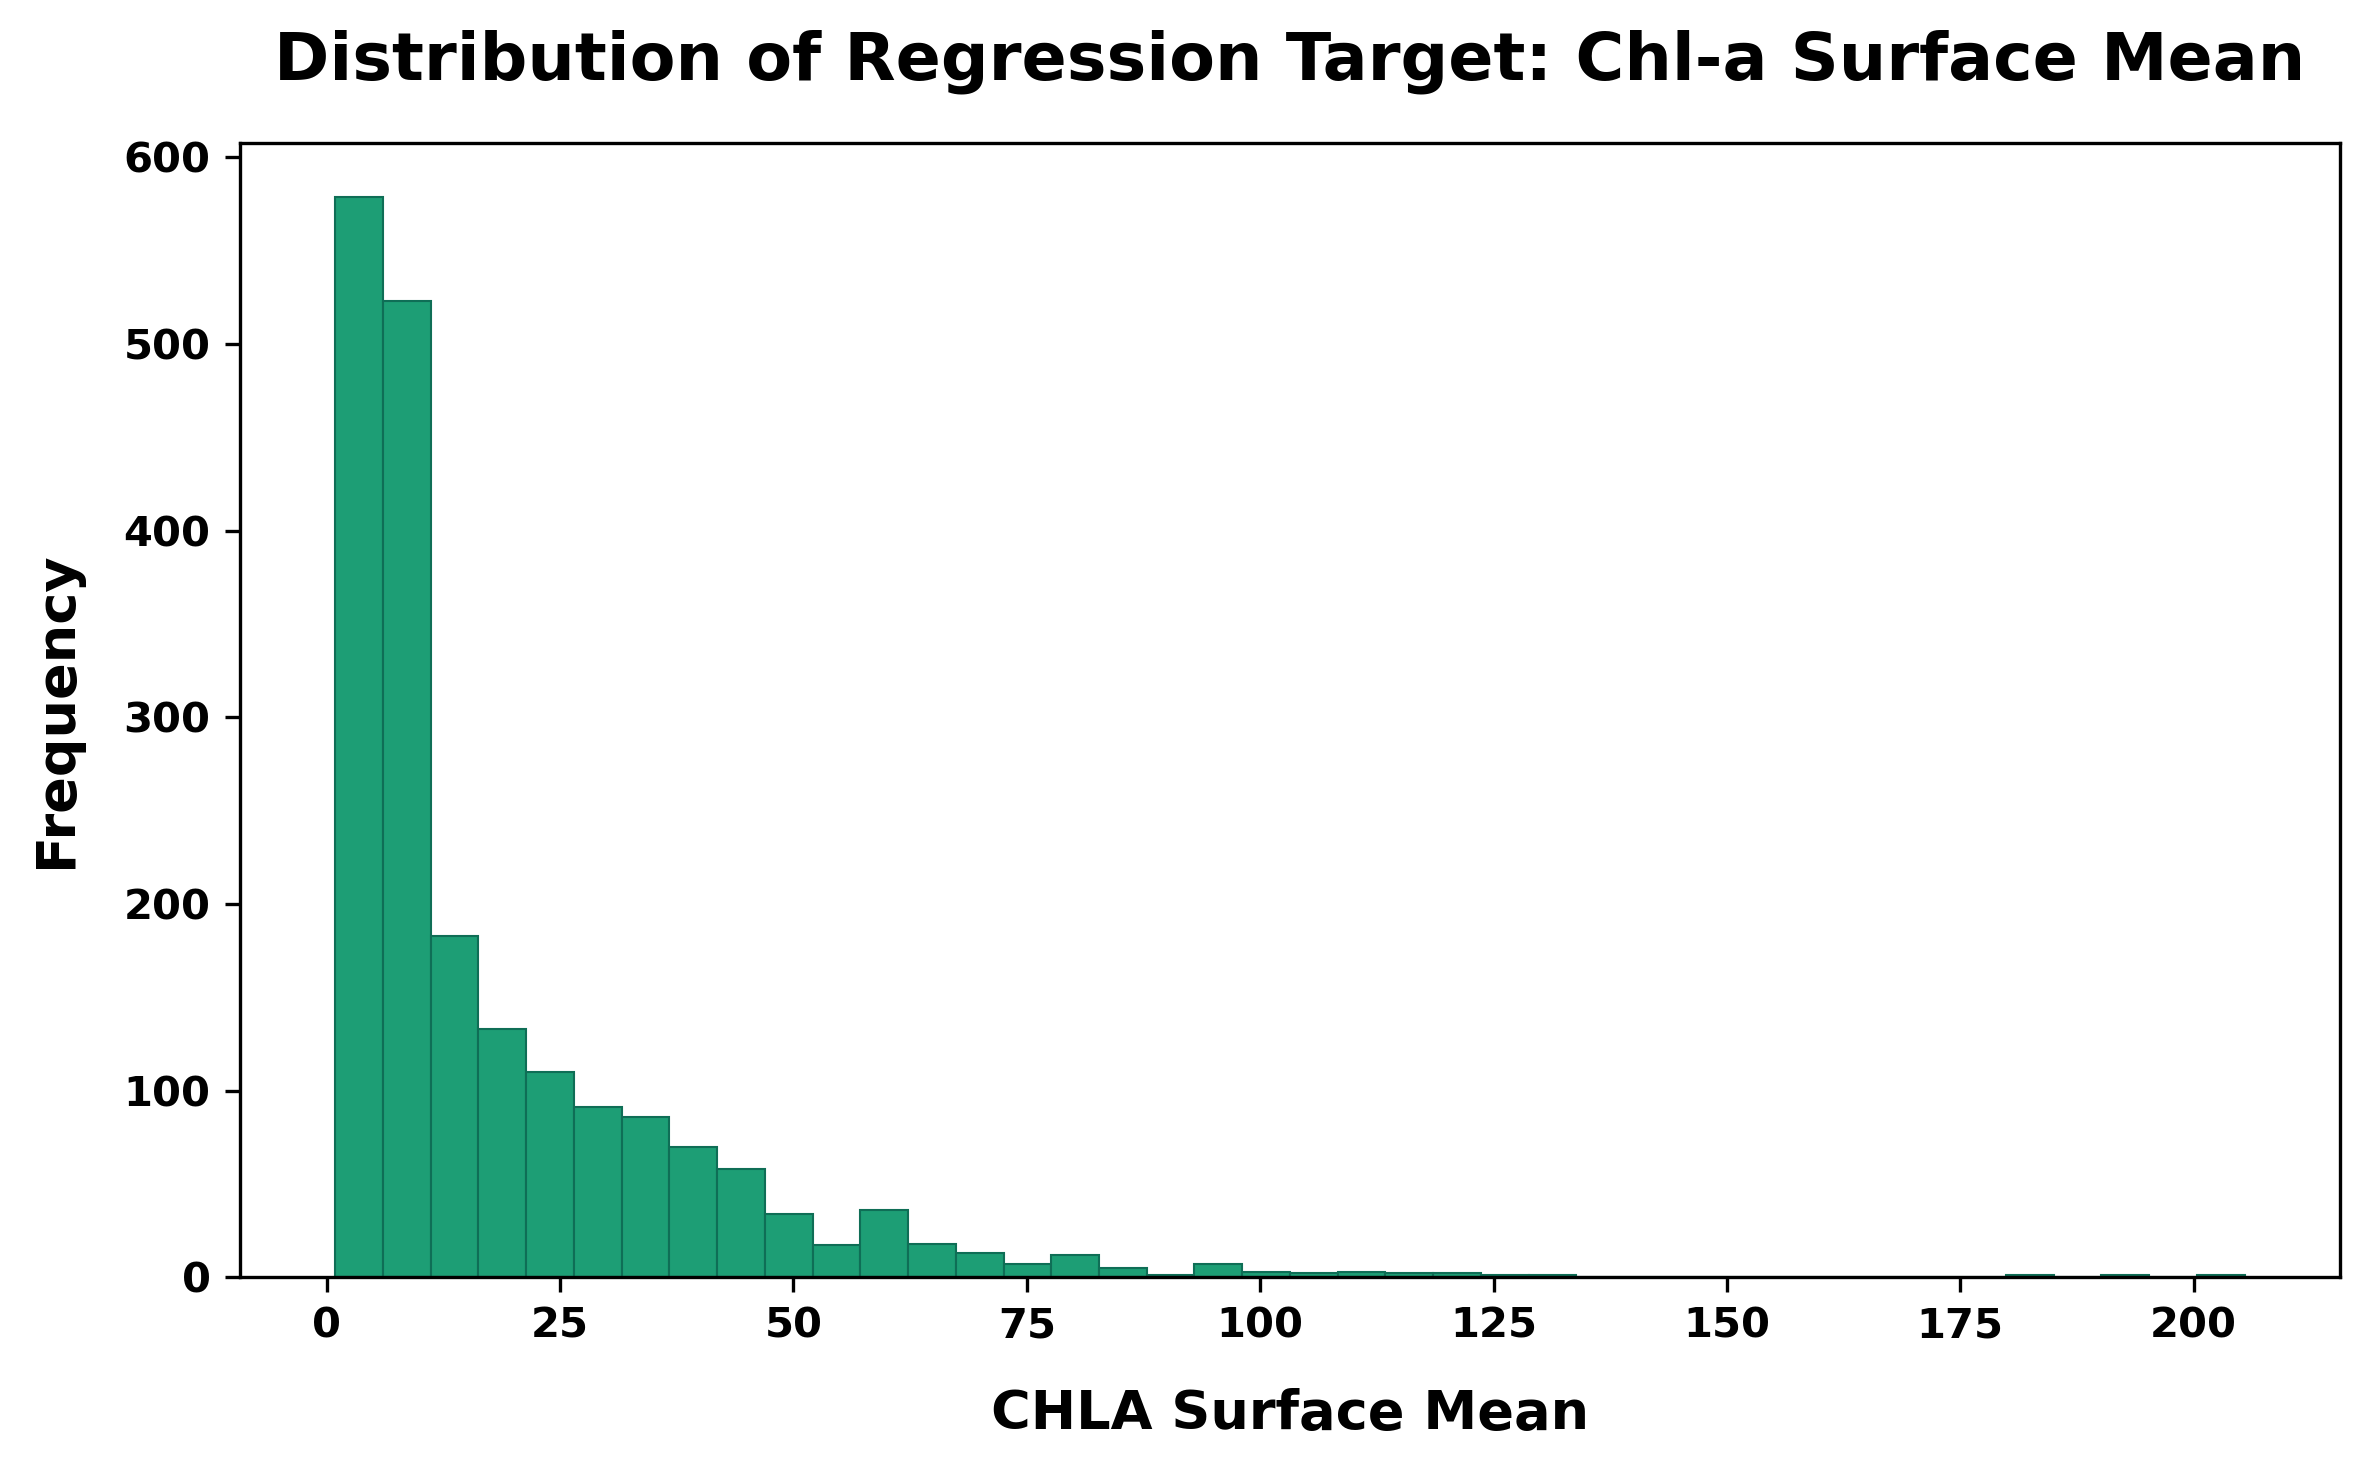

In [4]:

reg_target_col = "CHLAVESurfaceMean"
plt.figure(figsize=(8, 5), dpi=300)
plt.hist(
    csv_data_reg_train[reg_target_col].dropna(),
    bins=40,
    color='#1D9E75',
    edgecolor='#0F6E56',
    linewidth=0.5
    )

plt.title("Distribution of Regression Target: Chl-a Surface Mean", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("CHLA Surface Mean", fontsize=13, fontweight='bold', labelpad=10)
plt.ylabel("Frequency", fontsize=13, fontweight='bold', labelpad=10)

plt.xticks(fontsize=10, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


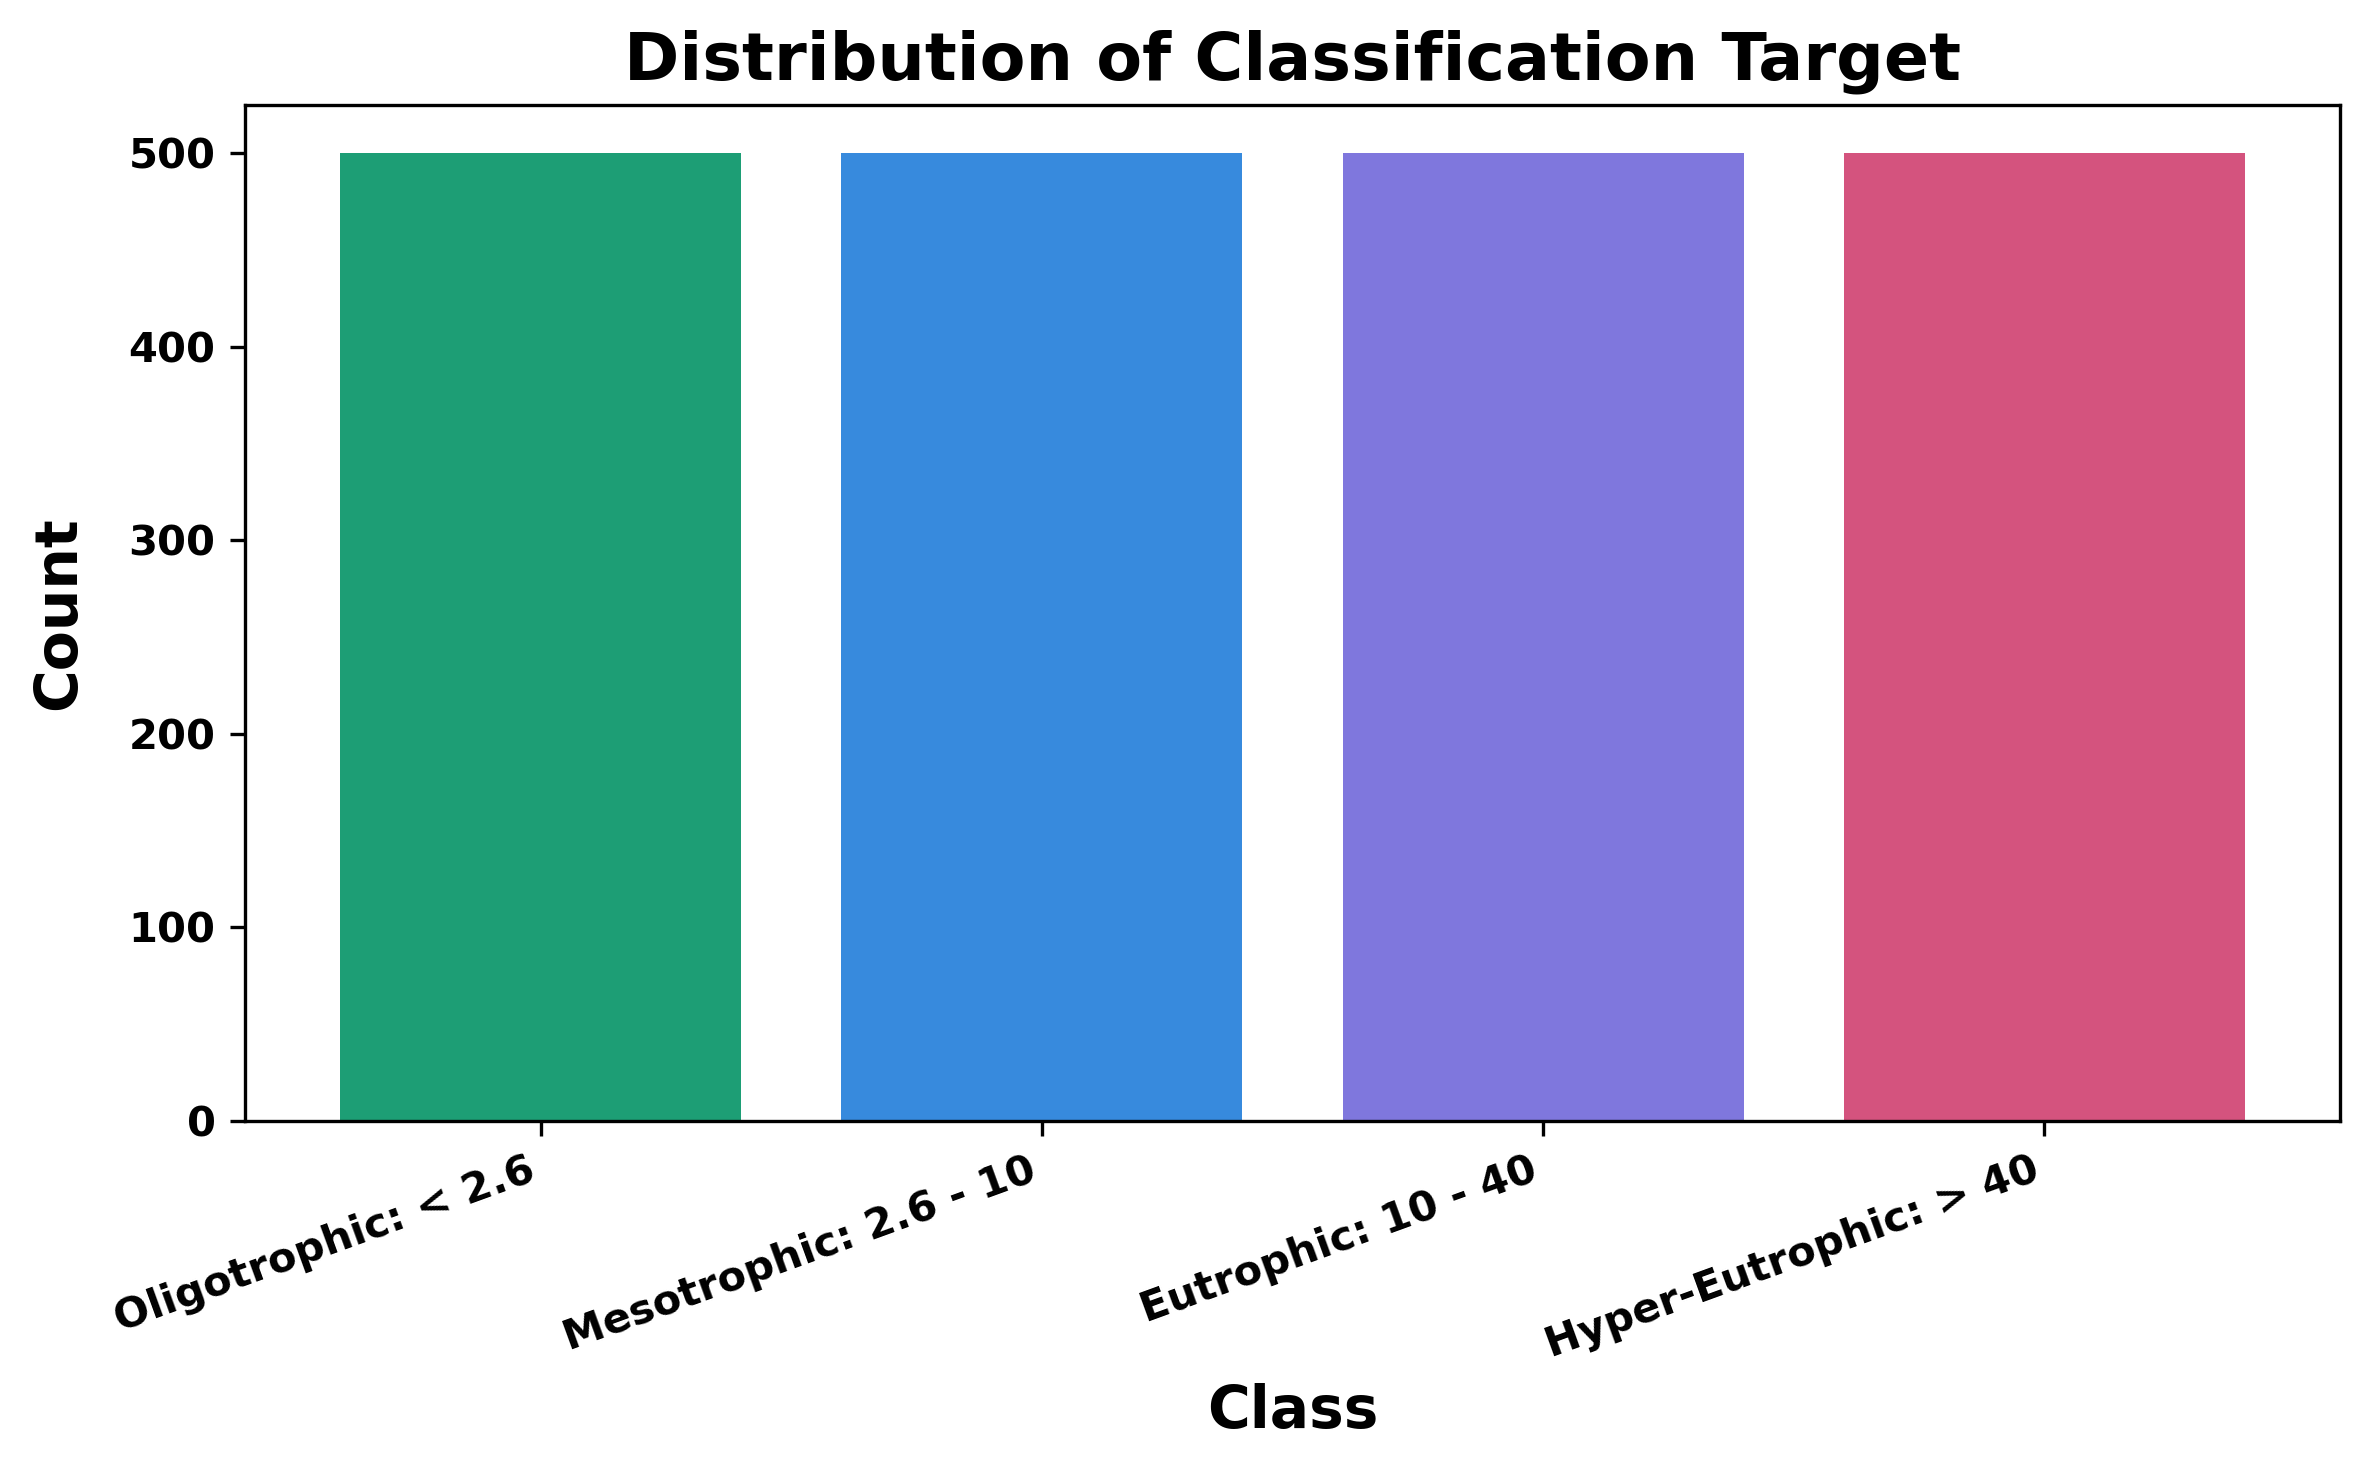

In [36]:

cls_target_col = "CHLAClass"
class_counts = csv_data_classification_train[cls_target_col].value_counts().sort_index()
class_label_map = {
    0: "Oligotrophic: < 2.6",
    1: "Mesotrophic: 2.6 - 10",
    2: "Eutrophic: 10 - 40",
    3: "Hyper-Eutrophic: > 40"
}
class_labels = [class_label_map.get(i, str(i)) for i in class_counts.index]

bar_colors = ['#1D9E75', '#378ADD', '#7F77DD', '#D4537E']

plt.figure(figsize=(8, 5), dpi=300)
plt.bar(class_labels, class_counts.values, color=bar_colors, linewidth=0.8)

plt.title("Distribution of Classification Target", fontsize=16, fontweight='bold')
plt.xlabel("Class", fontsize=14, fontweight='bold')
plt.ylabel("Count", fontsize=14, fontweight='bold', labelpad=10)

plt.xticks(rotation=20, ha="right", fontsize=10, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("classification_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


### **3. Model Families Used For Emulation**

#### **3.1 What Models are we using and why?**
We used **three tree-based machine learning models** as emulator models:
- **Random Forest**
- **LightGBM**
- **XGBoost**

`Why these Models:`

1. **Interpretation friendly** 
    - The main objective is to understand learned relationships in the simulator, especially through feature importance and partial dependence plots (PDPs).
2. **They handle nonlinear relationships well**
    - The links between environmental drivers, policy scenarios, and chlorophyll response are non-linear.    
3. **They work well for tabular data**
    - Our inputs are structured variables, not images or sequences.
4. **They support both tasks naturally**
    - Regression: estimate continuous chlorophyll-a response
    - Classification: assign trophic-state categories      

#### **3.2 Random Forest**
- Random Forest builds many decision trees and combines their predictions.
- For regression, it averages the predictions from many trees
- For classification, it uses the majority vote across trees

A single decision tree may overreact to one particular pattern in the data.
Random Forest reduces that risk by asking:

> “What if we build many different trees on slightly different views of the data, and then combine them?”

That is why it is called a forest rather than just a tree.

**Example:**
- Suppose we use:
    - JPO4 - snowpack - sat_def
- One tree may split first on:
    - JPO4
- Another tree may focus more on:
    - snowpack
- A third tree may use:
    - sat_def
- Each tree gives its own prediction
- Final output:
    - regression: average of tree predictions
    - classification: majority vote across trees

#### **3.3 General Idea of Gradient Boosting**

> Instead of building many trees independently and averaging them, gradient boosting builds trees sequentially:


- Build a model and the first tree makes an initial prediction
- the next tree tries to correct the errors of the first
- the next tree corrects what is still wrong and this continues step by step

**Example:** 

- First tree makes an initial prediction
- It works reasonably well for:
    - moderate chlorophyll cases
- But it may miss:
    - high chlorophyll cases
- Second tree focuses more on:
    - those underpredicted high-value cases
- Third tree then tries to fix:
    - the remaining errors and so on.

#### **3.4 LightGBM**

> A gradient boosting framework designed to be efficient and scalable.

It follows the same general boosting idea:
- build trees sequentially
- each new tree tries to improve the current model

But it is **optimized to train faster handle large tabular datasets efficiently**.


#### **3.5 XGBoost**

> A gradient boosting model, but with a strong emphasis on optimization, regularization and robust performance. 

Follows same boosting idea: build trees sequentially to reduce error.

**Often performs well while controlling overfitting carefully.**

### **4. Training Workflow and Reproducibility**

#### **4.1 Data split**
- Dont train and evaluate on same data
- Need three splits:
    - Training Data: Use to fit the model
    - Validation Data - Use during training for evaluation and early stopping
    - Test Data - Use for final evaluation


In [6]:

# define traget columns
classification_target = "CHLAClass"
regression_target = "CHLAVESurfaceMean"

# split data into training, testing
# get training data and later split into train and validation
X_classification = csv_data_classification_train.drop(columns=[classification_target])
y_classification = csv_data_classification_train[classification_target]

# use train_test_split from sklearn -> https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
X_class_train, X_class_val, y_class_train, y_class_val = train_test_split(
                                                            X_classification,
                                                            y_classification,
                                                            test_size=0.10,
                                                            stratify=y_classification,
                                                            random_state=14912
                                                            )

X_classification_test = csv_data_classification_test.drop(columns=[classification_target])
y_classification_test = csv_data_classification_test[classification_target]


# regression
X_regression = csv_data_reg_train.drop(columns=[regression_target])
y_regression = csv_data_reg_train[regression_target]

X_reg_train, X_reg_val, y_reg_train, y_reg_val = train_test_split(
                                                        X_regression,
                                                        y_regression,
                                                        test_size=0.10,
                                                        random_state=14912
                                                        )

X_regression_test = csv_data_reg_test.drop(columns=[regression_target])
y_regression_test = csv_data_reg_test[regression_target]



print("Classification Data:")
print(f"\tTrain Input: {X_class_train.shape}      - Train Target: {y_class_train.shape}")
print(f"\tValidation Input: {X_class_val.shape}  - Train Target: {y_class_val.shape}")
print(f"\tTest Input: {X_classification_test.shape}        - Test Target: {y_classification_test.shape}")

print("\nRegression Data:")
print(f"\tTrain Input: {X_reg_train.shape}      - Train Target: {y_reg_train.shape}")
print(f"\tValidation Input: {X_reg_val.shape}  - Train Target: {y_reg_val.shape}")
print(f"\tTest Input: {X_regression_test.shape}        - Test Target: {y_regression_test.shape}")


Classification Data:
	Train Input: (1800, 50)      - Train Target: (1800,)
	Validation Input: (200, 50)  - Train Target: (200,)
	Test Input: (400, 50)        - Test Target: (400,)

Regression Data:
	Train Input: (1800, 50)      - Train Target: (1800,)
	Validation Input: (200, 50)  - Train Target: (200,)
	Test Input: (400, 50)        - Test Target: (400,)


#### **4.2 Model Initialization**

We initialize **six emulator models**:

- Random Forest classifier and regressor
- LightGBM classifier and regressor
- XGBoost classifier and regressor

The classifier models predict `CHLAClass`, while the regressor models predict `CHLAVESurfaceMean`.

The main settings used across models are:

| Parameter | Purpose |
|---|---|
| `n_estimators` | Number of trees or boosting rounds. Small values are used here for workshop speed. |
| `learning_rate` | Controls the update size for boosting models. |
| `max_depth` | Controls tree complexity. |
| `subsample` | Uses a fraction of rows during boosting to reduce overfitting. |
| `colsample_bytree` | Uses a fraction of features per tree to improve robustness. |
| `n_jobs=-1` | Uses available CPU cores where supported. |
| `random_state=14912` | Makes results reproducible. |
| `early_stopping_rounds` | Stops boosting when validation performance no longer improves. |

For this workshop, we use small model settings so that training and evaluation run quickly. The goal is not to optimize final model performance here, but to demonstrate the emulator workflow: train, evaluate, interpret, and transfer the approach to other simulation-based systems.

`In a full research workflow, these values should be tuned more carefully.`

For detailed list of parameters:
- [Random Forest Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
- [Random Forest Regressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)
- [LGBMRegressor](https://lightgbm.readthedocs.io/en/v3.3.5/pythonapi/lightgbm.LGBMRegressor.html)
- [LGBMClassifier](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html)
- [XGBoost Parameters](https://xgboost.readthedocs.io/en/stable/parameter.html)



##### **4.2.1 Random Forest**

In [7]:

# random forest classifier
rf_clf = RandomForestClassifier(
                n_estimators=100,
                n_jobs=-1,
                random_state=14912
                )

# random forest regression
rf_reg = RandomForestRegressor(
                n_estimators=100,
                n_jobs=-1,
                random_state=14912
                )

print(rf_clf)
print(rf_reg)


RandomForestClassifier(n_jobs=-1, random_state=14912)
RandomForestRegressor(n_jobs=-1, random_state=14912)


##### **4.2.2 LightGBM**

In [8]:

# LightGBM classification
lgbm_clf = LGBMClassifier(
                objective="multiclass",
                num_class=4,
                learning_rate=0.05,
                n_estimators=20,      # upper bound, might use early stopping
                max_depth=-1,
                subsample=0.8,
                colsample_bytree=0.8,
                n_jobs=-1,
                random_state=14912,
                )

# LightGBM regression
lgbm_reg = LGBMRegressor(
                objective="regression",   # L2 by default
                learning_rate=0.05,
                n_estimators=20,       # upper bound - early stopping might trim
                max_depth=-1,
                subsample=0.8,
                colsample_bytree=0.8,
                n_jobs=-1,
                random_state=14912,
                )

print(lgbm_clf)
print(lgbm_reg)


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=20,
               n_jobs=-1, num_class=4, objective='multiclass',
               random_state=14912, subsample=0.8)
LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=20,
              n_jobs=-1, objective='regression', random_state=14912,
              subsample=0.8)


##### **5.3.3 XGBoost**

In [9]:

# XGBoost classification
xgb_clf = xgb.XGBClassifier(
                objective="multi:softprob",
                num_class=4,
                learning_rate=0.05,      # we will use small learning rate since n_estimators are high
                n_estimators=20,      # upper bound, might stop early due to the early stopping criteria 
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                tree_method="hist",      # fast histogram algorithm
                n_jobs=-1,
                eval_metric="mlogloss",
                early_stopping_rounds=2,
                random_state=14912,
                )

# XGBoost regression
xgb_reg = xgb.XGBRegressor(
                objective="reg:squarederror",
                learning_rate=0.05,
                n_estimators=20,    # upper bound, might stop early due to the early stopping criteria 
                max_depth=8,
                subsample=0.8,
                colsample_bytree=0.8,
                tree_method="hist",   
                n_jobs=-1,
                eval_metric="rmse",
                early_stopping_rounds=2,
                random_state=14912,
                )

print(xgb_clf)
print(xgb_reg)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=2,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=20, n_jobs=-1, num_class=4, ...)
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=2,
             enable_categorical=False, eval_metric='rmse', fea

#### **4.4 Model Fitting**

- **Model fitting** means learning patterns from the training data
- The model tries to learn a mapping from:
  - **inputs** --> **target output**
- During fitting:
  - **Random Forest** builds many trees
  - **LightGBM** and **XGBoost** build trees step by step
- The goal is to learn generalized patterns can be used outside of training data with same distribution.


In this section, we fit six models:

- Random Forest classifier and regressor
- LightGBM classifier and regressor
- XGBoost classifier and regressor

For LightGBM and XGBoost, we also provide validation data so the model can monitor performance during training and apply early stopping.

We record training time for each model because fitting cost depends on dataset size, number of features, number of trees, tree depth, validation logic, and available hardware.


##### **4.4.1 Random Forest**

In [10]:

# Random Forest Classifier
print("Fitting Random Forest Classifier...")
start_time = time.time()

rf_clf.fit(X_class_train, y_class_train) # rf_clf.fit learns the classification 

rf_clf_train_time = time.time() - start_time
print(f"Random Forest Classifier training finished in {rf_clf_train_time:.2f} seconds.")

# random forest regressor
print("Fitting Random Forest Regressor...")
start_time = time.time()

rf_reg.fit(X_reg_train, y_reg_train) # rf_reg.fit learns the regression 

rf_reg_train_time = time.time() - start_time
print(f"Random Forest Regressor training finished in {rf_reg_train_time:.2f} seconds.")


Fitting Random Forest Classifier...
Random Forest Classifier training finished in 0.21 seconds.
Fitting Random Forest Regressor...
Random Forest Regressor training finished in 0.52 seconds.


##### **4.4.2 LightGBM**

In [11]:

# LightGBM classifier
print("Fitting LightGBM Classifier...")
start_time = time.time()

lgbm_clf.fit(
            X_class_train,
            y_class_train,
            eval_set=[(X_class_val, y_class_val)],
            eval_metric="multi_logloss",
            callbacks=[
                    early_stopping(stopping_rounds=2, verbose=False),
                    log_evaluation(period=2)
                    ]
            )

lgbm_clf_train_time = time.time() - start_time
print(f"LightGBM Classifier training finished in {lgbm_clf_train_time:.2f} seconds.")


# LightGBM regression
print("Fitting LightGBM Regressor...")
start_time = time.time()

lgbm_reg.fit(
            X_reg_train,
            y_reg_train,
            eval_set=[(X_reg_val, y_reg_val)],
            eval_metric="rmse",
            callbacks=[
                    early_stopping(stopping_rounds=2, verbose=False),
                    log_evaluation(period=2)
                    ]
            )

lgbm_reg_train_time = time.time() - start_time
print(f"LightGBM Regressor training finished in {lgbm_reg_train_time:.2f} seconds.")


Fitting LightGBM Classifier...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001428 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6150
[LightGBM] [Info] Number of data points in the train set: 1800, number of used features: 49
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[2]	valid_0's multi_logloss: 1.27223
[4]	valid_0's multi_logloss: 1.17944
[6]	valid_0's multi_logloss: 1.10762
[8]	valid_0's multi_logloss: 1.04499
[10]	valid_0's multi_logloss: 0.986994
[12]	valid_0's multi_logloss: 0.939339
[14]	valid_0's multi_logloss: 0.901688
[16]	valid_0's multi_logloss: 0.866432
[18]	valid_0's multi_logloss: 0.834209
[20]	valid_0's multi_logloss: 0.810773
LightGBM Classifier training finished in 1.13 seconds.
Fitting LightGBM Regressor..

##### **4.4.3 XGBoost**

In [12]:

# XGBoost classifier
print("Fitting XGBoost Classifier...")
start_time = time.time()

xgb_clf.fit(
            X_class_train,
            y_class_train,
            eval_set=[(X_class_val, y_class_val)],
            verbose=1
            )

xgb_clf_train_time = time.time() - start_time
print(f"XGBoost Classifier training finished in {xgb_clf_train_time:.2f} seconds.")


# XGBoost regressor
print("Fitting XGBoost Regressor...")
start_time = time.time()

xgb_reg.fit(
            X_reg_train,
            y_reg_train,
            eval_set=[(X_reg_val, y_reg_val)],
            verbose=1
            )

xgb_reg_train_time = time.time() - start_time
print(f"XGBoost Regressor training finished in {xgb_reg_train_time:.2f} seconds.")


Fitting XGBoost Classifier...
[0]	validation_0-mlogloss:1.34741
[1]	validation_0-mlogloss:1.30694
[2]	validation_0-mlogloss:1.27702
[3]	validation_0-mlogloss:1.24300
[4]	validation_0-mlogloss:1.21541
[5]	validation_0-mlogloss:1.18750
[6]	validation_0-mlogloss:1.15837
[7]	validation_0-mlogloss:1.13493
[8]	validation_0-mlogloss:1.11684
[9]	validation_0-mlogloss:1.09371
[10]	validation_0-mlogloss:1.07491
[11]	validation_0-mlogloss:1.05625
[12]	validation_0-mlogloss:1.03939
[13]	validation_0-mlogloss:1.02138
[14]	validation_0-mlogloss:1.00411
[15]	validation_0-mlogloss:0.98914
[16]	validation_0-mlogloss:0.97354
[17]	validation_0-mlogloss:0.95864
[18]	validation_0-mlogloss:0.94257
[19]	validation_0-mlogloss:0.93130
XGBoost Classifier training finished in 20.59 seconds.
Fitting XGBoost Regressor...
[0]	validation_0-rmse:21.30982
[1]	validation_0-rmse:20.76338
[2]	validation_0-rmse:20.39303
[3]	validation_0-rmse:19.99814
[4]	validation_0-rmse:19.70483
[5]	validation_0-rmse:19.50143
[6]	valida

##### **4.4.4 Fitting Time Difference Across Models**

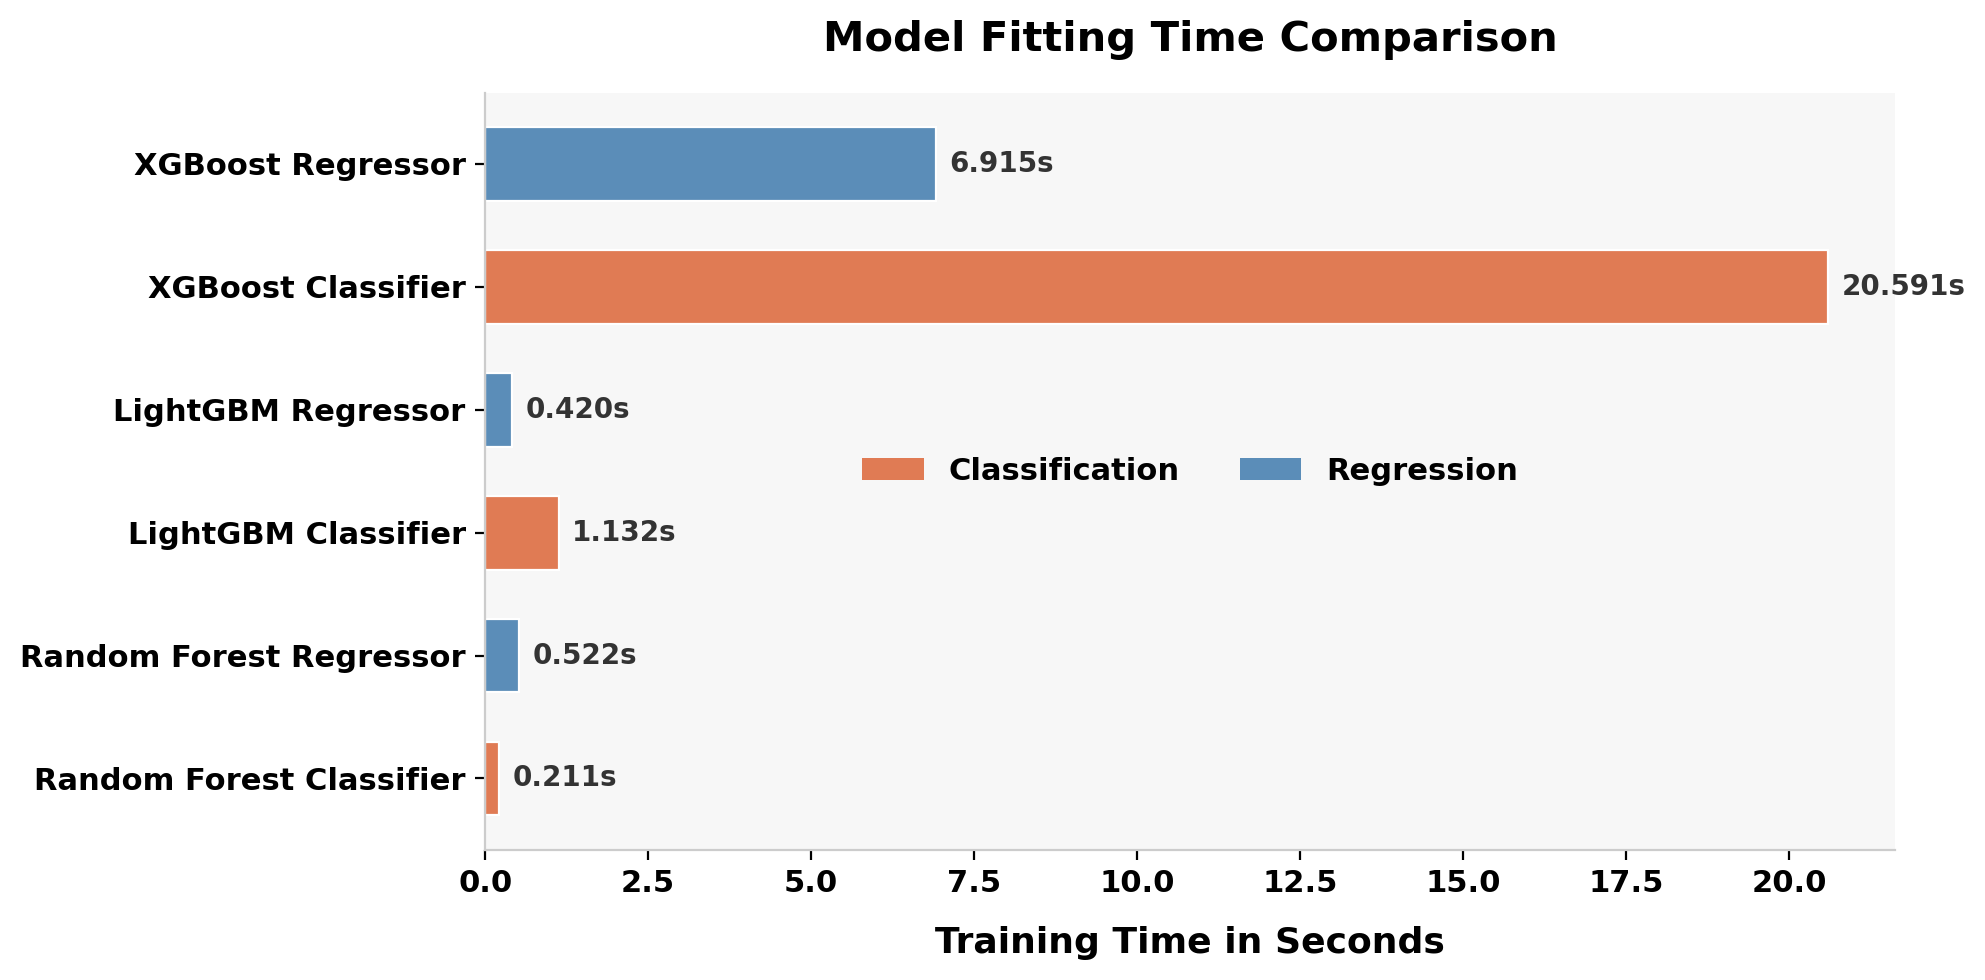

In [13]:

fit_time_df = pd.DataFrame({
    "Model": [
        "Random Forest Classifier",
        "Random Forest Regressor",
        "LightGBM Classifier",
        "LightGBM Regressor",
        "XGBoost Classifier",
        "XGBoost Regressor"
    ],
    "Task": [
        "Classification",
        "Regression",
        "Classification",
        "Regression",
        "Classification",
        "Regression"
    ],
    "Training Time (seconds)": [
        rf_clf_train_time,
        rf_reg_train_time,
        lgbm_clf_train_time,
        lgbm_reg_train_time,
        xgb_clf_train_time,
        xgb_reg_train_time
    ]
})

fit_time_df["Training Time (seconds)"] = fit_time_df["Training Time (seconds)"].round(3)

# Lets display it using bar plots
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

# we will add the colors by task type 
colors = ["#E07B54" if t == "Classification" else "#5B8DB8" 
          for t in fit_time_df["Task"]]

bars = ax.barh(
        fit_time_df["Model"],
        fit_time_df["Training Time (seconds)"],
        color=colors,
        edgecolor="white",
        linewidth=0.8,
        height=0.6
        )

# Lets also add value labels at end of each bar
for bar, val in zip(bars, fit_time_df["Training Time (seconds)"]):
    ax.text(
        bar.get_width() + max(fit_time_df["Training Time (seconds)"]) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}s",
        va="center", ha="left",
        fontsize=10, fontweight="bold", color="#333333"
        )


ax.set_xlabel("Training Time in Seconds", fontsize=13, fontweight="bold", labelpad=10)
ax.set_title("Model Fitting Time Comparison", fontsize=15, fontweight="bold", pad=15)

ax.tick_params(axis="both", labelsize=11)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

ax.set_facecolor("#F7F7F7")
fig.patch.set_facecolor("#FFFFFF")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#CCCCCC")
# ax.xaxis.grid(True, color="#DDDDDD", linestyle="--", linewidth=0.8)
ax.set_axisbelow(True)

# Legend for task type
legend_elements = [
                Patch(facecolor="#E07B54", label="Classification"),
                Patch(facecolor="#5B8DB8", label="Regression")
                ]

ax.legend(handles=legend_elements, fontsize=11, framealpha=0.9,
          prop={"weight": "bold", "size": 11},
          ncol=2, fancybox=False, shadow=False, 
          loc='center', frameon=False)

plt.tight_layout()
plt.show()


##### **4.4.4 Fitting Time Difference Across Models**
- **Random Forest**
  - many trees built independently
  - parallel computation helps
- **LightGBM**
  - boosting model
  - trees built sequentially
  - can be faster than older boosting methods
  - GPU support can help
- **XGBoost**
  - boosting model
  - strong optimization and regularization
  - can take longer when many boosting rounds are allowed
- Overall model fitting depends:
    - data size
    - model type
    - number of trees
    - tree depth
    - validation logic
    - hardware

### **5. Model Saving - Loading - Evaluation**

After training, we save each model to disk and reload it before evaluation. This mimics a reproducible research workflow where models do not need to be retrained every time the notebook is opened.

`Models are evaluated on test dataset.`

For **regression**, we use:

- **MAE:** average absolute prediction error.
- **RMSE:** error metric that penalizes large mistakes more strongly.
- **Bias:** average signed error, negative values indicate underprediction, positive values indicate overprediction.
- **R²:** proportion of target variation explained by the model.

For **classification**, we use:

- **Precision:** how many predicted class labels were correct.
- **Recall:** how many true class cases were recovered.
- **F1-score:** balance between precision and recall.
- **Confusion matrix:** shows where the classifier is correct or confused across trophic-state classes.

In [14]:

# model weights paths
weights_path = Path("./Model_Weights")

weights_path = Path("./Model_Weights")

model_dirs = {
    "rf_clf": weights_path / "RF/Classification",
    "rf_reg": weights_path / "RF/Regression",
    "lgbm_clf": weights_path / "LightGBM/Classification",
    "lgbm_reg": weights_path / "LightGBM/Regression",
    "xgb_clf": weights_path / "XGBoost/Classification",
    "xgb_reg": weights_path / "XGBoost/Regression",
    }

for path in model_dirs.values():
    path.mkdir(parents=True, exist_ok=True)


In [15]:

# few helper functions for saving, loading, evaluation and visualizations
def save_and_load_model(model, model_path):
    """
    Save a trained model to disk and reload it.
    """
    joblib.dump(model, model_path)
    loaded_model = joblib.load(model_path)
    return loaded_model

def evaluate_regression_model(model, X_test, y_test, model_name):
    """
    Evaluate a regression model using compact metrics.
    """
    y_pred = model.predict(X_test)

    results = {
            # "Model": model_name,
            "MAE": round(mean_absolute_error(y_test, y_pred), 4),
            "RMSE": round(root_mean_squared_error(y_test, y_pred), 4),
            "Bias": round(float(np.mean(y_pred - y_test)), 4),
            "R2": round(r2_score(y_test, y_pred), 4),
            }

    return y_pred, results


def evaluate_classification_model(model, X_test, y_test, model_name):
    """
    Evaluate a classification model using macro-averaged metrics.
    Macro averaging gives equal weight to each trophic-state class.
    """
    y_pred = model.predict(X_test)

    results = {
            "Model": model_name,
            "Precision": round(precision_score(y_test, y_pred, average="macro", zero_division=0), 4),
            "Recall": round(recall_score(y_test, y_pred, average="macro", zero_division=0), 4),
            "F1": round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4),
            }

    return y_pred, results


def plot_predicted_vs_actual(y_true, y_pred, model_name, dpi=200):
    """
    Plot predicted vs actual regression values with a 1:1 reference line
    using the workshop style.
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    plt.figure(figsize=(8, 4), dpi=dpi)

    # scatter points
    plt.scatter(
        y_true,
        y_pred,
        s=12,
        alpha=0.65,
        edgecolor="none"
        )

    # Lets  draw the reference line too
    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linewidth=2,
        label="1:1 Line"
        )

    plt.title(
        f"{model_name} - Predicted VS Actual",
        fontsize=16,
        weight="bold",
        pad=12
        )

    plt.xlabel(
        "Actual",
        fontsize=13,
        weight="bold"
        )

    plt.ylabel(
        "Predicted",
        fontsize=13,
        weight="bold"
        )

    plt.xticks(fontsize=11, weight="bold")
    plt.yticks(fontsize=11, weight="bold")

    plt.grid(False)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, model_name, dpi=200):
    """
    Plot confusion matrix 
    """

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 8), dpi=dpi)

    ax = sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="rocket_r",
        cbar=False,
        square=True,
        linewidths=1.9,
        linecolor="white",
        annot_kws={"size": 11, "weight": "bold"}
        )

    ax.set_title(
        f"{model_name} Confusion Matrix",
        fontsize=16,
        weight="bold",
        pad=15
        )

    ax.set_xlabel(
        "Predicted label",
        fontsize=14,
        weight="bold",
        labelpad=10
        )

    ax.set_ylabel(
        "True label",
        fontsize=14,
        weight="bold",
        labelpad=10
        )

    ax.set_xticklabels(
        [0, 1, 2, 3],
        rotation=0,
        fontsize=12,
        fontweight="bold"
        )

    ax.set_yticklabels(
        [0, 1, 2, 3],
        rotation=0,
        fontsize=12,
        fontweight="bold"
        )

    plt.tight_layout()
    plt.show()

#### **5.1 Random Forest**
##### **5.1.1 Random Forest Classification**


Random Forest Classification Metrics
 Precision: 		0.6927
 Recall:    		0.6925
 F1 Score:  		0.6914

Random Forest Classification Report
              precision    recall  f1-score   support

           0     0.9149    0.8600    0.8866       100
           1     0.6822    0.7300    0.7053       100
           2     0.5281    0.4700    0.4974       100
           3     0.6455    0.7100    0.6762       100

    accuracy                         0.6925       400
   macro avg     0.6927    0.6925    0.6914       400
weighted avg     0.6927    0.6925    0.6914       400



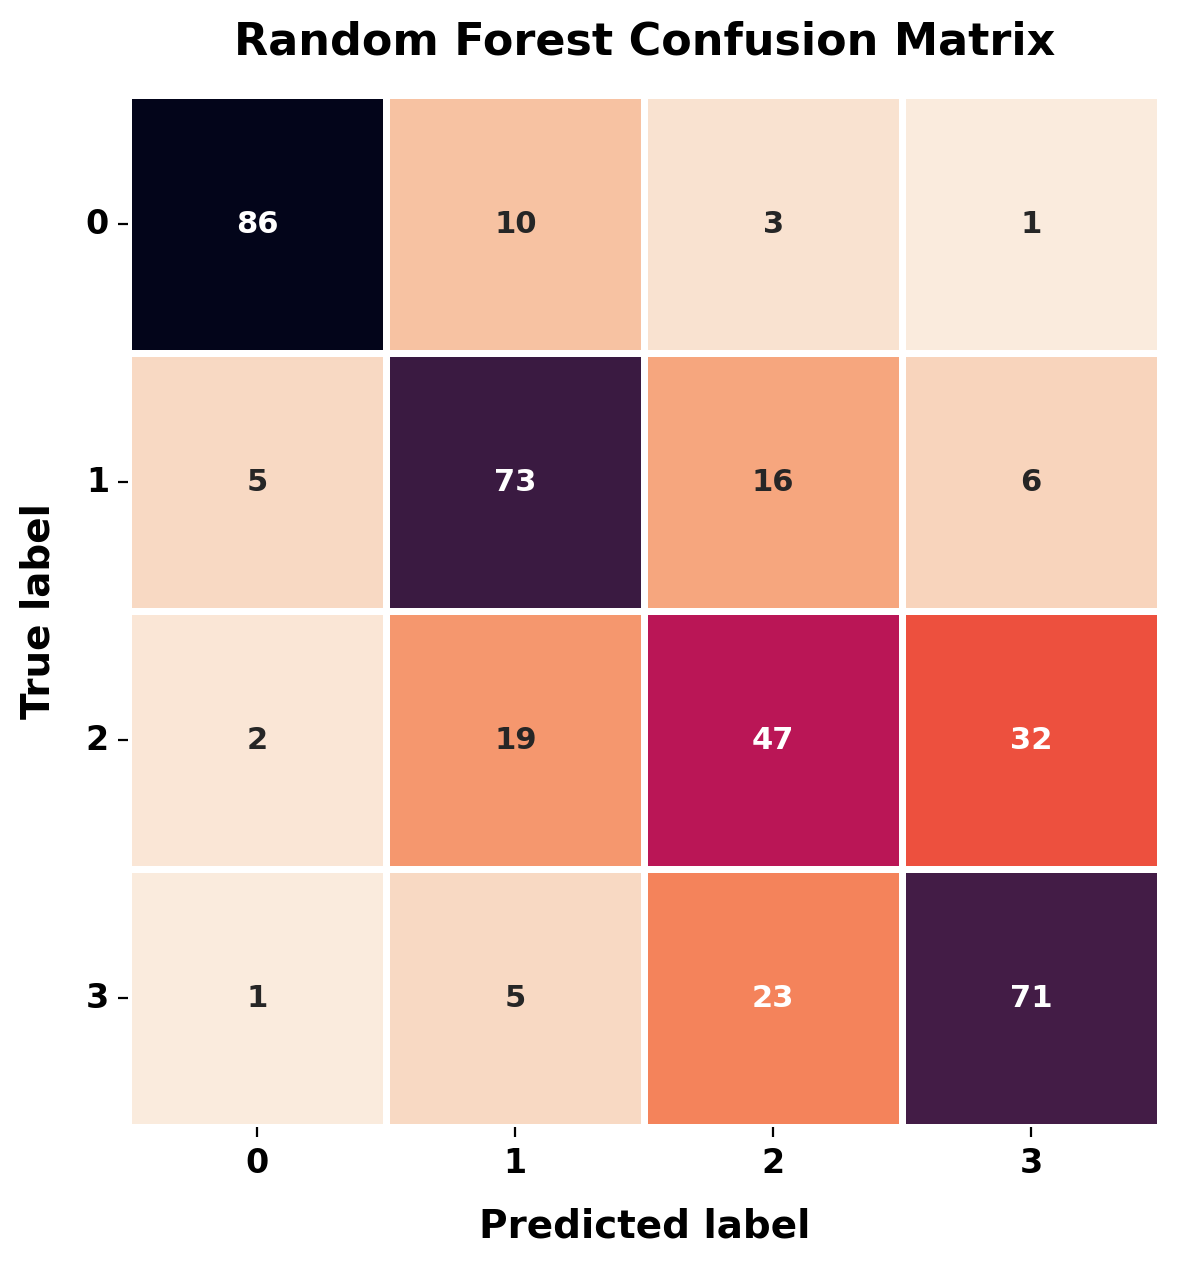

In [16]:

# We will call earlier defined functions
# save and load the model first
rf_clf_loaded = save_and_load_model(
    rf_clf,
    model_dirs["rf_clf"] / "rf_classifier.joblib"
    )

# evaluate on the test set
y_pred_rf_clf, rf_clf_results = evaluate_classification_model(
    rf_clf_loaded,
    X_classification_test,
    y_classification_test,
    "Random Forest"
    )

print("\nRandom Forest Classification Metrics")
print(f" Precision: \t\t{rf_clf_results['Precision']}")
print(f" Recall:    \t\t{rf_clf_results['Recall']}")
print(f" F1 Score:  \t\t{rf_clf_results['F1']}")


print("\nRandom Forest Classification Report")
print(classification_report(y_classification_test, y_pred_rf_clf, digits=4, zero_division=0))

plot_confusion_matrix(y_classification_test, y_pred_rf_clf, "Random Forest", dpi=200)


##### **5.1.2 Random Forest Regression**

Random Forest Regression Metrics
MAE                 : 7.8223
RMSE                : 14.0992
Bias                : 1.1549
R2                  : 0.5305


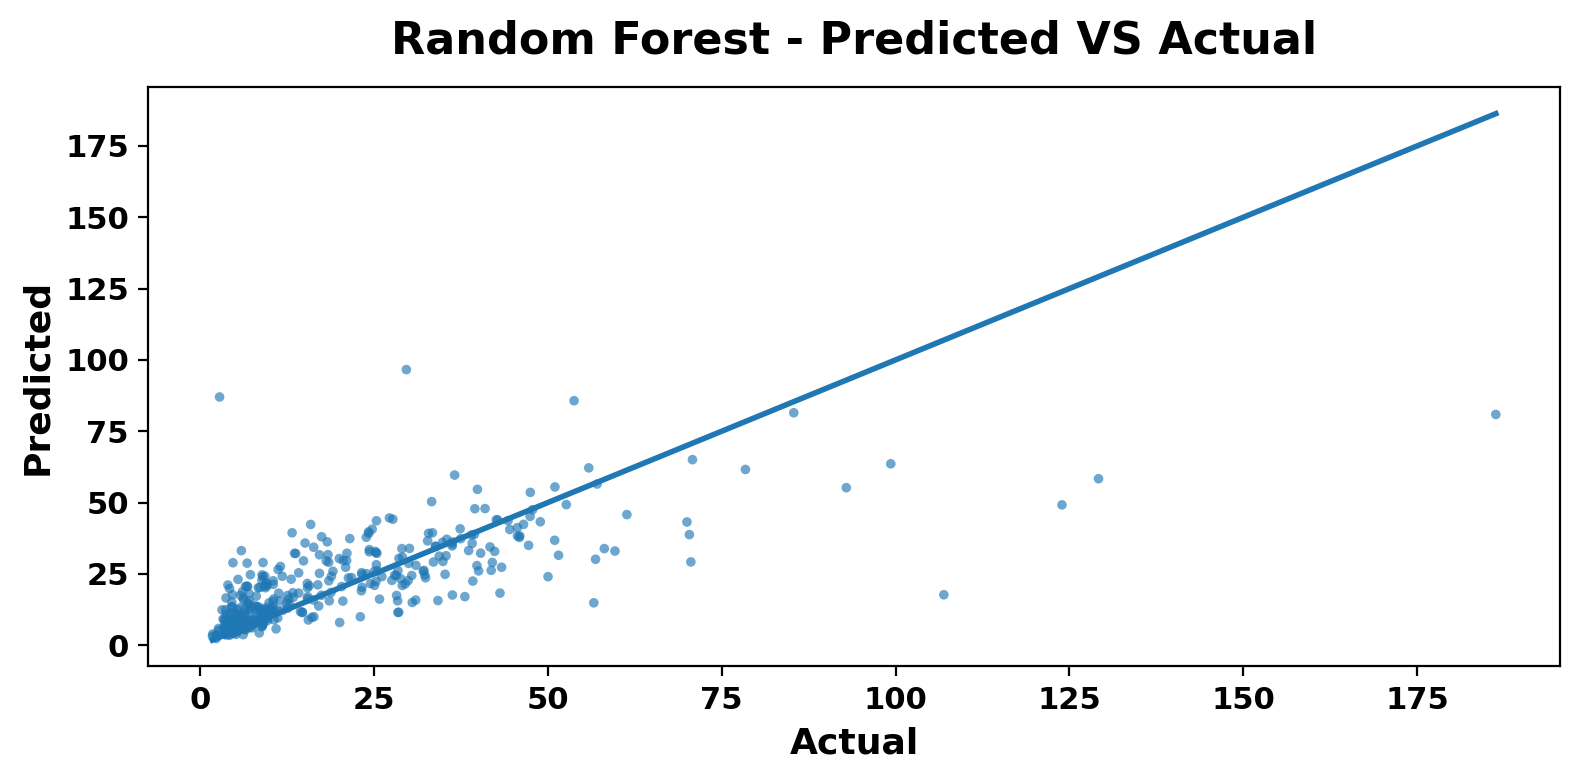

In [17]:

# saving and loading the weights 
rf_reg_loaded = save_and_load_model(
    rf_reg,
    model_dirs["rf_reg"] / "rf_regressor.joblib"
    )

# Evaluation on the hold out test set
y_pred_rf_reg, rf_reg_results = evaluate_regression_model(
    rf_reg_loaded,
    X_regression_test,
    y_regression_test,
    "Random Forest"
    )

print("Random Forest Regression Metrics")
for k, v in rf_reg_results.items():
    print(f"{k:20s}: {v}")

plot_predicted_vs_actual(y_regression_test, y_pred_rf_reg, "Random Forest", dpi=200)


#### **5.2 LightGBM**

##### **5.2.1 LightGBM Classification**



LightGBM Classification Metrics
 Precision: 		0.7062
 Recall:    		0.7025
 F1 Score:  		0.7037

LightGBM Classification Report
              precision    recall  f1-score   support

           0     0.9149    0.8600    0.8866       100
           1     0.6907    0.6700    0.6802       100
           2     0.5556    0.5500    0.5528       100
           3     0.6636    0.7300    0.6952       100

    accuracy                         0.7025       400
   macro avg     0.7062    0.7025    0.7037       400
weighted avg     0.7062    0.7025    0.7037       400



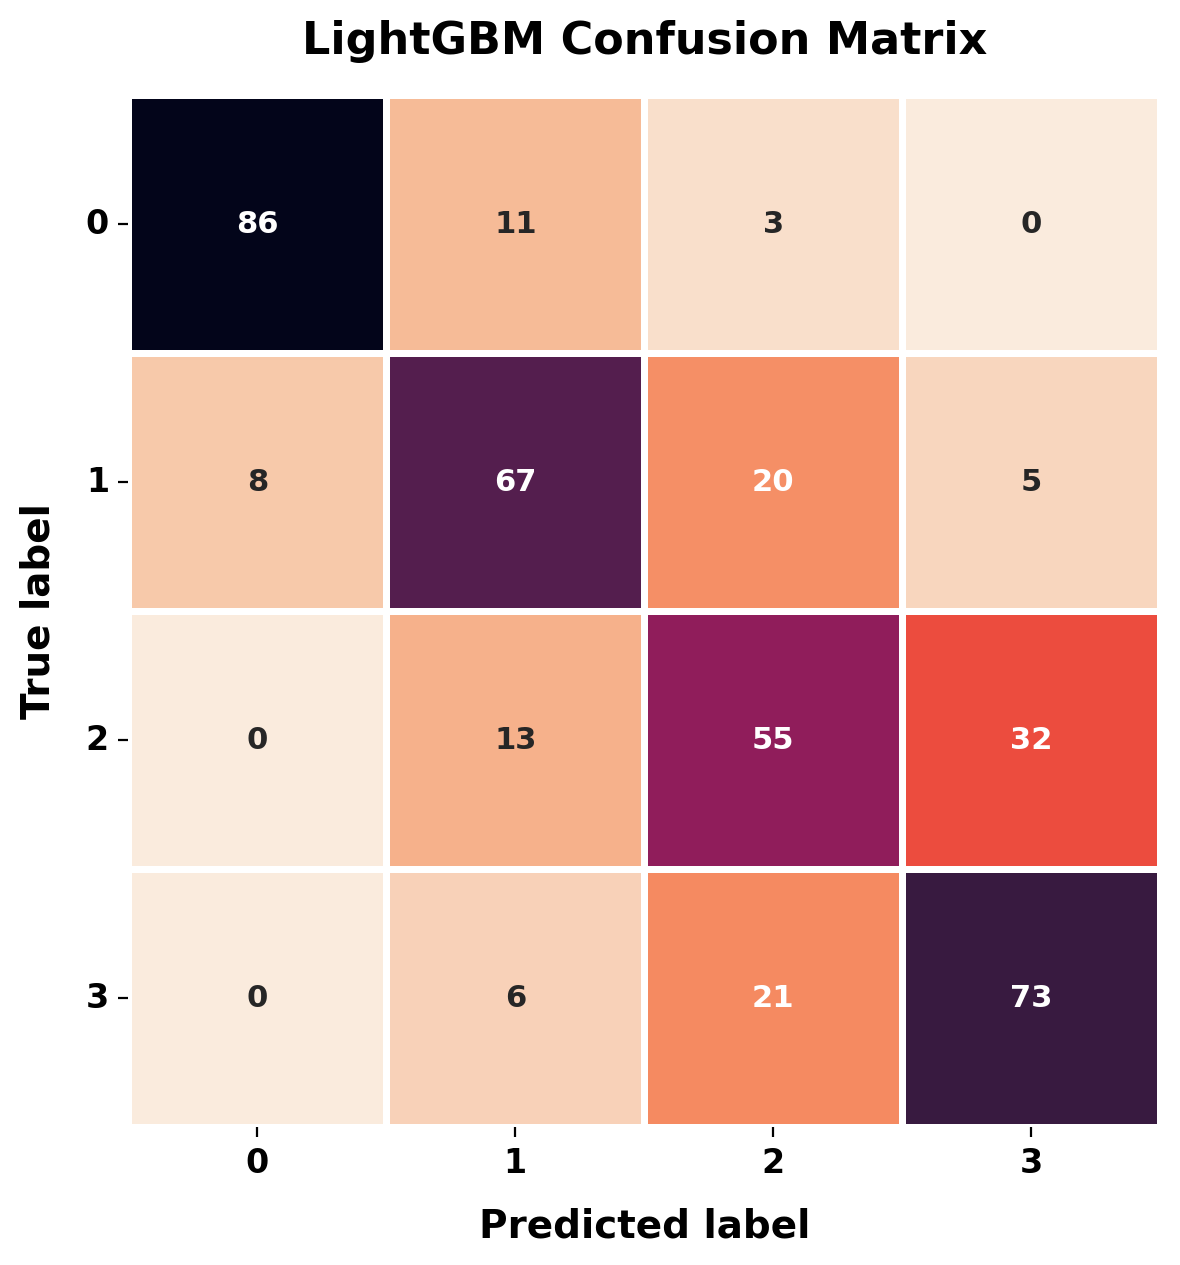

In [18]:

# save and load the model
lgbm_clf_loaded = save_and_load_model(
    lgbm_clf,
    model_dirs["lgbm_clf"] / "lightgbm_classifier.joblib"
    )

# classification evaluation
y_pred_lgbm_clf, lgbm_clf_results = evaluate_classification_model(
    lgbm_clf_loaded,
    X_classification_test,
    y_classification_test,
    "LightGBM"
    )

print("\nLightGBM Classification Metrics")
print(f" Precision: \t\t{lgbm_clf_results['Precision']}")
print(f" Recall:    \t\t{lgbm_clf_results['Recall']}")
print(f" F1 Score:  \t\t{lgbm_clf_results['F1']}")

print("\nLightGBM Classification Report")
print(classification_report(y_classification_test, y_pred_lgbm_clf, digits=4, zero_division=0))

plot_confusion_matrix(y_classification_test, y_pred_lgbm_clf, "LightGBM", dpi=200)


##### **5.2.2 LightGBM Regression**

LightGBM Regression Metrics
MAE                 : 9.7745
RMSE                : 15.7386
Bias                : -0.1299
R2                  : 0.4149


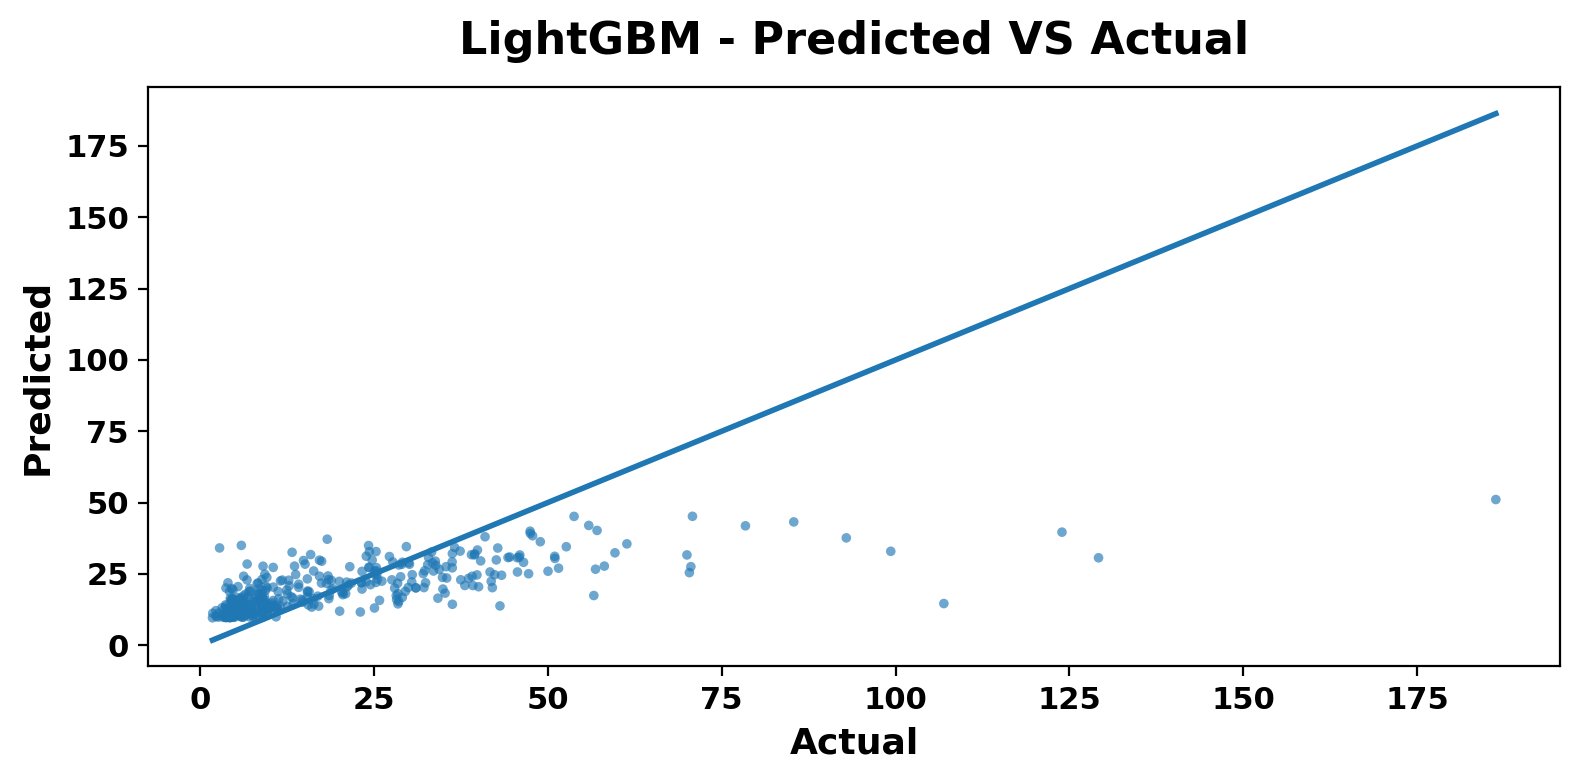

In [19]:

# save and load the weights
lgbm_reg_loaded = save_and_load_model(
    lgbm_reg,
    model_dirs["lgbm_reg"] / "lightgbm_regressor.joblib"
    )

# evaluation on the test set
y_pred_lgbm_reg, lgbm_reg_results = evaluate_regression_model(
    lgbm_reg_loaded,
    X_regression_test,
    y_regression_test,
    "LightGBM"
    )


print("LightGBM Regression Metrics")
for k, v in lgbm_reg_results.items():
    print(f"{k:20s}: {v}")

# scatter plot visualization
plot_predicted_vs_actual(y_regression_test, y_pred_lgbm_reg, "LightGBM")


##### **5.3.1 XGBoost Classification**


XGBoost Classification Metrics
 Precision: 		0.7076
 Recall:    		0.705
 F1 Score:  		0.7045

XGBoost Classification Report
              precision    recall  f1-score   support

           0     0.9570    0.8900    0.9223       100
           1     0.6729    0.7200    0.6957       100
           2     0.5632    0.4900    0.5241       100
           3     0.6372    0.7200    0.6761       100

    accuracy                         0.7050       400
   macro avg     0.7076    0.7050    0.7045       400
weighted avg     0.7076    0.7050    0.7045       400



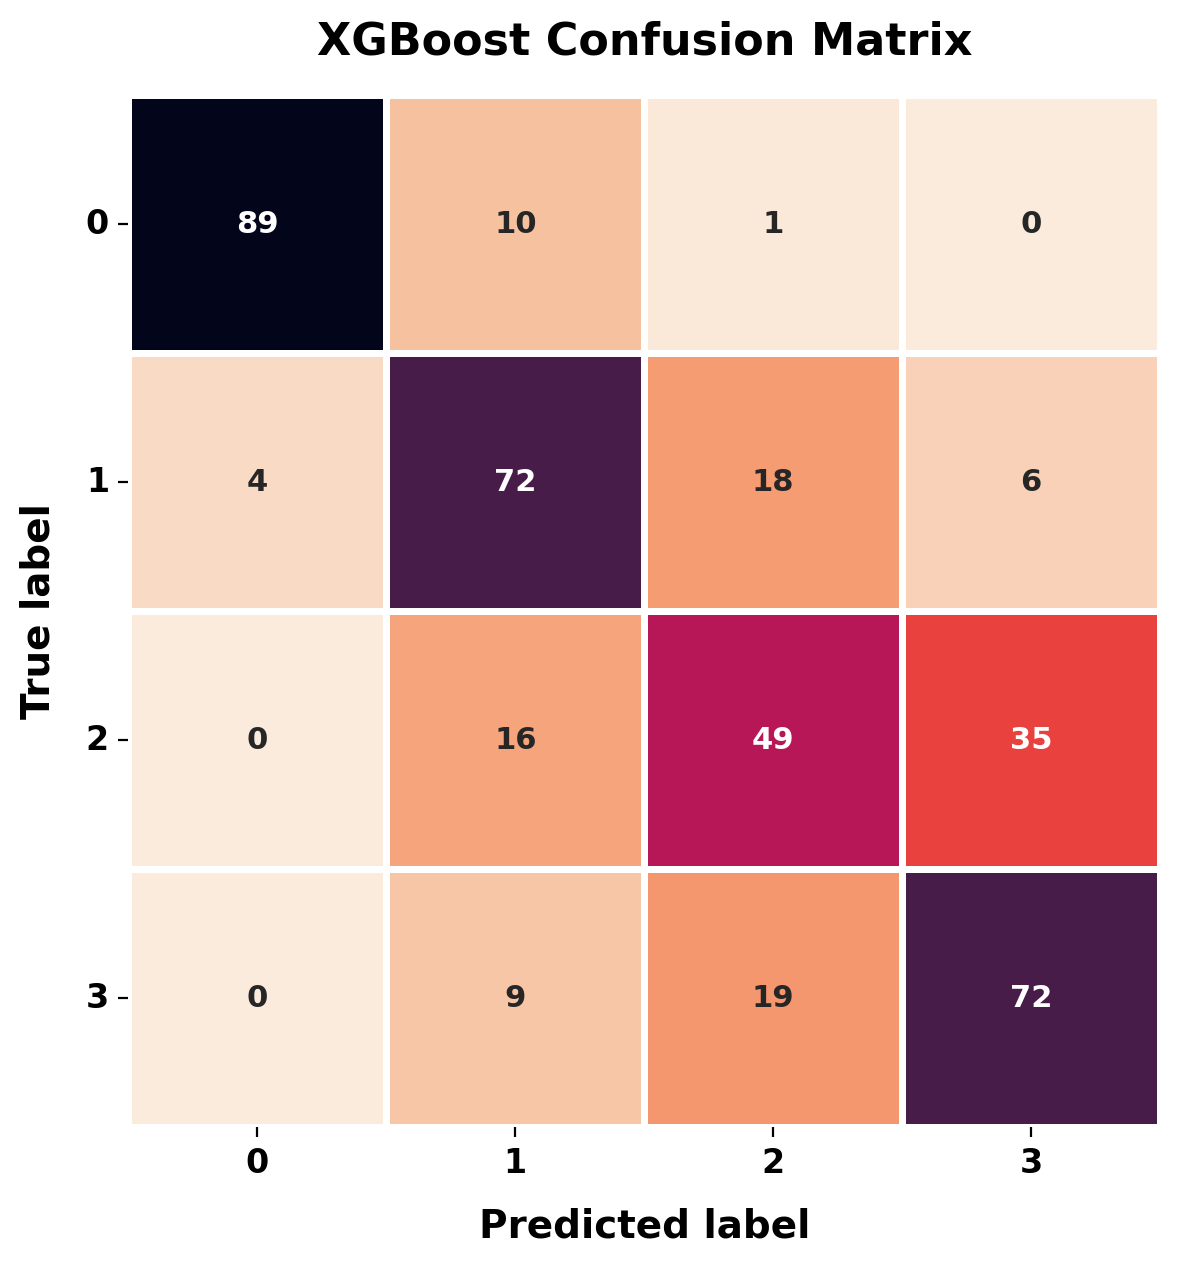

In [20]:

# weights saving and loading
xgb_clf_loaded = save_and_load_model(
    xgb_clf,
    model_dirs["xgb_clf"] / "xgboost_classifier.joblib"
    )

# test predictions
y_pred_xgb_clf, xgb_clf_results = evaluate_classification_model(
    xgb_clf_loaded,
    X_classification_test,
    y_classification_test,
    "XGBoost"
    )

print("\nXGBoost Classification Metrics")
print(f" Precision: \t\t{xgb_clf_results['Precision']}")
print(f" Recall:    \t\t{xgb_clf_results['Recall']}")
print(f" F1 Score:  \t\t{xgb_clf_results['F1']}")

print("\nXGBoost Classification Report")
print(classification_report(y_classification_test, y_pred_xgb_clf, digits=4, zero_division=0))

# confusion matrix visualization
plot_confusion_matrix(y_classification_test, y_pred_xgb_clf, "XGBoost", dpi=200)


##### **5.3.2 XGBoost Regression**

XGBoost Regression Metrics
MAE                 : 9.5688
RMSE                : 15.6599
Bias                : -0.6955
R2                  : 0.4208


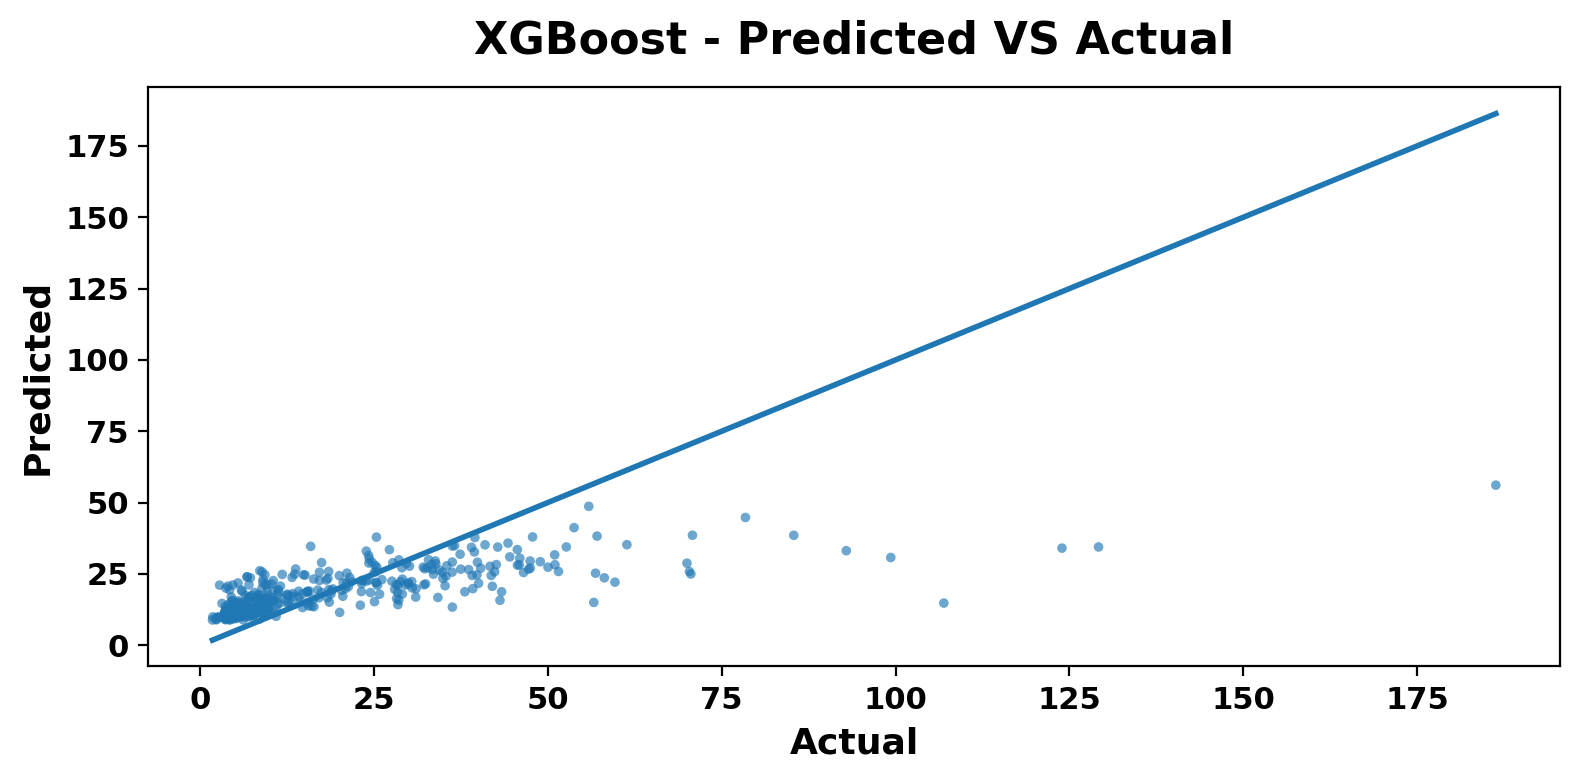

In [21]:

# weights saving and loading
xgb_reg_loaded = save_and_load_model(
    xgb_reg,
    model_dirs["xgb_reg"] / "xgboost_regressor.joblib"
    )

# test predictions
y_pred_xgb_reg, xgb_reg_results = evaluate_regression_model(
    xgb_reg_loaded,
    X_regression_test,
    y_regression_test,
    "XGBoost"
    )


# next - regression metrics
print("XGBoost Regression Metrics")
for k, v in xgb_reg_results.items():
    print(f"{k:20s}: {v}")


# lastly - scatter plot
plot_predicted_vs_actual(y_regression_test, y_pred_xgb_reg, "XGBoost", dpi=200)


### **6. Feature Importance Analysis**

#### **6.1 What is Feature Importance?**

- Feature importance helps **answer**:
  **Which input variables does the trained emulator rely on most when making predictions?**
- We have input features:
  - environmental drivers
  - hydrological variables
  - climate-related variables
  - land-use factors
  - policy/scenario variables
- Feature importance gives a ranked list of predictors that were useful to the trained model.
- In our context, this supports emulator-based teleconnection discovery by highlighting distant or indirect drivers linked to local water-quality outcomes.
- Important caution:
  - high importance means predictive usefulness inside the trained emulator
  - it does **not** automatically imply real-world causality
- General workflow: `train model ---> extract importance scores --> rank features --> visualize top features --> interpret importance plots`



In [22]:

def plot_feature_importance_barh(
    imp_df,
    value_col,
    title,
    xlabel,
    xerr_col=None,
    figsize_width=12,
    dpi=300
    ):
    
    fig, ax = plt.subplots(figsize=(figsize_width, max(6, len(imp_df) * 0.25)), dpi=dpi)
    if xerr_col is not None:
        ax.barh(
            imp_df.index,
            imp_df[value_col],
            xerr=imp_df[xerr_col],
            align="center",
            ecolor="black",
            error_kw={"capsize": 3, "elinewidth": 1}
            )
    else:
        ax.barh(
            imp_df.index,
            imp_df[value_col],
            align="center"
            )

    ax.set_title(title, fontsize=18, fontweight="bold", pad=12)
    ax.set_xlabel(xlabel, fontsize=14, fontweight="bold", labelpad=12)
    ax.set_ylabel("Features", fontsize=16, fontweight="bold", labelpad=10)

    tick_size = 12
    for t in ax.get_xticklabels():
        t.set_fontsize(tick_size)
        t.set_fontweight("bold")

    for t in ax.get_yticklabels():
        t.set_fontsize(tick_size)
        t.set_fontweight("bold")

    fig.tight_layout()
    plt.show()


#### **6.3 Random Forest Feature Importance**

- Random Forest can use different feature-importance approaches.
- Common options include:
  - **Mean Decrease in Impurity (MDI)**
  - **Permutation importance**    
- **Mean Decrease in Impurity (MDI):**
  - measures how much each feature reduces impurity across all trees
  - fast and easy to compute
- **Permutation importance:**
  - shuffles one feature at a time
  - checks how much model performance decreases
- In this notebook, we use:
  **Mean Decrease in Impurity (MDI)**
- Useful links:
  - [scikit-learn: Mean Decrease in Impurity](https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html)
  - [scikit-learn: Permutation importance](https://scikit-learn.org/stable/modules/permutation_importance.html)

,mean,std
snowpack,0.164981,0.073238
JPO4,0.113513,0.042932
JPOP,0.056999,0.027501
JPON,0.056711,0.025844
sat_def,0.049854,0.021294
evap,0.046802,0.021296
POPR,0.045233,0.013464
%sat_area,0.043203,0.019097
PO4T2R,0.035645,0.011463
baseflow,0.033512,0.014772


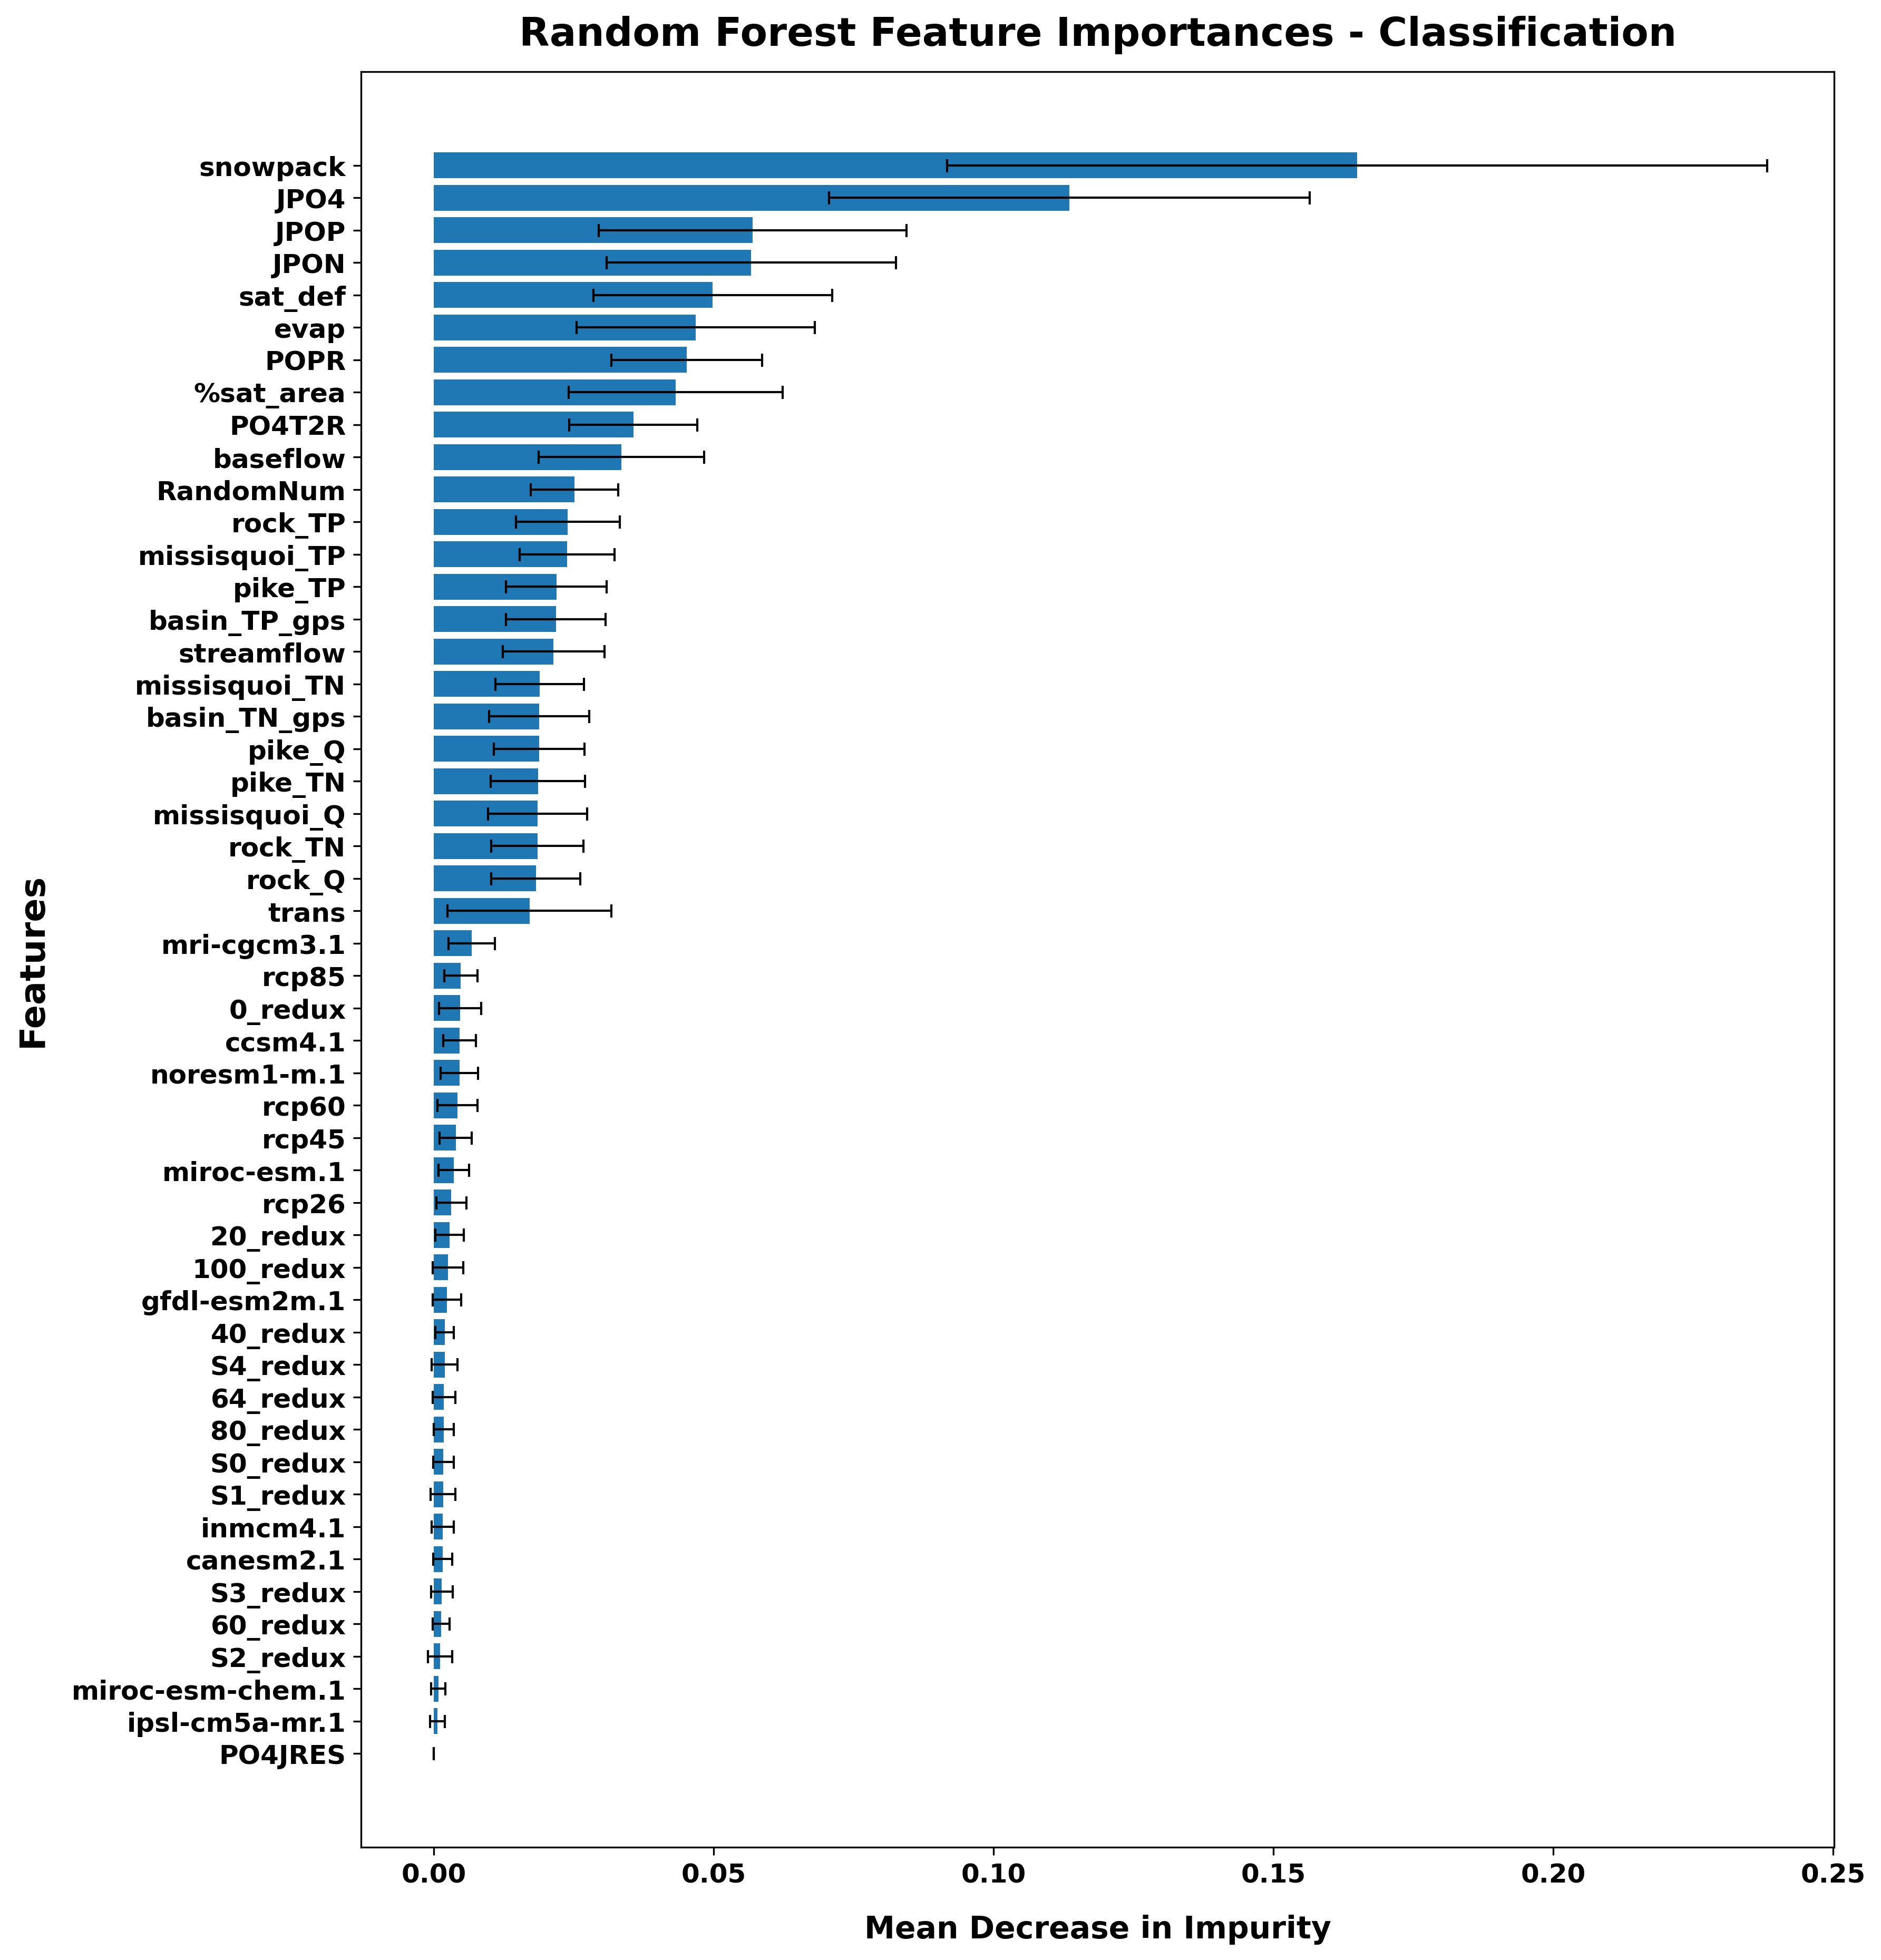

In [23]:

# RF Classificatin Feature Importance Plot
# laod the model and get the feature importance
rf_clf_loaded = save_and_load_model(
    rf_clf,
    model_dirs["rf_clf"] / "rf_classifier.joblib"
    )
imp_mean = rf_clf_loaded.feature_importances_
imp_std = np.std([est.feature_importances_ for est in rf_clf_loaded.estimators_], axis=0)

rf_clf_imp_df = (
    pd.DataFrame(
        {
            "mean": imp_mean,
            "std": imp_std
        },
        index=X_classification_test.columns
    )
    .sort_values("mean", ascending=True)
    )

display(rf_clf_imp_df.sort_values("mean", ascending=False).head(15))

plot_feature_importance_barh(
    imp_df=rf_clf_imp_df,
    value_col="mean",
    xerr_col="std",
    title="Random Forest Feature Importances - Classification",
    xlabel="Mean Decrease in Impurity",
    )


,mean,std
JPO4,0.255551,0.038410
POPR,0.094581,0.034570
sat_def,0.089752,0.032222
JPON,0.078226,0.028546
JPOP,0.076221,0.036326
PO4T2R,0.067013,0.021797
evap,0.055211,0.024231
snowpack,0.045029,0.021694
%sat_area,0.036261,0.030653
RandomNum,0.025705,0.013667


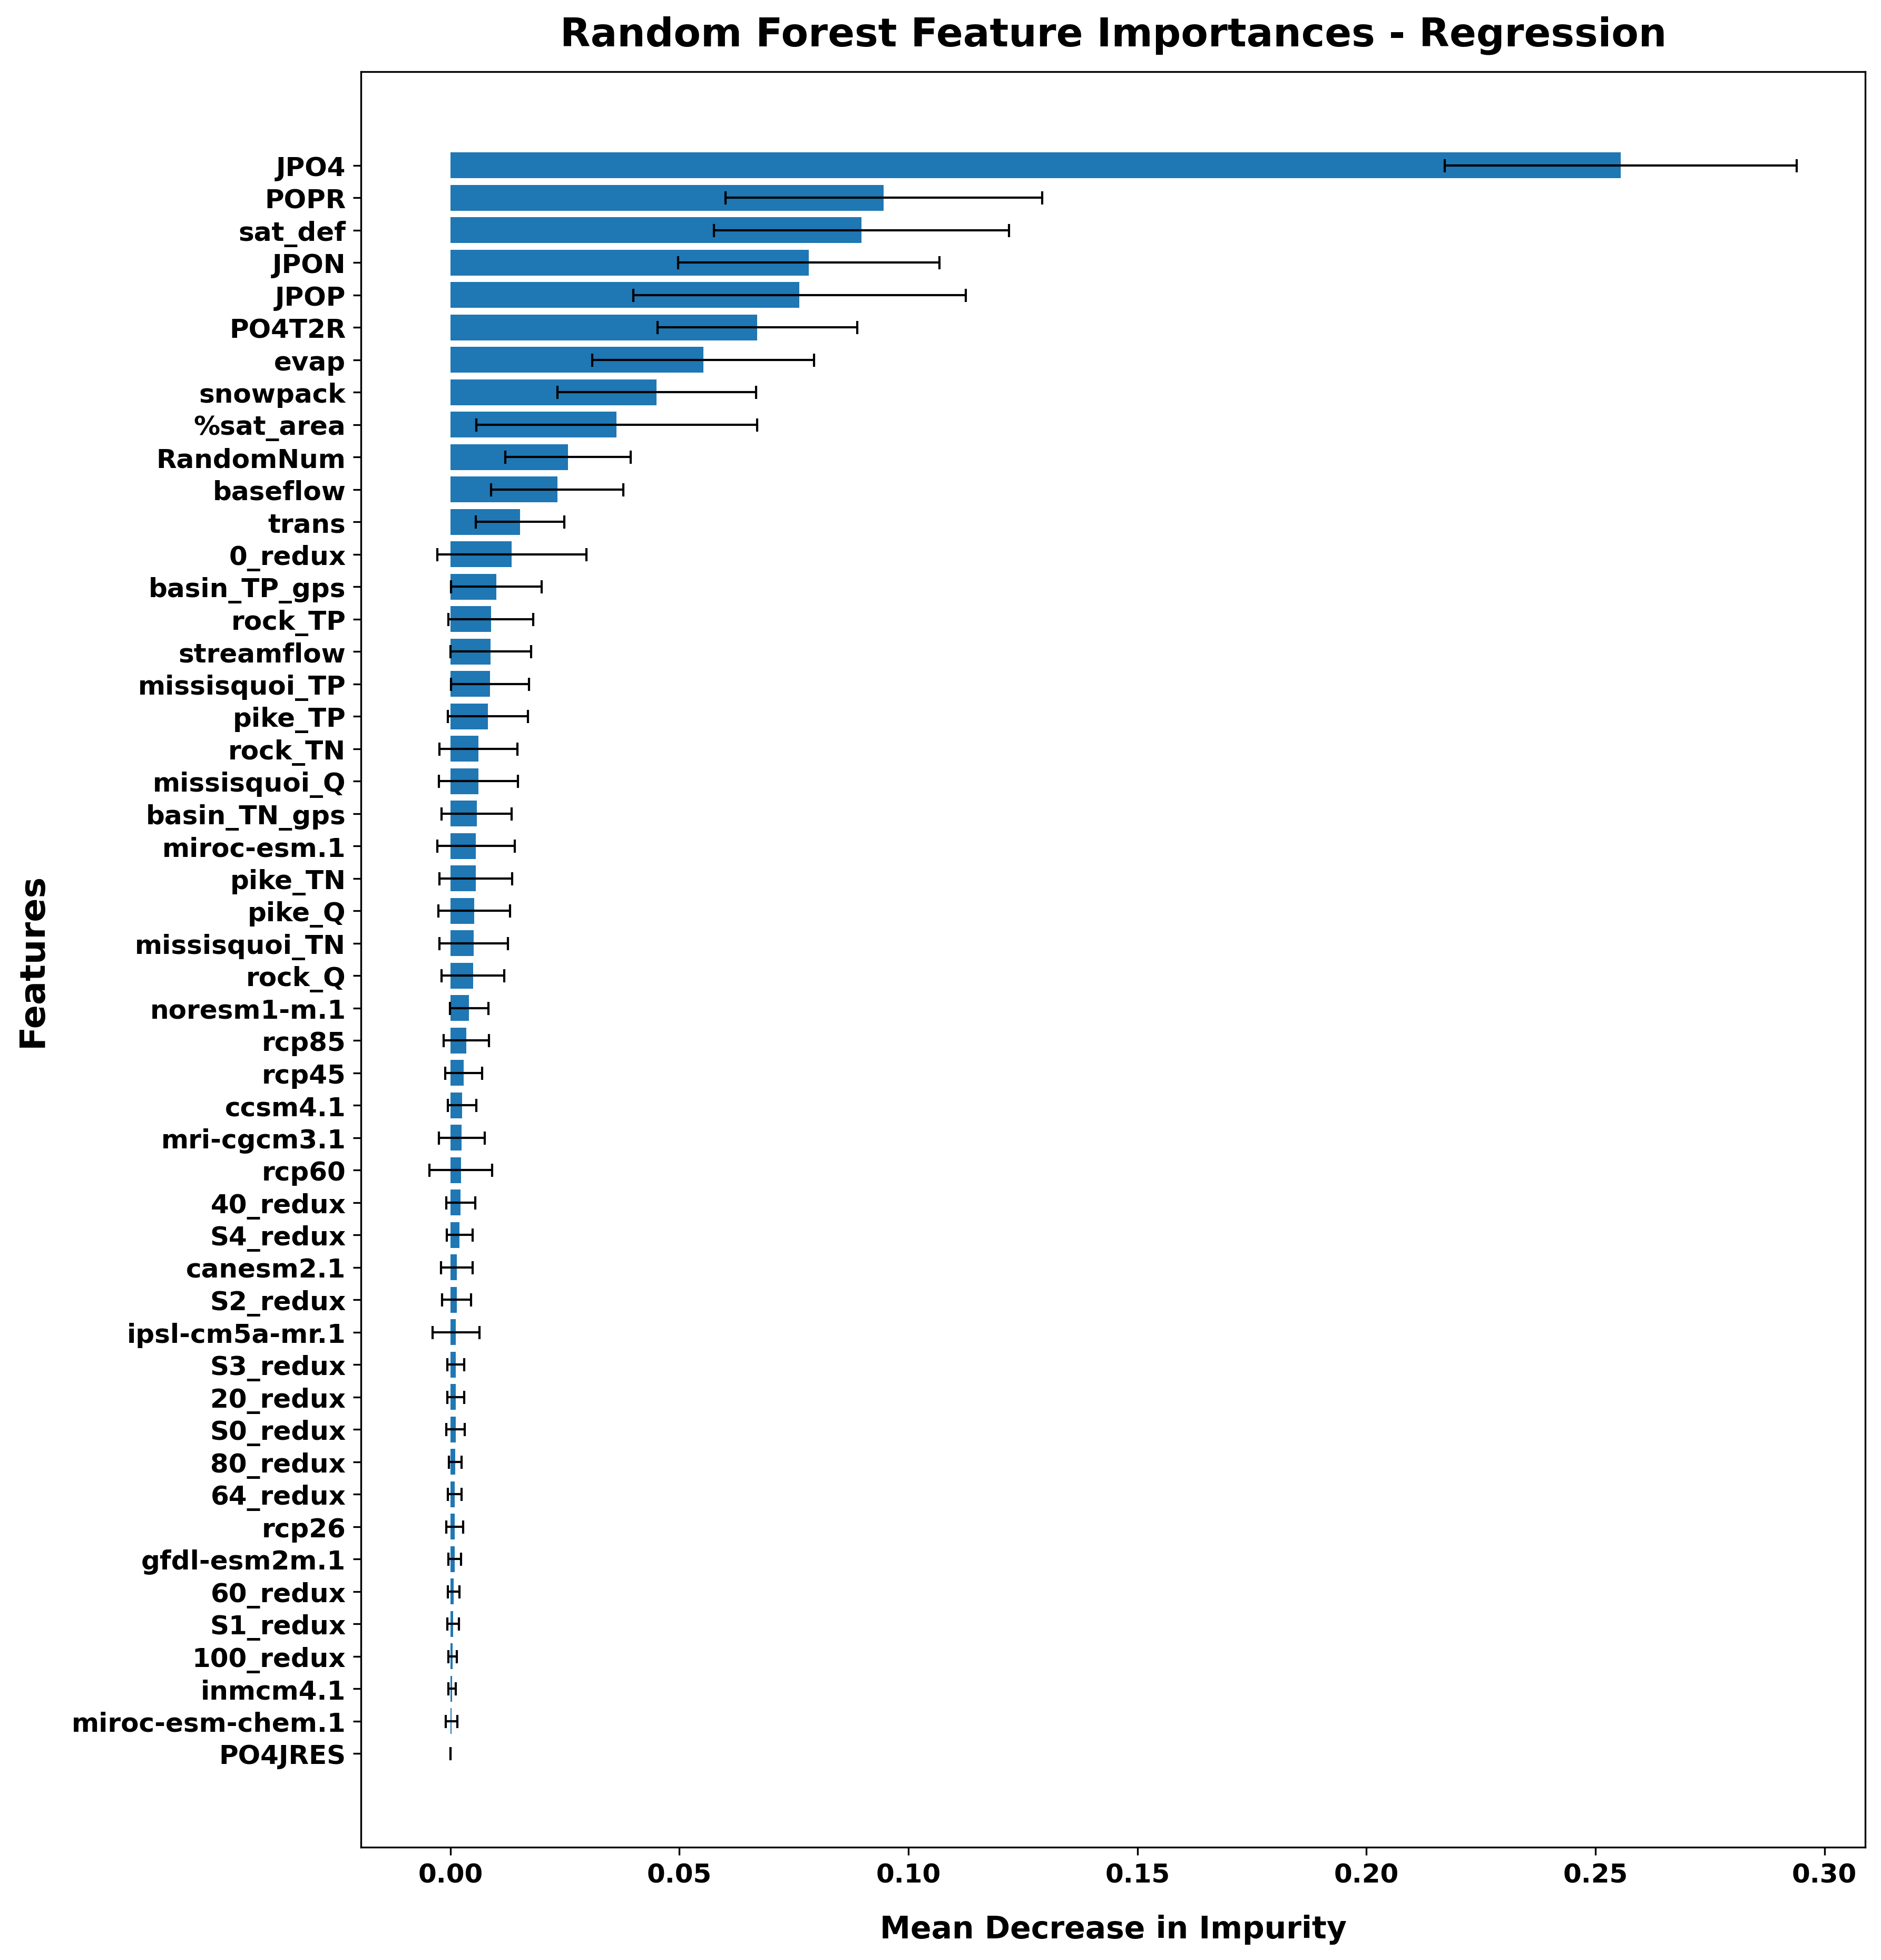

In [24]:

# RF Regression Feature Importance Plot
# load the weights
rf_reg_loaded = save_and_load_model(
    rf_reg,
    model_dirs["rf_reg"] / "rf_regressor.joblib"
    )

imp_mean = rf_reg_loaded.feature_importances_
imp_std = np.std([est.feature_importances_ for est in rf_reg_loaded.estimators_], axis=0)

rf_reg_imp_df = (
        pd.DataFrame(
            {
                "mean": imp_mean,
                "std": imp_std
            },
            index=X_regression_test.columns).sort_values("mean", ascending=True)
        )

display(rf_reg_imp_df.sort_values("mean", ascending=False).head(15))

plot_feature_importance_barh(
    imp_df=rf_reg_imp_df,
    value_col="mean",
    xerr_col="std",
    title="Random Forest Feature Importances - Regression",
    xlabel="Mean Decrease in Impurity",
    )


#### **6.4 Feature importance in LightGBM**

- LightGBM provides different feature-importance options.
- Common options include:
  - **split importance**
  - **gain importance**
- **Split importance:**
  - counts how many times a feature is used in tree splits
  - simple and easy to understand
  - does not measure how much the split improved the model
- **Gain importance:**
  - measures total improvement in the objective from splits using that feature
  - usually more informative than split count
  - better reflects how useful the feature was during boosting
- In this notebook, we use:
  **Gain importance**
- Useful links:
  - [LightGBM: LGBMClassifier importance_type](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html)
  - [LightGBM: plot_importance](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.plot_importance.html)

,gain
snowpack,0.324003
JPO4,0.185577
POPR,0.076143
JPON,0.067548
JPOP,0.058894
sat_def,0.056179
%sat_area,0.040302
evap,0.037683
baseflow,0.035216
PO4T2R,0.032753


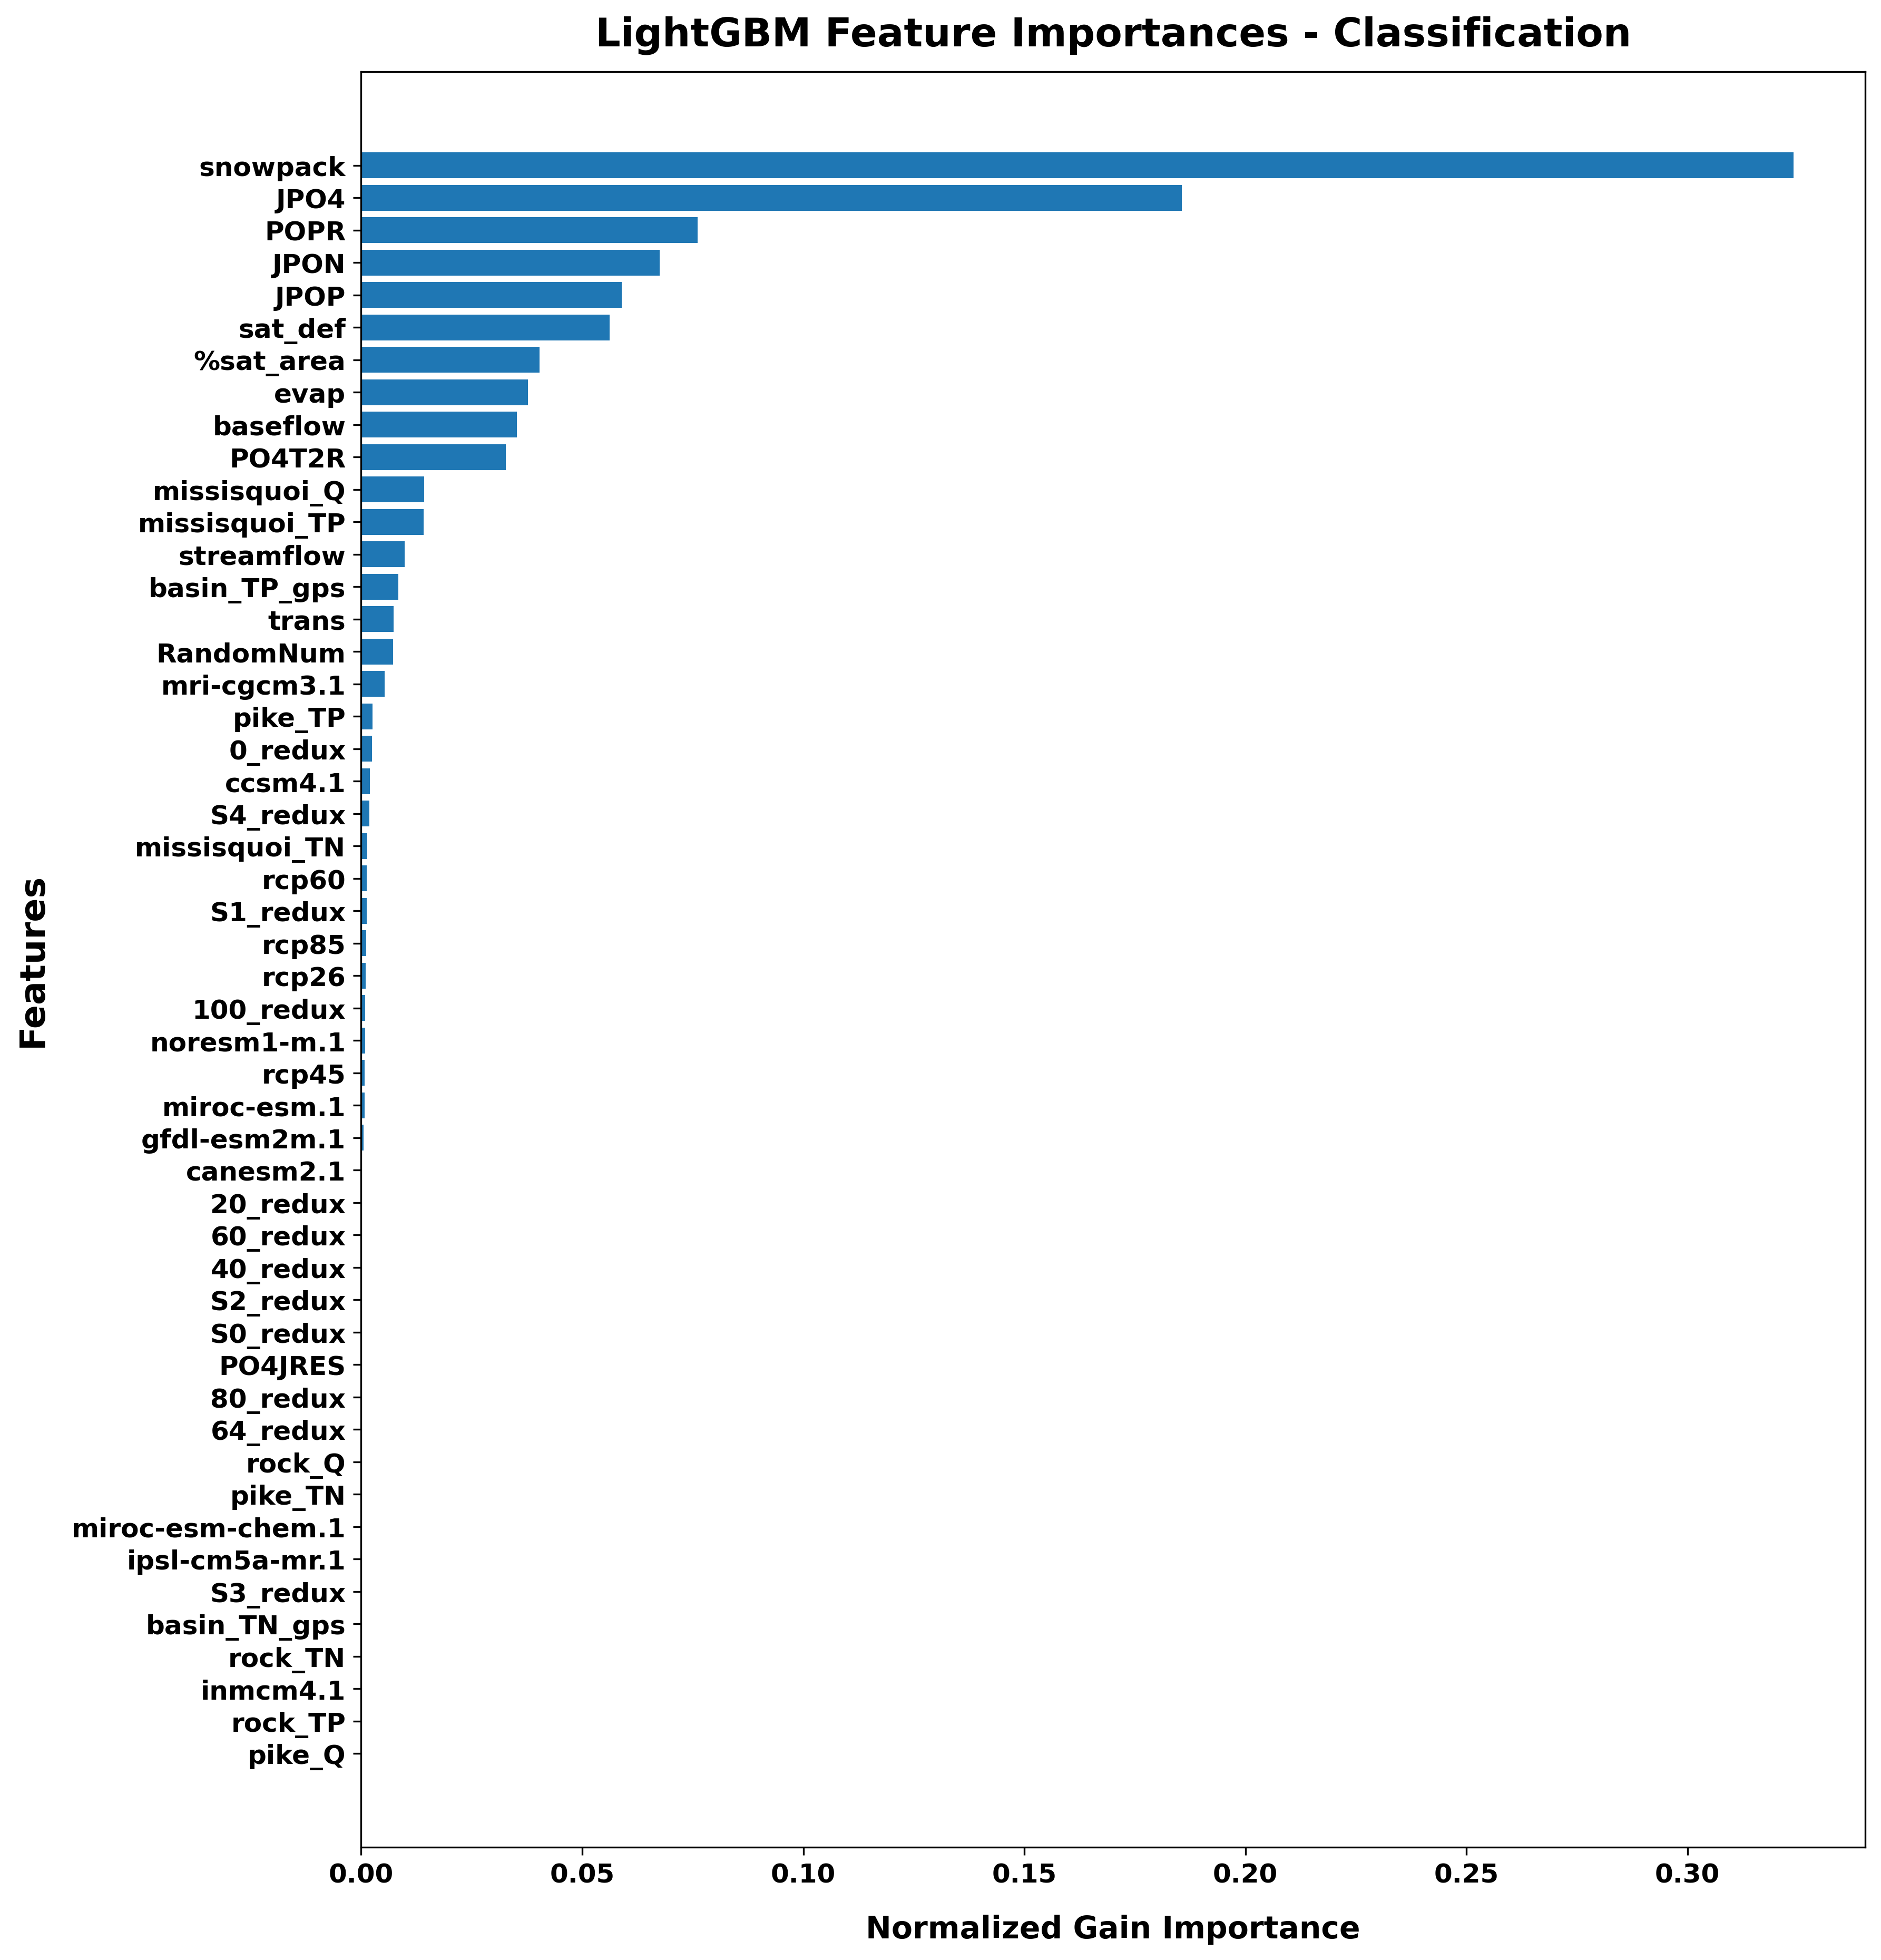

In [25]:

# LightGBM Classification Feature Importance Plot
# load the model 
lgbm_clf_loaded = save_and_load_model(
    lgbm_clf,
    model_dirs["lgbm_clf"] / "lightgbm_classifier.joblib"
    )

booster = getattr(lgbm_clf_loaded, "booster_", lgbm_clf_loaded)
feat_names = booster.feature_name()

imp_gain = booster.feature_importance(importance_type="gain").astype(float)
imp_gain = imp_gain / (imp_gain.sum() + 1e-12)

lgbm_clf_imp_df = (
    pd.DataFrame(
        {
            "feature": feat_names,
            "gain": imp_gain
        }
    ).set_index("feature").reindex(X_classification_test.columns).fillna(0.0).sort_values("gain", ascending=True)
    )

display(lgbm_clf_imp_df.sort_values("gain", ascending=False).head(15))

plot_feature_importance_barh(
    imp_df=lgbm_clf_imp_df,
    value_col="gain",
    title="LightGBM Feature Importances - Classification",
    xlabel="Normalized Gain Importance",
    )


,gain
JPO4,0.283270
sat_def,0.105480
JPON,0.104236
JPOP,0.098462
snowpack,0.084377
POPR,0.073231
evap,0.056513
PO4T2R,0.050233
missisquoi_TP,0.025071
missisquoi_Q,0.023849


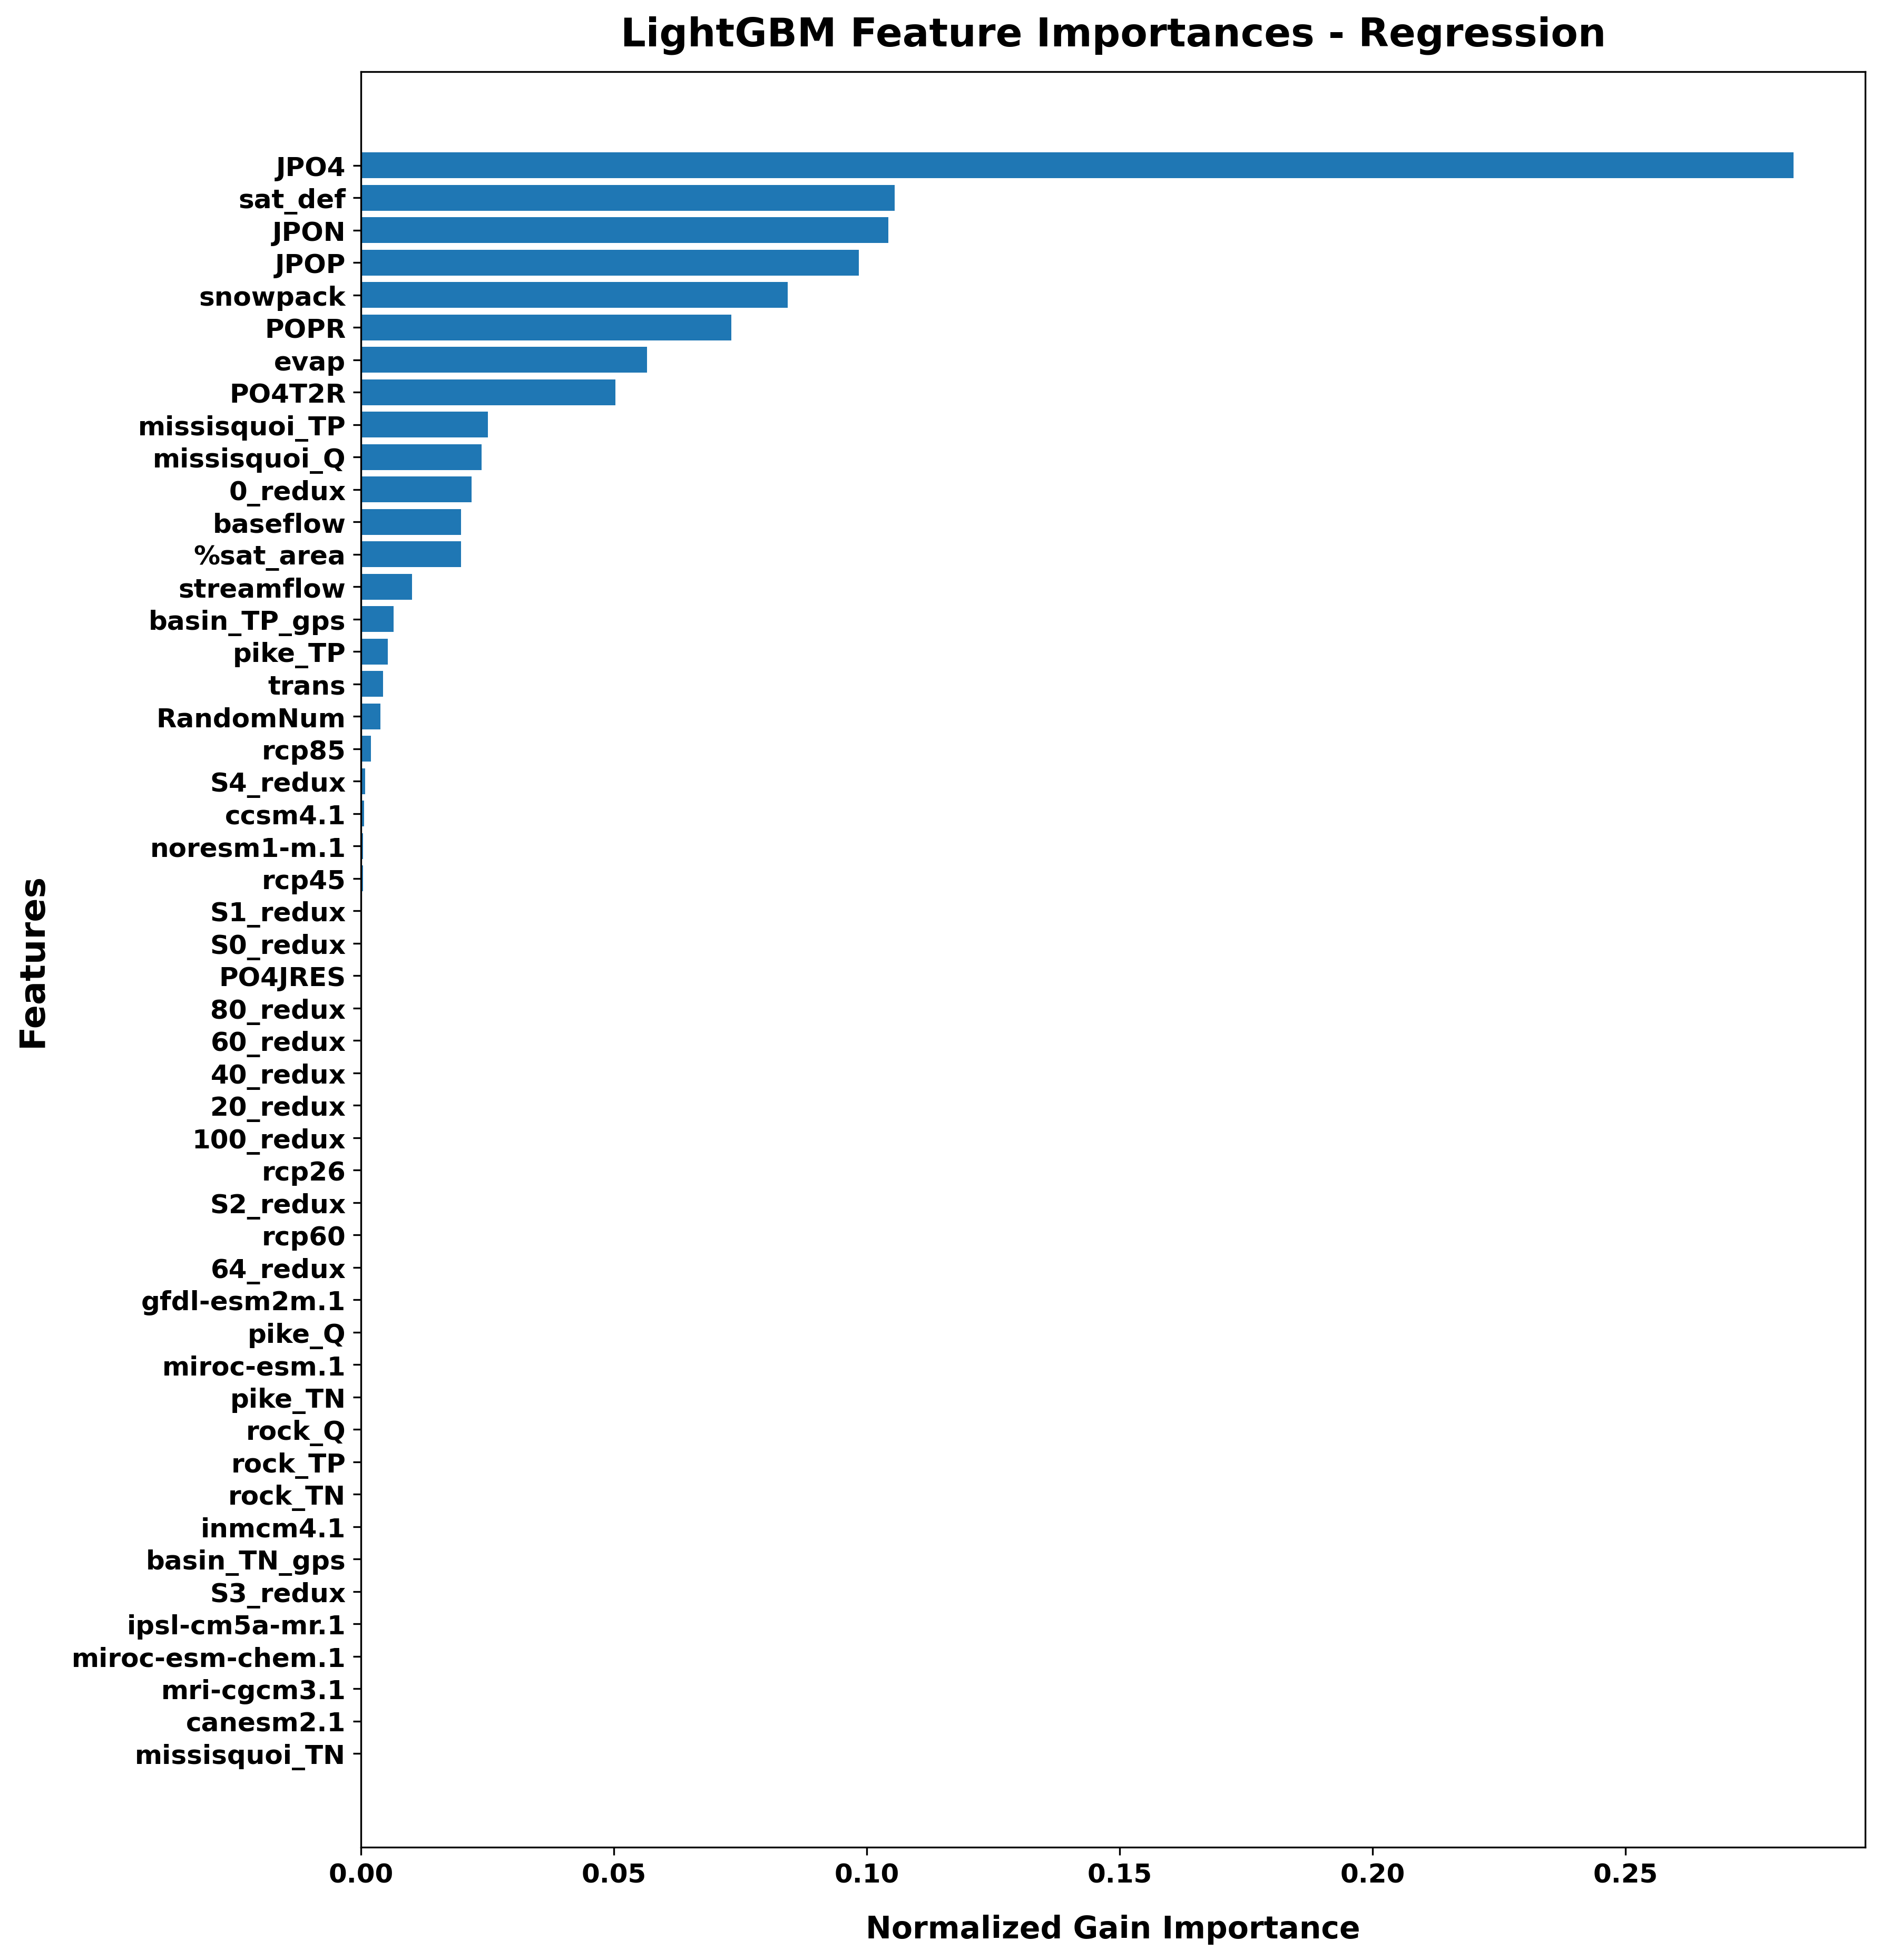

In [26]:

# LightGBM Regression Feaure Importance Plot
# load the model
lgbm_reg_loaded = save_and_load_model(
    lgbm_reg,
    model_dirs["lgbm_reg"] / "lightgbm_regressor.joblib"
    )

booster = getattr(lgbm_reg_loaded, "booster_", lgbm_reg_loaded)
feat_names = booster.feature_name()

imp_gain = booster.feature_importance(importance_type="gain").astype(float)
imp_gain = imp_gain / (imp_gain.sum() + 1e-12)

lgbm_reg_imp_df = (
    pd.DataFrame(
        {
            "feature": feat_names,
            "gain": imp_gain
        }
    ).set_index("feature").reindex(X_regression_test.columns).fillna(0.0).sort_values("gain", ascending=True)
    )

display(lgbm_reg_imp_df.sort_values("gain", ascending=False).head(15))

plot_feature_importance_barh(
    imp_df=lgbm_reg_imp_df,
    value_col="gain",
    title="LightGBM Feature Importances - Regression",
    xlabel="Normalized Gain Importance",
    )


#### **6.5 Feature importance in XGBoost**

- XGBoost provides following feature-importance options.
  - **weight**
  - **gain**
  - **cover**
  - **total_gain**
  - **total_cover**
- **Weight:**
  - counts how many times a feature is used for splitting
- **Gain:**
  - average improvement in the objective when the feature is used
- **Cover:**
  - average number of samples affected by splits using the feature
- **Total gain:**
  - total improvement from all splits using the feature
- **Total cover:**
  - total sample coverage from all splits using the feature
- In this notebook, we use:
  **Gain importance**
- Useful links:
  - [XGBoost: Python API feature importance](https://xgboost.readthedocs.io/en/latest/python/python_api.html)
  - [XGBoost: plot_importance](https://xgboost.readthedocs.io/en/latest/python/python_api.html#xgboost.plot_importance)

,mean
snowpack,0.146681
JPO4,0.074418
pike_Q,0.065407
sat_def,0.047469
%sat_area,0.040821
POPR,0.037964
JPOP,0.030440
JPON,0.030090
baseflow,0.028046
pike_TN,0.026715


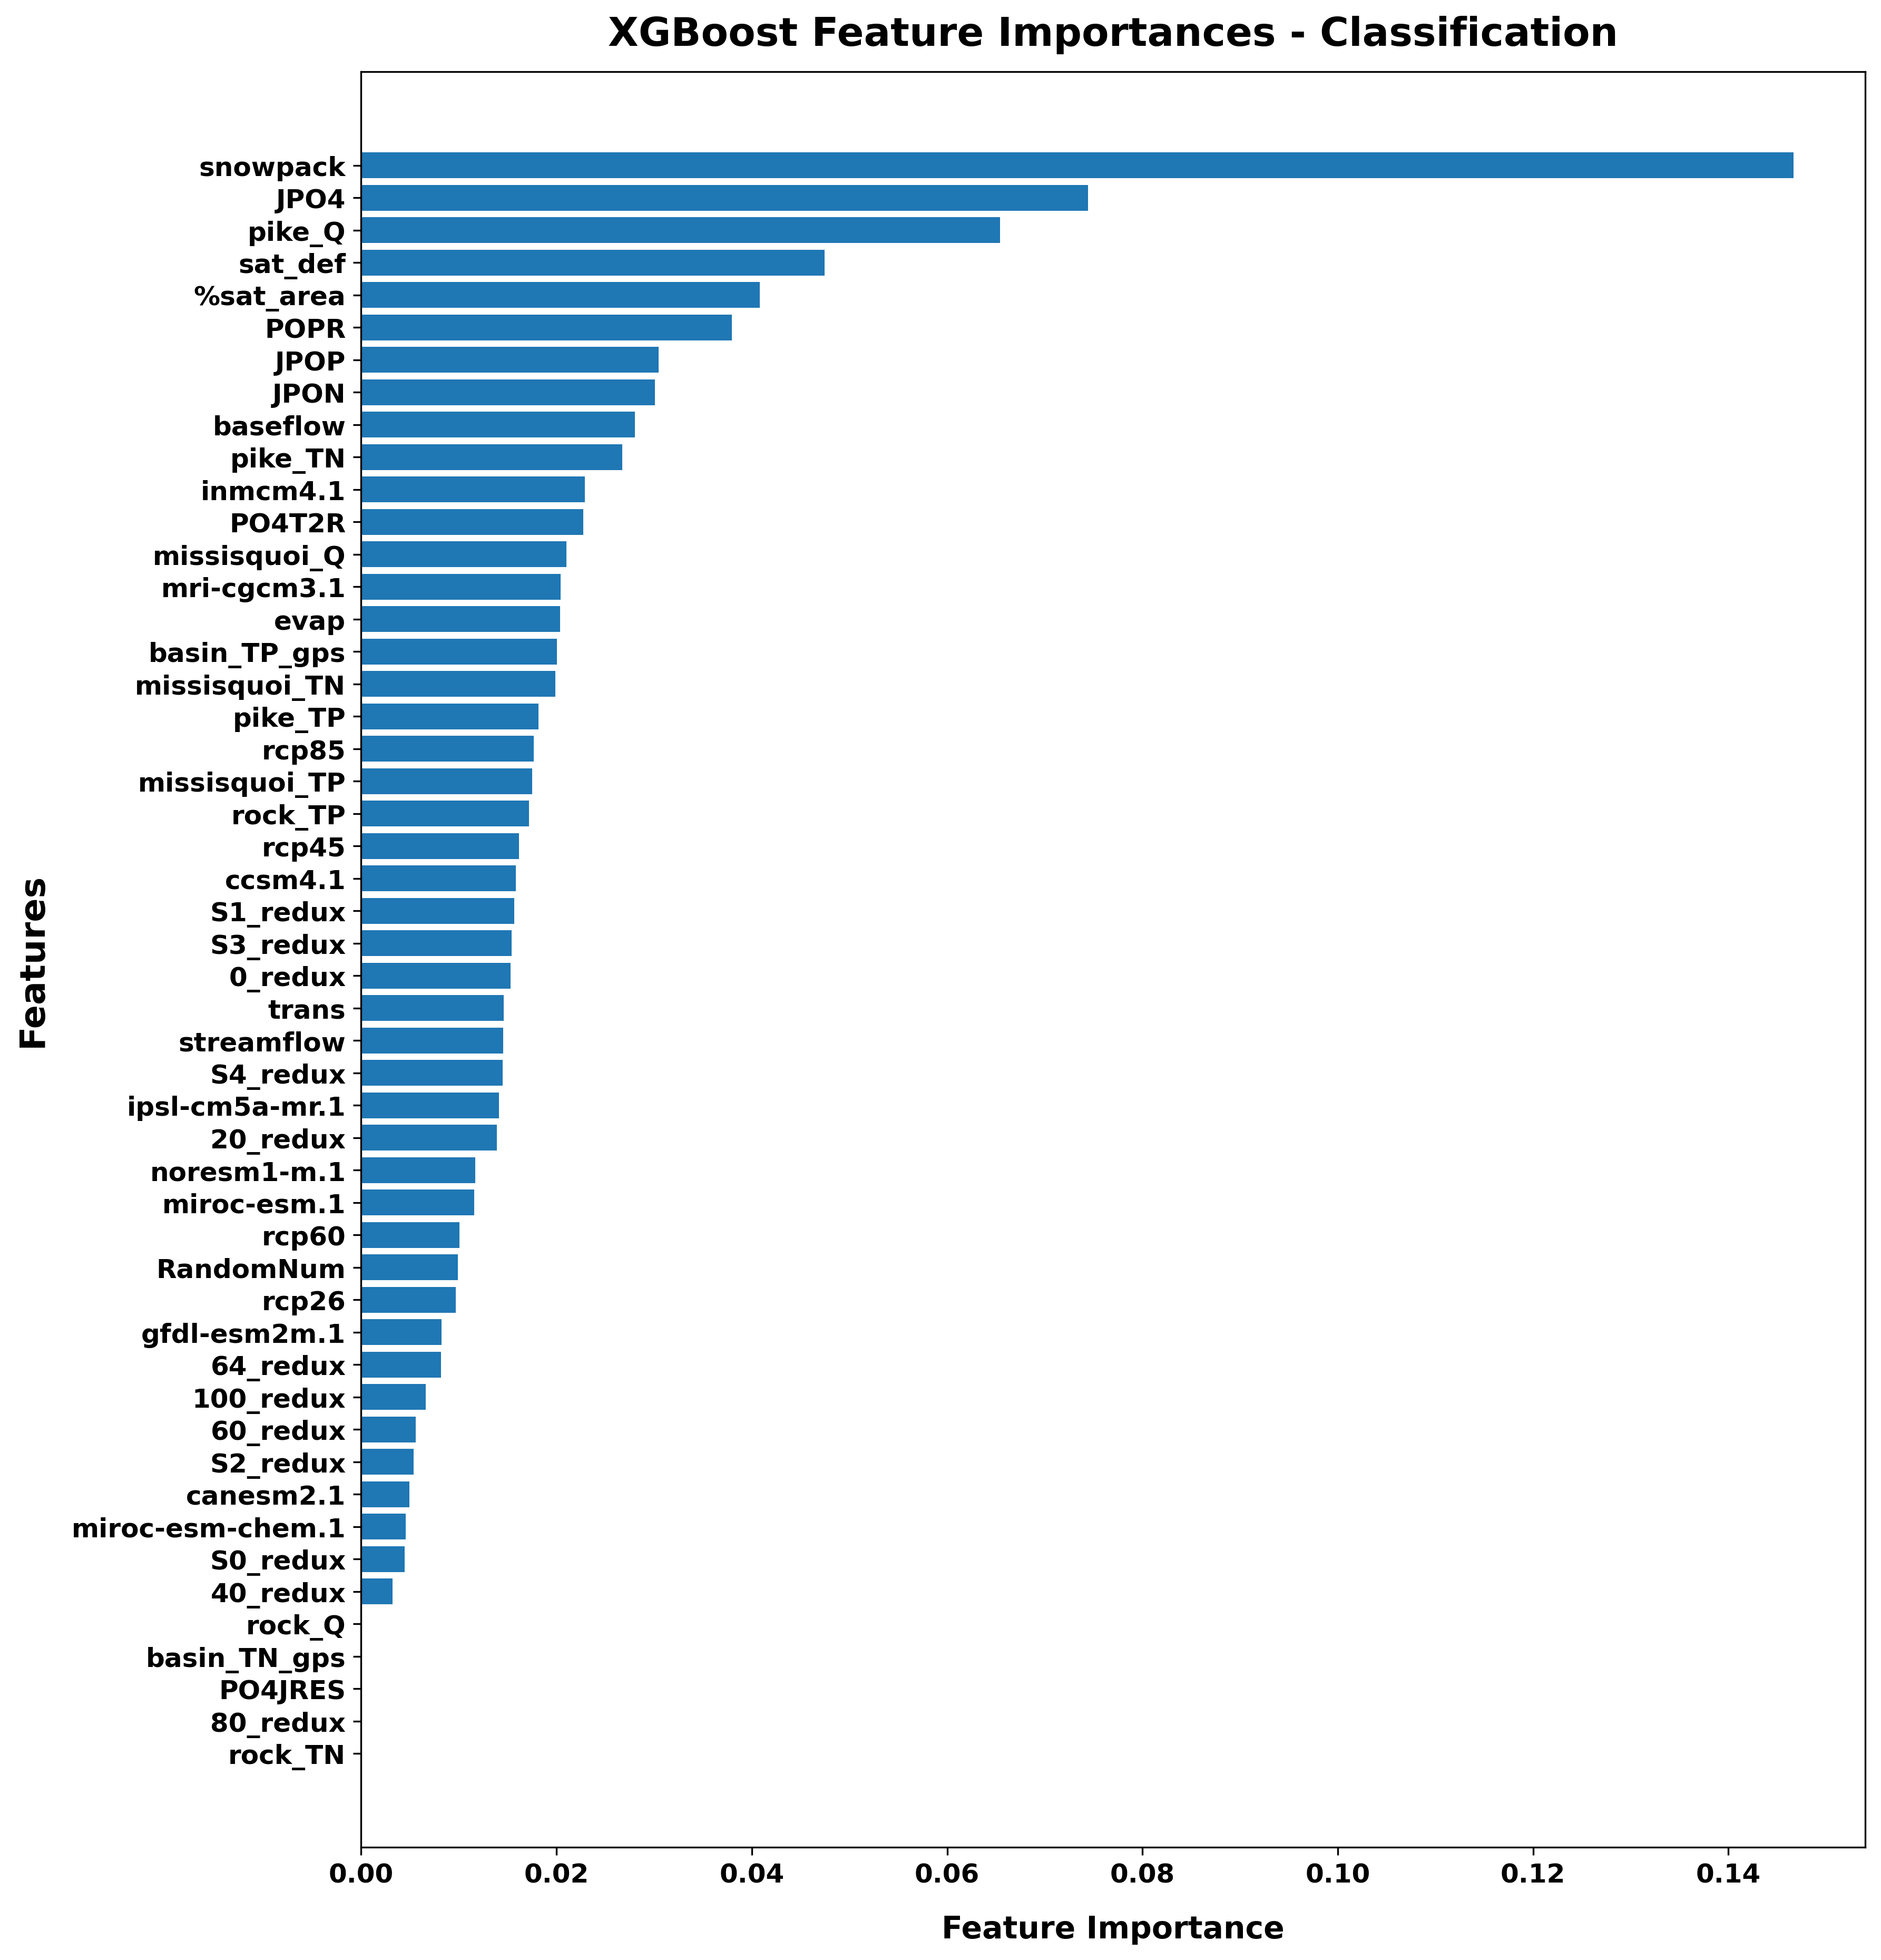

In [27]:

# XGBoost Classification Feature Importance Plot
# load the model
xgb_clf_loaded = save_and_load_model(
    xgb_clf,
    model_dirs["xgb_clf"] / "xgboost_classifier.joblib"
    )

imp_mean = xgb_clf_loaded.feature_importances_

xgb_clf_imp_df = (
    pd.DataFrame(
        {
            "mean": imp_mean
        },
        index=X_classification_test.columns).sort_values("mean", ascending=True)
    )

display(xgb_clf_imp_df.sort_values("mean", ascending=False).head(15))

plot_feature_importance_barh(
    imp_df=xgb_clf_imp_df,
    value_col="mean",
    title="XGBoost Feature Importances - Classification",
    xlabel="Feature Importance",
    )


,mean
JPO4,0.077150
0_redux,0.058700
sat_def,0.056718
pike_TP,0.053300
missisquoi_Q,0.048805
snowpack,0.045153
JPOP,0.041080
POPR,0.038782
rcp60,0.035914
S4_redux,0.035287


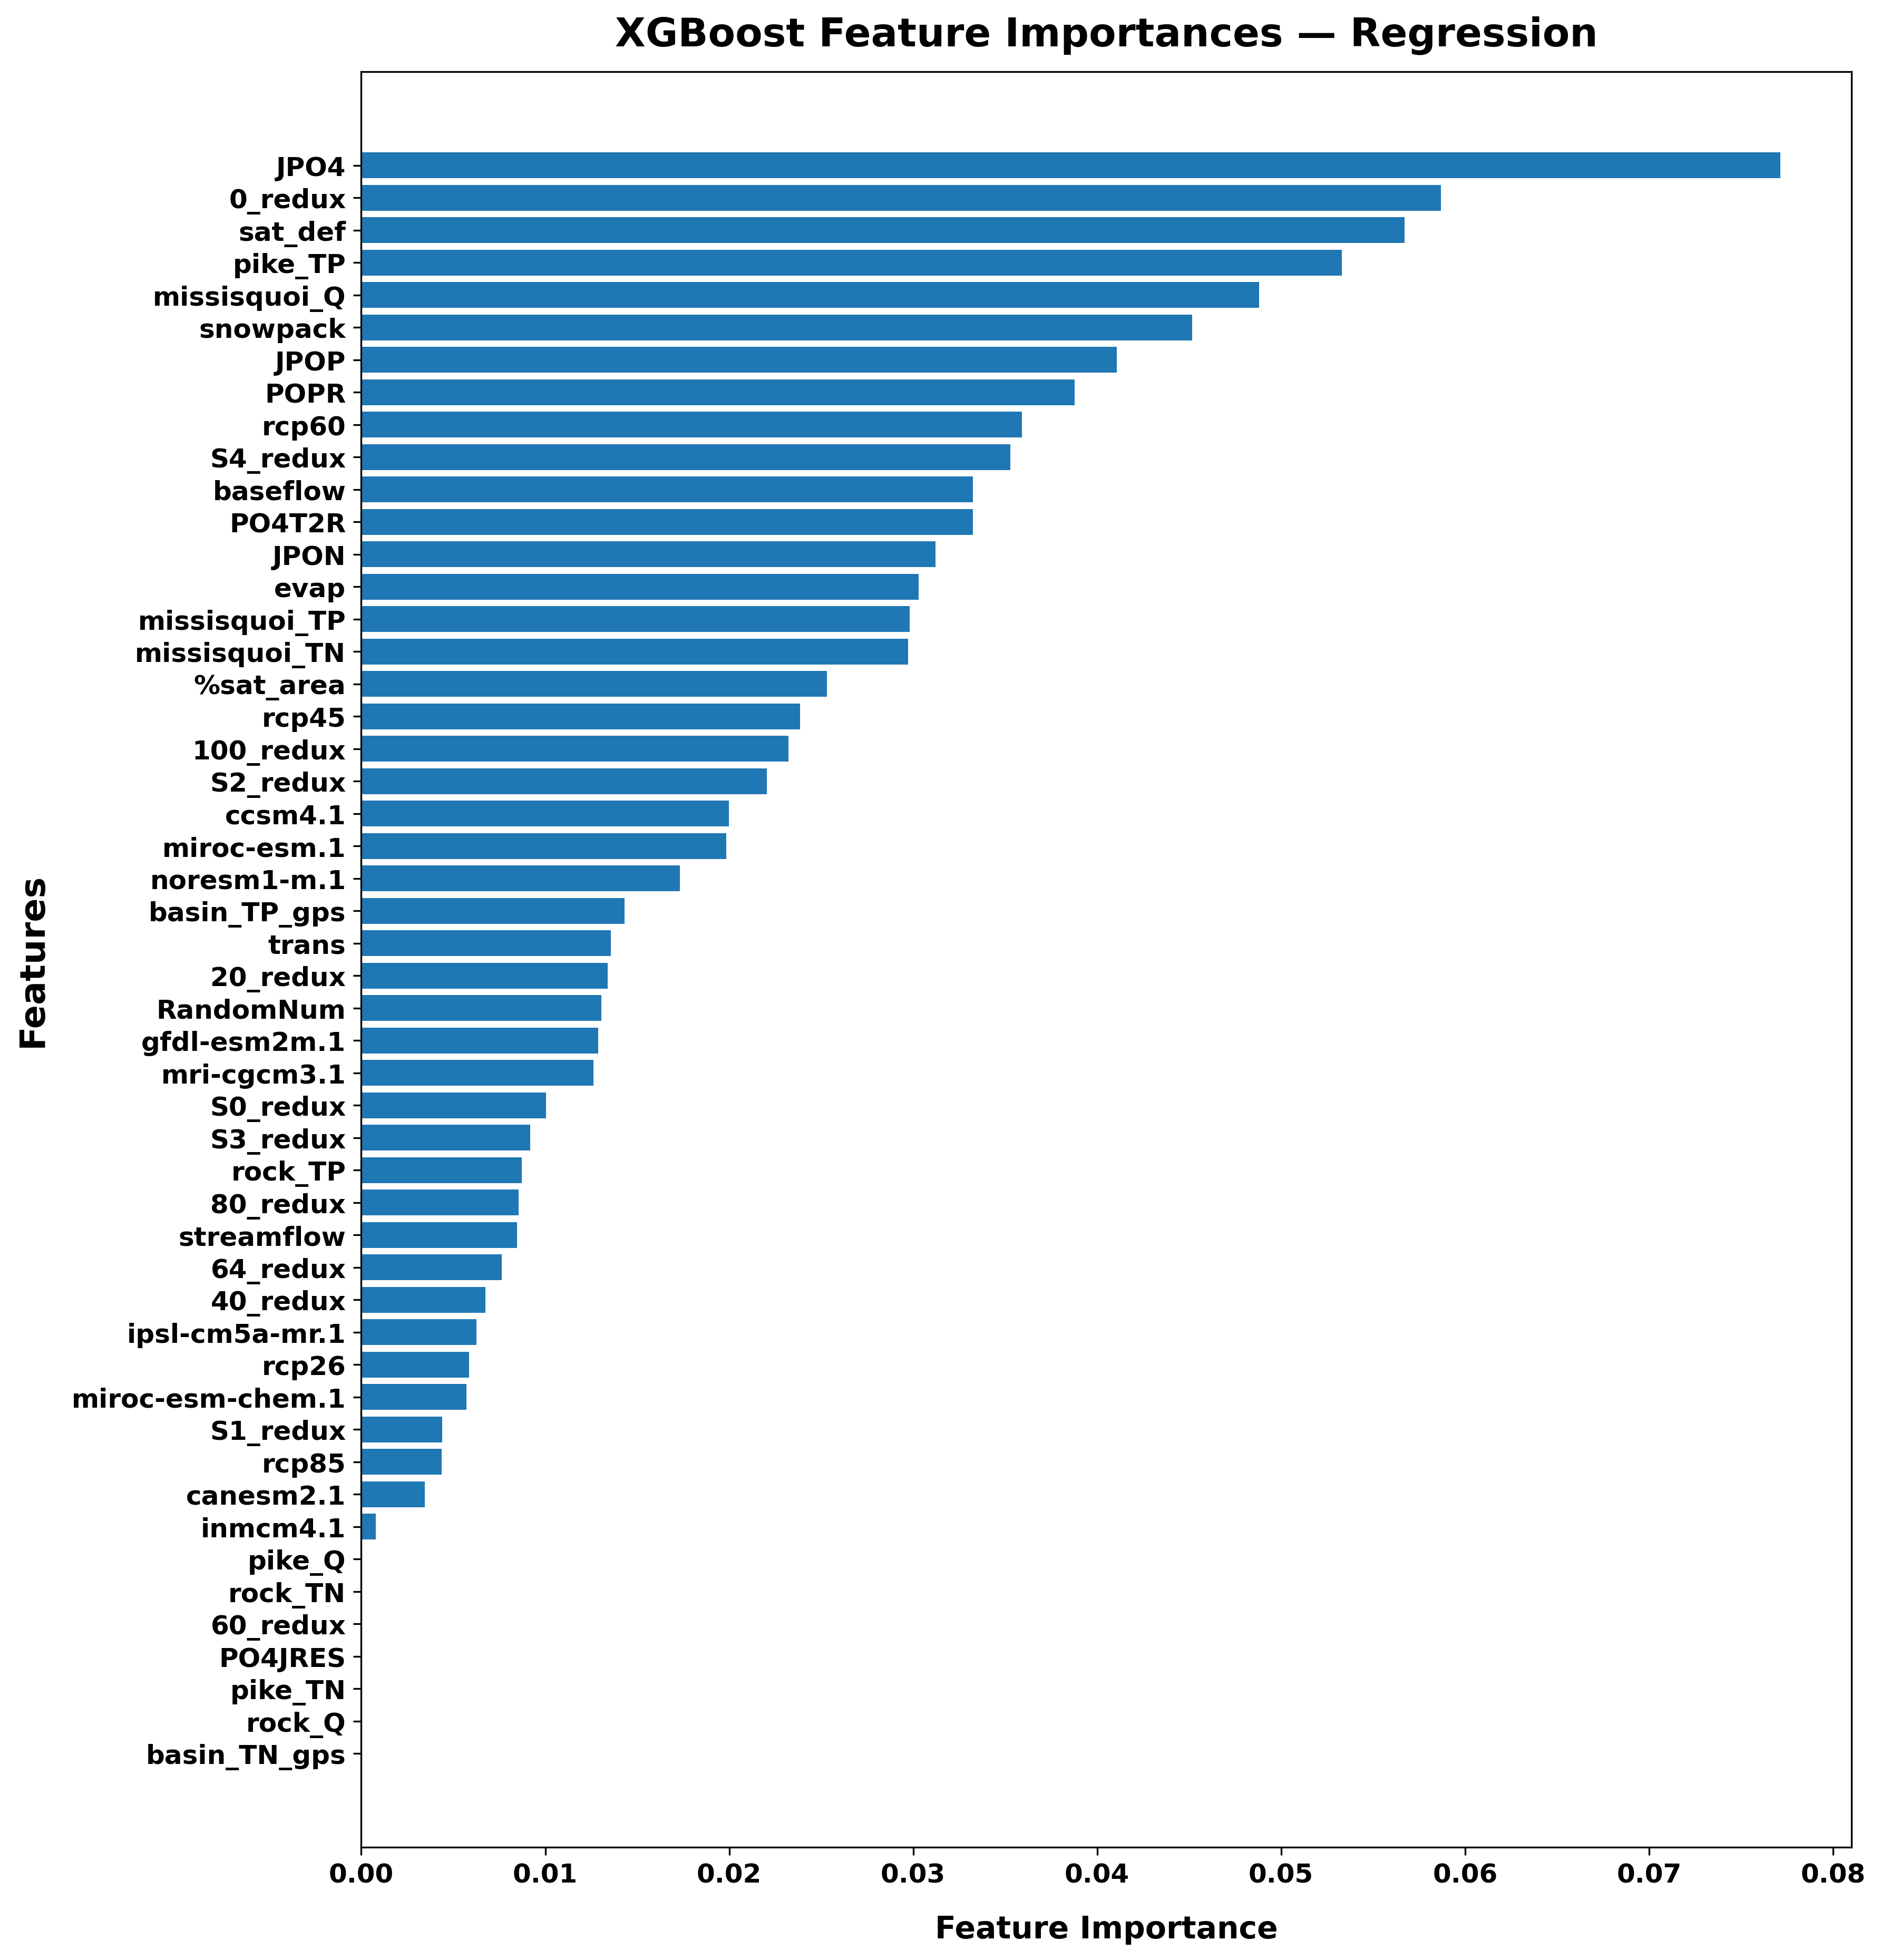

In [28]:

# XGBoost Regression Feature Importance Plot
# load the model
xgb_reg_loaded = save_and_load_model(
    xgb_reg,
    model_dirs["xgb_reg"] / "xgboost_regressor.joblib"
    )

imp_mean = xgb_reg_loaded.feature_importances_

xgb_reg_imp_df = (
    pd.DataFrame(
        {
            "mean": imp_mean
        },
        index=X_regression_test.columns
    ).sort_values("mean", ascending=True)
    )

display(xgb_reg_imp_df.sort_values("mean", ascending=False).head(15))

plot_feature_importance_barh(
    imp_df=xgb_reg_imp_df,
    value_col="mean",
    title="XGBoost Feature Importances — Regression",
    xlabel="Feature Importance",
    )


### **7. Partial Dependence Plots (PDPs)**
    
#### **7.1 What are Partial Dependence Plots (PDPs)?**
- Feature importance tells us:
  **Which variables were important to the model**
- But feature importance does **not** tell us:
  - whether the relationship is positive or negative
  - how the prediction changes as a feature changes
  - whether the effect is linear, nonlinear, threshold-based, or saturating
- Example:
  A feature may have very high importance, but:
  - does increasing it increase chlorophyll-a?
  - does it decrease chlorophyll-a?
  - does it increase only after some threshold?
  - does the response saturate after some point?
- PDPs help answer these questions.
#### **7.2 Main idea of PDPs**
- A Partial Dependence Plot shows:
  **How model predictions change as one feature changes while averaging over the remaining features**
- **General intuition:**
    - Vary one feature
    - Keep other features from the dataset
    - Average predictions
    - Observe the response trend
- **PDPs help us visualize:**
    - Direction of effect
    - Magnitude of effect
    - Nonlinear behavior
    - Potential regime shifts
- **How PDPs will be used in this workshop:**
    - PDPs help interpret emulator behavior.
    - We will connect PDPs with:
        - Teleconnection discovery
        - Environmental interpretation
        - Policy interpretation
        - Sensitivity analysis

`NOTE: PDPs visualize model behavior, not True causality.`

#### **7.3 Bootstrapping for PDPs**
` PDPs help us visualize how model predictions change as a feature changes. `
There exist a limitation `a single PDP curve may depend heavily on one particular sampled dataset.`

If we compute PDP only once:
- We may overinterpret the signal
- We may assume the learned relationship is stronger
- The curve may reflect sampling noise or scenario-specific patterns
  
Bootstrapping address above limitation. Main Idea:
- Repeatedly resample the dataset
- Recompute the PDP many times
- Compare the resulting curves
  
Instead of trusting one PDP curve:
- We generate multiple PDP curves
- Each uses a different resampled version of data
  
This evaluate:
- Stability
- Consistency
- Uncertainty in the learned response

#### **7.4 PDP Model Selection for This Workshop**
In the full workflow, PDPs can be generated for all trained emulator models.

However, for this workshop, we will focus on the best-performing model from each task to keep the interpretation clear and manageable.

Based on the earlier evaluation for the current dataset:

- **XGBoost performed best for the classification task**, so we use the **XGBoost Classifier** for trophic-state PDPs.
- **Random Forest performed best for the regression task**, so we use the **Random Forest Regressor** for chlorophyll-a surface mean PDPs.

This allows us to demonstrate the PDP workflow using the strongest emulator for each prediction objective.

PDPs for the remaining models can be computed using the same structure.


In [37]:

# a few helper functions
def get_top_features(imp_df, score_col, top_k=6):
    return (
        imp_df.sort_values(score_col, ascending=False)
        .head(top_k)
        .index
        .tolist()
    )


def make_pdp_sample(X_train, subsample_n=500, random_state=14912, replace=False):
    rng = np.random.default_rng(random_state)
    idx = rng.choice(
        X_train.index,
        size=min(subsample_n, len(X_train)),
        replace=replace
    )

    X_small = X_train.loc[idx].copy()

    int_cols = X_small.select_dtypes(include=["int", "int64", "int32"]).columns
    X_small[int_cols] = X_small[int_cols].astype(float)

    return X_small

    
def set_single_thread(model):
    try:
        model.set_params(n_jobs=1)
    except Exception:
        if hasattr(model, "n_jobs"):
            model.n_jobs = 1

    # Lets turn off model-level verbose output
    try:
        model.set_params(verbose=0)
    except Exception:
        if hasattr(model, "verbose"):
            model.verbose = 0

def plot_simple_pdps(
    model,
    X_train,
    features,
    title,
    is_classification=False,
    class_id=None,
    subsample_n=500,
    grid_resolution=30,
    random_state=14912,
    n_jobs=4
    ):
    start_time = time.time()

    X_small = make_pdp_sample(
        X_train,
        subsample_n=subsample_n,
        random_state=random_state,
        replace=False
    )

    features = [f for f in features if f in X_small.columns]
    set_single_thread(model)

    n_rows, n_cols = 3, 2

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(14, 8), dpi=100)
    axs = np.atleast_2d(axs)

    pdp_kwargs = dict(
        estimator=model,
        X=X_small,
        features=features,
        n_jobs=n_jobs,
        grid_resolution=grid_resolution,
        verbose=0,
        ax=axs
    )

    if is_classification:
        pdp_kwargs["target"] = class_id

    with parallel_backend("threading", n_jobs=n_jobs):
        PartialDependenceDisplay.from_estimator(**pdp_kwargs)

    fig.suptitle(title, fontsize=18, fontweight="bold")

    for i, ax in enumerate(axs.flat):
        if i >= len(features):
            ax.axis("off")
            continue

        for ln in ax.lines:
            ln.set_linewidth(3.0)

        ax.set_title(ax.get_title(), fontsize=14, fontweight="bold")
        ax.set_xlabel(features[i], fontsize=14, fontweight="bold")
        ax.set_ylabel("Partial Dependence" if i % n_cols == 0 else "", fontsize=14, fontweight="bold")

        for t in ax.get_xticklabels() + ax.get_yticklabels():
            t.set_fontsize(11)
            t.set_fontweight("bold")

    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        top=0.88,
        bottom=0.08,
        wspace=0.18,
        hspace=0.45
    )

    # fig.savefig(out_path, dpi=500, bbox_inches="tight")
    plt.show()

    elapsed = time.time() - start_time
    print(f"Simple PDP time: {elapsed:.2f} seconds")

    return elapsed

def compute_one_feature_pdp(
    model,
    X_sample,
    feature,
    grid_resolution=20,
    is_classification=False,
    class_id=None
    ):
    result = partial_dependence(
        estimator=model,
        X=X_sample,
        features=[feature],
        grid_resolution=grid_resolution,
        kind="average"
    )

    grid_values = result["grid_values"][0]
    average = result["average"]

    # Regression: shape [1, grid_points]
    if not is_classification:
        pdp_values = average[0]

    # Multiclass classification: shape [n_classes, grid_points]
    else:
        pdp_values = average[class_id]

    return grid_values, pdp_values

def plot_bootstrap_pdps(
    model,
    X_train,
    features,
    title,
    is_classification=False,
    class_id=None,
    n_bootstrap=10,
    subsample_n=100,
    grid_resolution=20,
    random_state=14912
    ):
    start_time = time.time()
    features = [f for f in features if f in X_train.columns]
    set_single_thread(model)
    rng = np.random.default_rng(random_state)
    n_rows, n_cols = 3, 2
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(14, 8), dpi=150)
    axs = np.atleast_2d(axs)

    for i, feature in enumerate(features):
        ax = axs.flat[i]
        all_curves = []
        grid_ref = None
        feature_start = time.time()

        for b in range(n_bootstrap):
            boot_seed = int(rng.integers(0, 1_000_000))
            X_boot = make_pdp_sample(
                X_train,
                subsample_n=subsample_n,
                random_state=boot_seed,
                replace=True
            )
            grid_values, pdp_values = compute_one_feature_pdp(
                model=model,
                X_sample=X_boot,
                feature=feature,
                grid_resolution=grid_resolution,
                is_classification=is_classification,
                class_id=class_id
            )
            if grid_ref is None:
                grid_ref = grid_values
            if len(grid_values) != len(grid_ref) or not np.allclose(grid_values, grid_ref):
                pdp_values = np.interp(grid_ref, grid_values, pdp_values)
            all_curves.append(pdp_values)
            ax.plot(grid_ref, pdp_values, alpha=0.25, linewidth=1.2, color="steelblue")

        all_curves = np.asarray(all_curves)

        # Lets have summary statistics and draw those too
        mean_curve   = np.mean(all_curves, axis=0)
        median_curve = np.median(all_curves, axis=0)
        q25_curve    = np.percentile(all_curves, 25, axis=0)
        q75_curve    = np.percentile(all_curves, 75, axis=0)
        lower_90     = np.percentile(all_curves, 5,  axis=0)
        upper_90     = np.percentile(all_curves, 95, axis=0)

        # 90% CI band 
        ax.fill_between(
            grid_ref, lower_90, upper_90,
            alpha=0.15, color="steelblue",
            label="90% CI"
        )
        # IQR band (Q25 - Q75)
        ax.fill_between(
            grid_ref, q25_curve, q75_curve,
            alpha=0.30, color="darkorange",
            label="IQR (Q25-Q75)"
            )
        # mean PDP
        line_mean, = ax.plot(
            grid_ref, mean_curve,
            linewidth=2.5, color="steelblue",
            label="Mean PDP"
            )
        # median PDP
        line_median, = ax.plot(
            grid_ref, median_curve,
            linewidth=2.0, color="darkorange",
            linestyle="--",
            label="Median PDP"
            )

        feature_elapsed = time.time() - feature_start
        print(f"{feature}: bootstrap PDP finished in {feature_elapsed:.2f} seconds")

        ax.set_title(feature, fontsize=14, fontweight="bold")
        ax.set_xlabel(feature, fontsize=14, fontweight="bold")
        ax.set_ylabel("Partial Dependence" if i % n_cols == 0 else "", fontsize=14, fontweight="bold")
        for t in ax.get_xticklabels() + ax.get_yticklabels():
            t.set_fontsize(11)
            t.set_fontweight("bold")

    for j in range(len(features), n_rows * n_cols):
        axs.flat[j].axis("off")

    fig.suptitle(title, fontsize=18, fontweight="bold")
    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        top=0.88,
        bottom=0.08,
        wspace=0.18,
        hspace=0.45
        )

    # we will have shared legend: top-center, ncols=3, no fancybox, no shadow
    handles, labels = axs.flat[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.96),
        ncol=4,
        prop={"size": 11, "weight": "bold"},
        fancybox=False,
        shadow=False,
        frameon=True
        )

    # fig.savefig(out_path, dpi=500, bbox_inches="tight")
    plt.show()
    elapsed = time.time() - start_time
    print(f"Bootstrap PDP total time: {elapsed:.2f} seconds")
    return elapsed

#### **7.4 Classification PDPs**
##### **7.4.1 XGBoost Classification PDPs**

XGBoost Classification Top 6: ['snowpack', 'JPO4', 'pike_Q', 'sat_def', '%sat_area', 'POPR']


[20:50:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "verbose" } are not used.



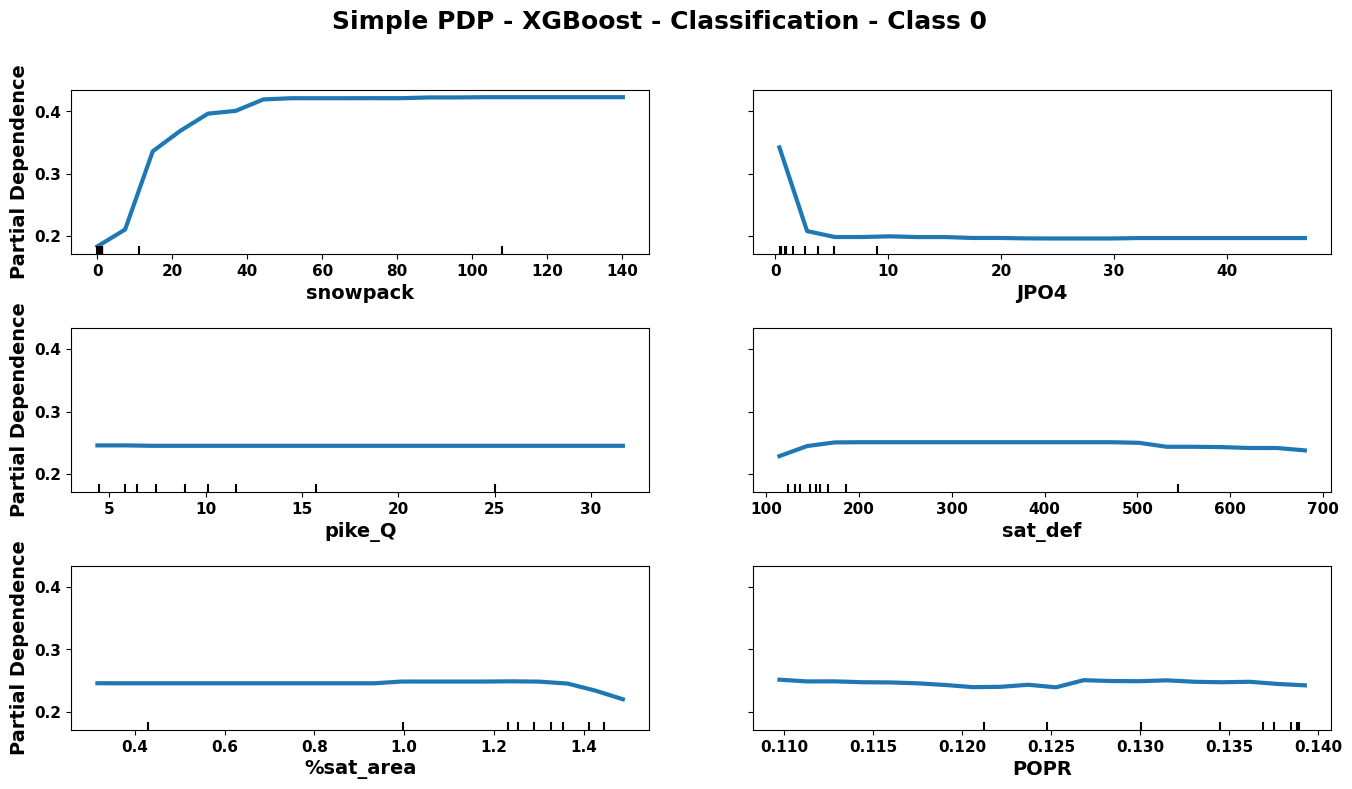

Simple PDP time: 0.61 seconds


[20:50:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "verbose" } are not used.



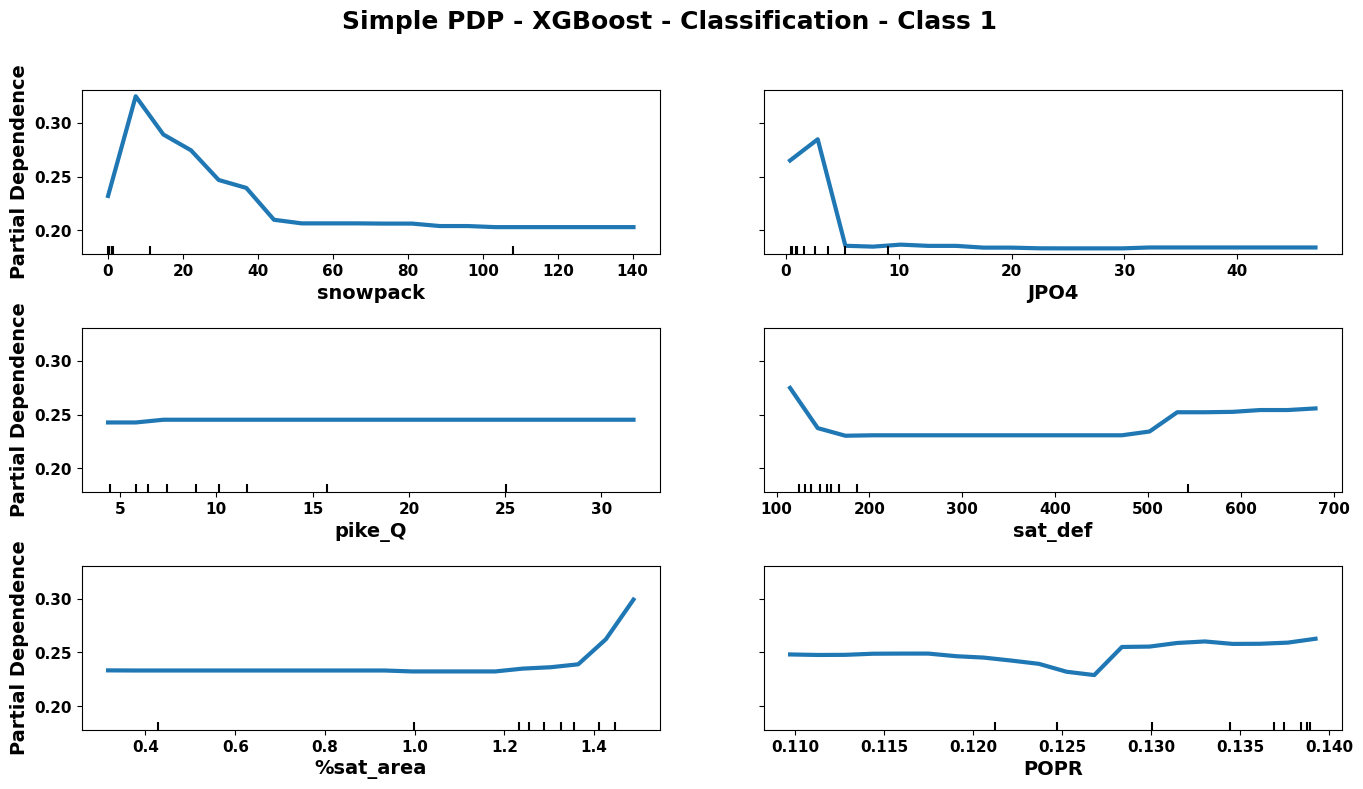

Simple PDP time: 0.68 seconds


[20:50:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "verbose" } are not used.



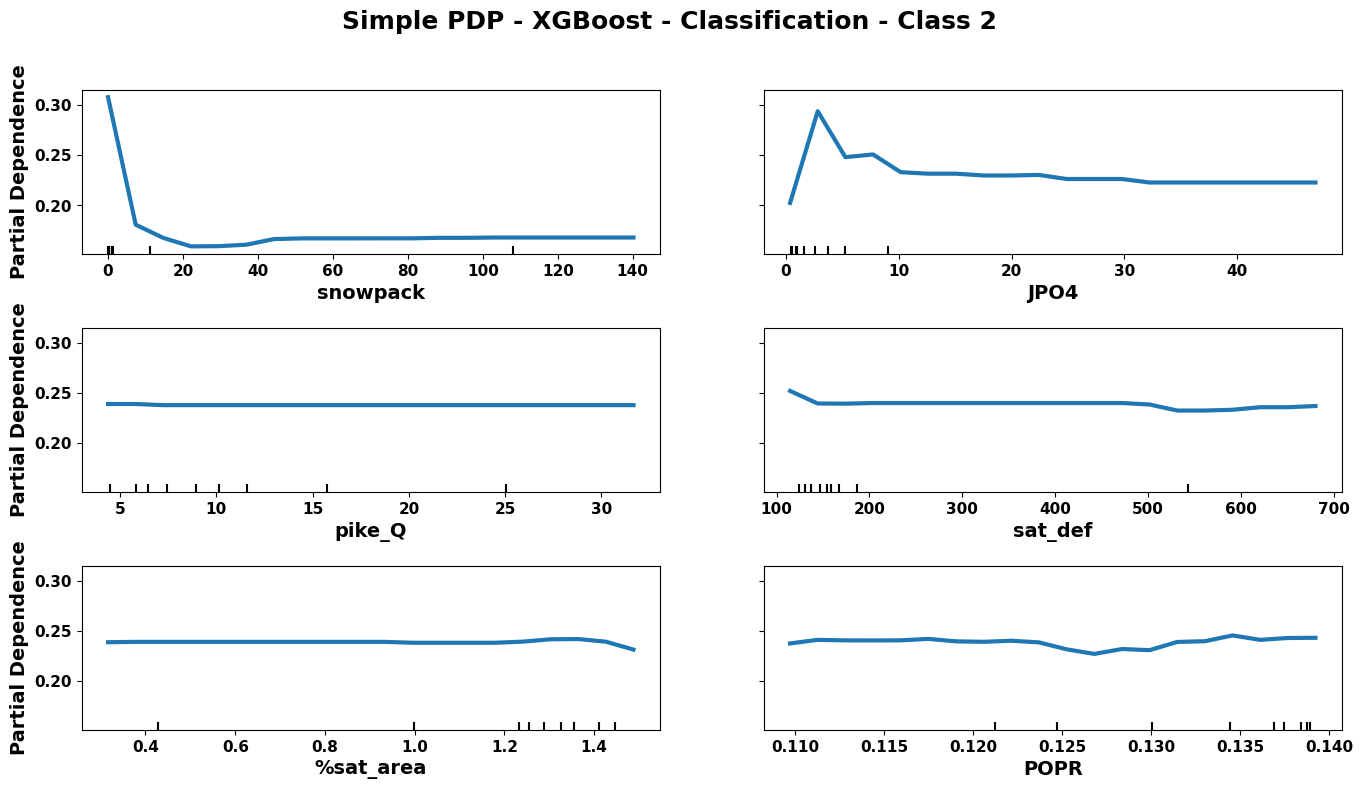

Simple PDP time: 0.62 seconds


[20:50:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "verbose" } are not used.



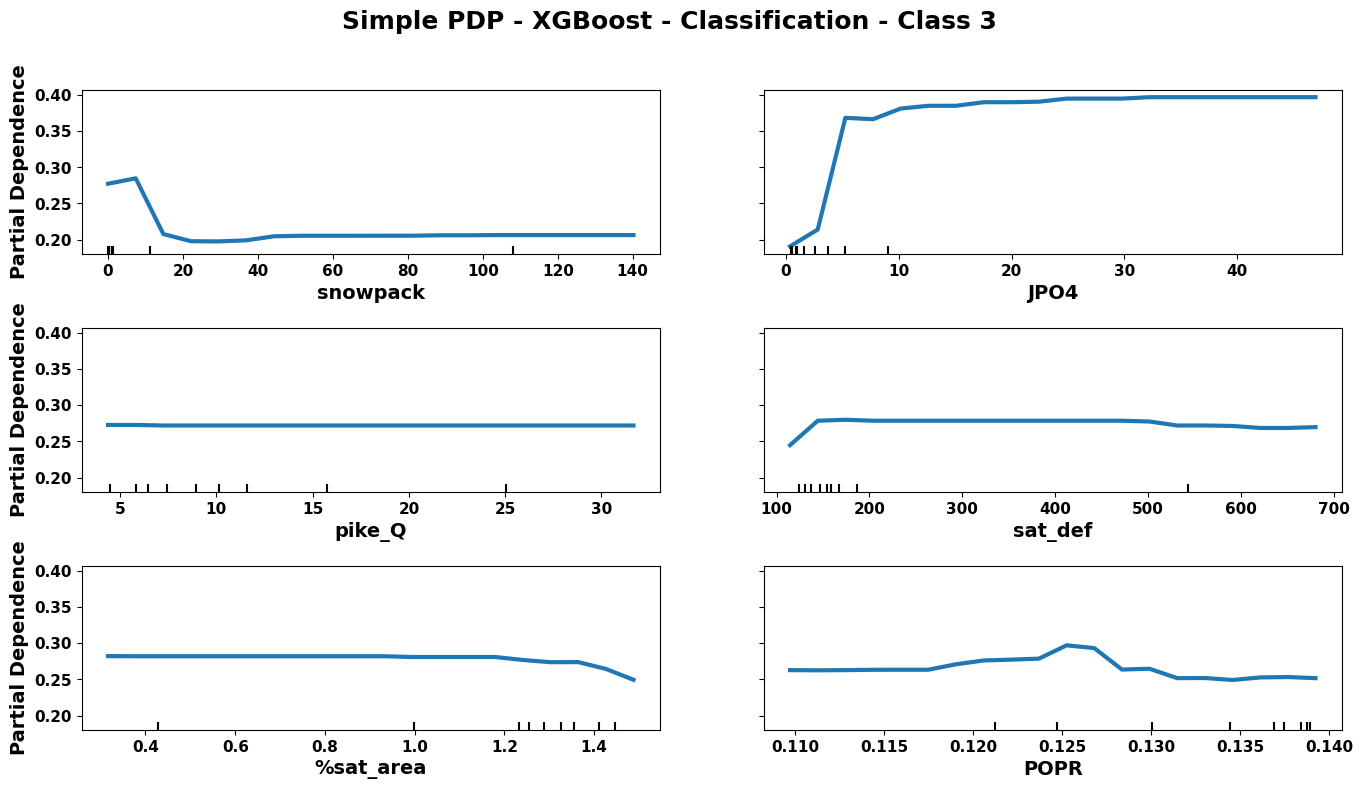

Simple PDP time: 0.70 seconds

Total XGBoost classification simple PDP time: 2.61 seconds


In [30]:

xgb_clf_top6 = get_top_features(xgb_clf_imp_df, score_col="mean", top_k=6)
print("XGBoost Classification Top 6:", xgb_clf_top6)

# simple PDPs
xgb_clf_simple_times = {}

xgb_clf_simple_start = time.time()

for class_id in range(4):
    xgb_clf_simple_times[class_id] = plot_simple_pdps(
        model=xgb_clf_loaded,
        X_train=X_class_train,
        features=xgb_clf_top6,
        title=f"Simple PDP - XGBoost - Classification - Class {class_id}",
        is_classification=True,
        class_id=class_id,
        subsample_n=50,
        grid_resolution=20,
        n_jobs=4
        )

xgb_clf_simple_total_time = time.time() - xgb_clf_simple_start
print(f"\nTotal XGBoost classification simple PDP time: {xgb_clf_simple_total_time:.2f} seconds")


/home/adil/miniconda3/envs/genv/lib/python3.10/site-packages/xgboost/core.py:2676: UserWarning: [20:50:04] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "verbose" } are not used.

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:


snowpack: bootstrap PDP finished in 0.52 seconds
JPO4: bootstrap PDP finished in 0.59 seconds
pike_Q: bootstrap PDP finished in 0.51 seconds
sat_def: bootstrap PDP finished in 0.51 seconds
%sat_area: bootstrap PDP finished in 0.51 seconds
POPR: bootstrap PDP finished in 0.57 seconds


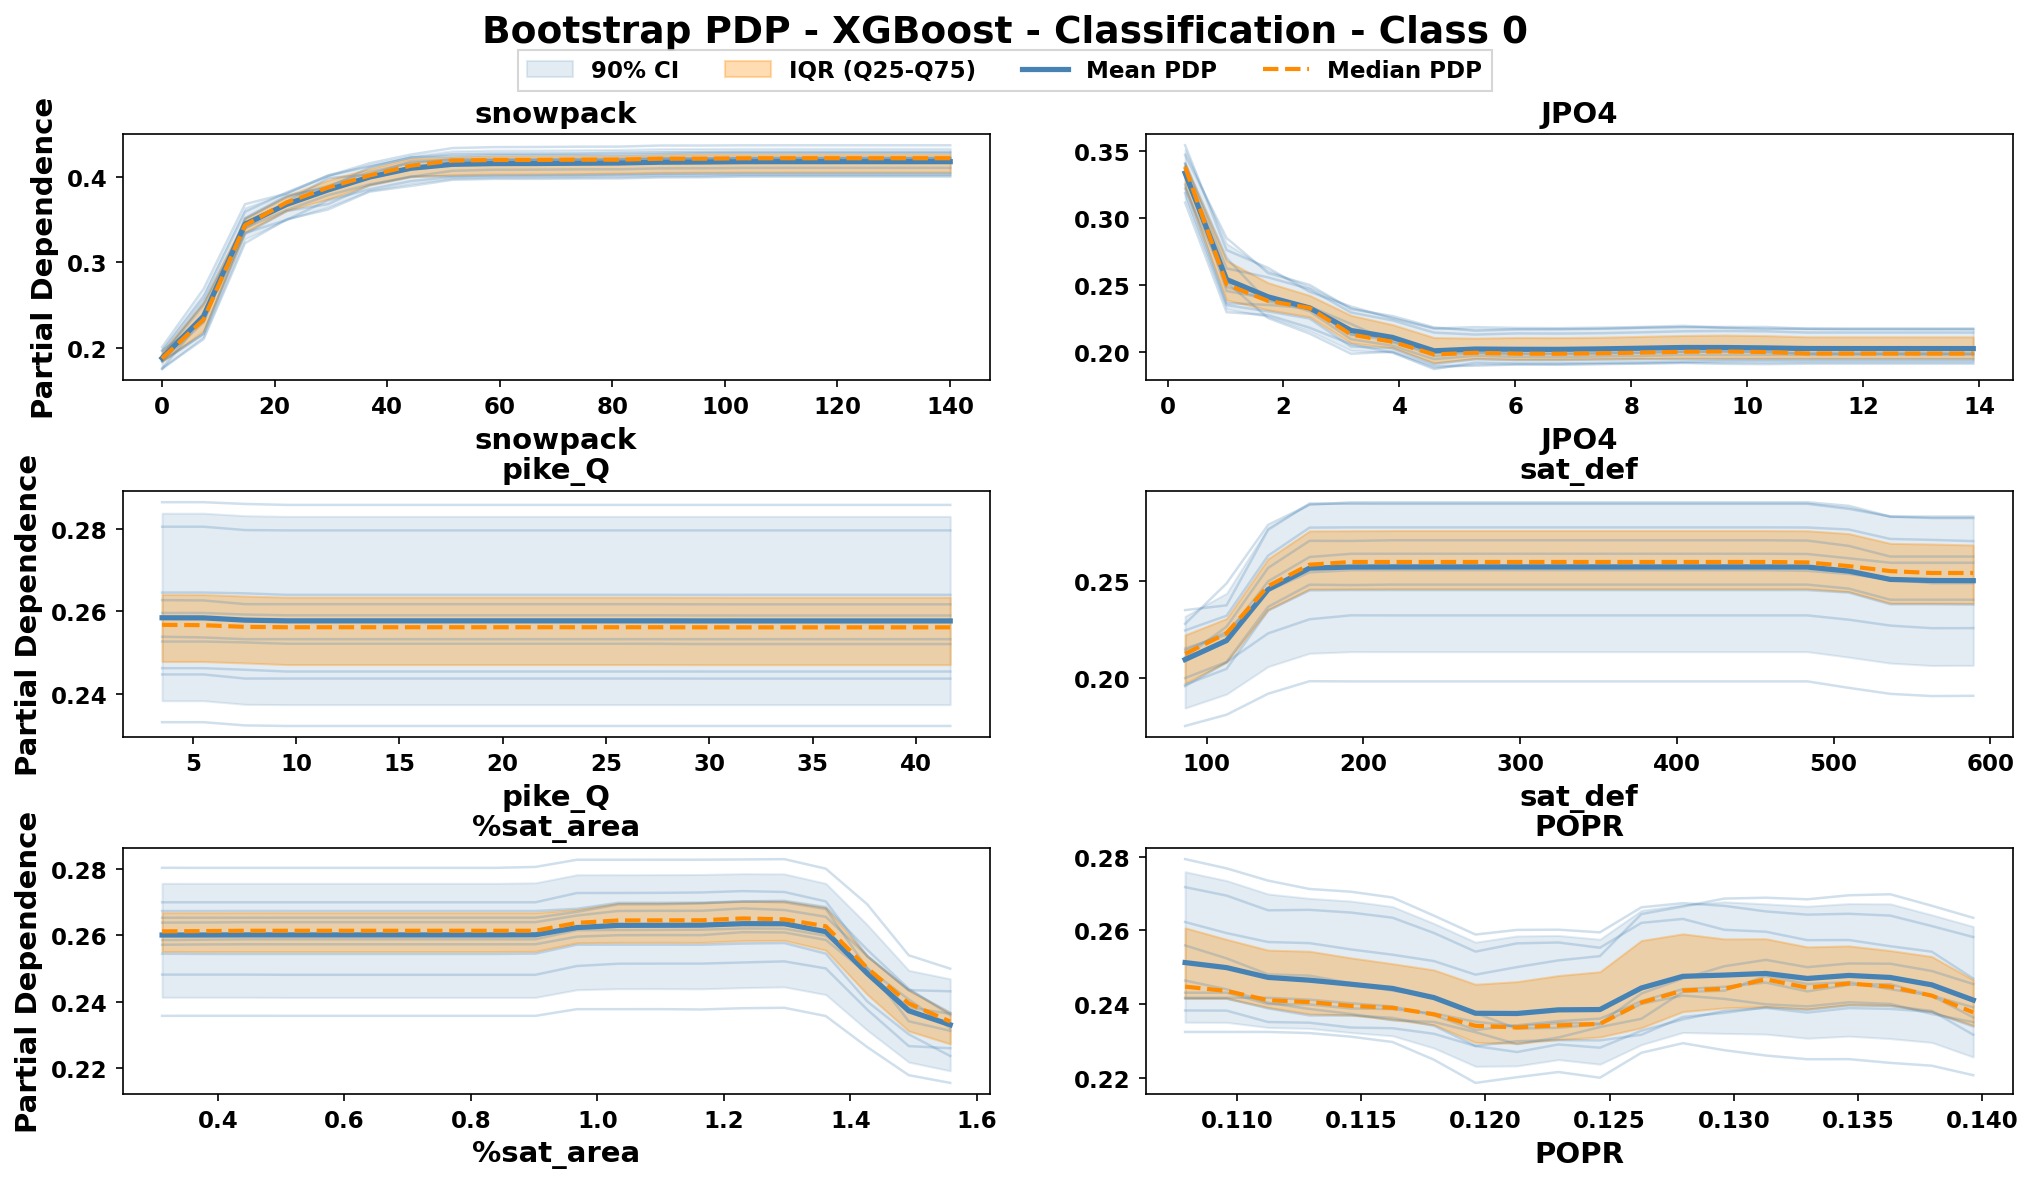

Bootstrap PDP total time: 3.69 seconds


/home/adil/miniconda3/envs/genv/lib/python3.10/site-packages/xgboost/core.py:2676: UserWarning: [20:50:07] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "verbose" } are not used.

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:


snowpack: bootstrap PDP finished in 0.52 seconds
JPO4: bootstrap PDP finished in 0.52 seconds
pike_Q: bootstrap PDP finished in 0.58 seconds
sat_def: bootstrap PDP finished in 0.51 seconds
%sat_area: bootstrap PDP finished in 0.51 seconds
POPR: bootstrap PDP finished in 0.51 seconds


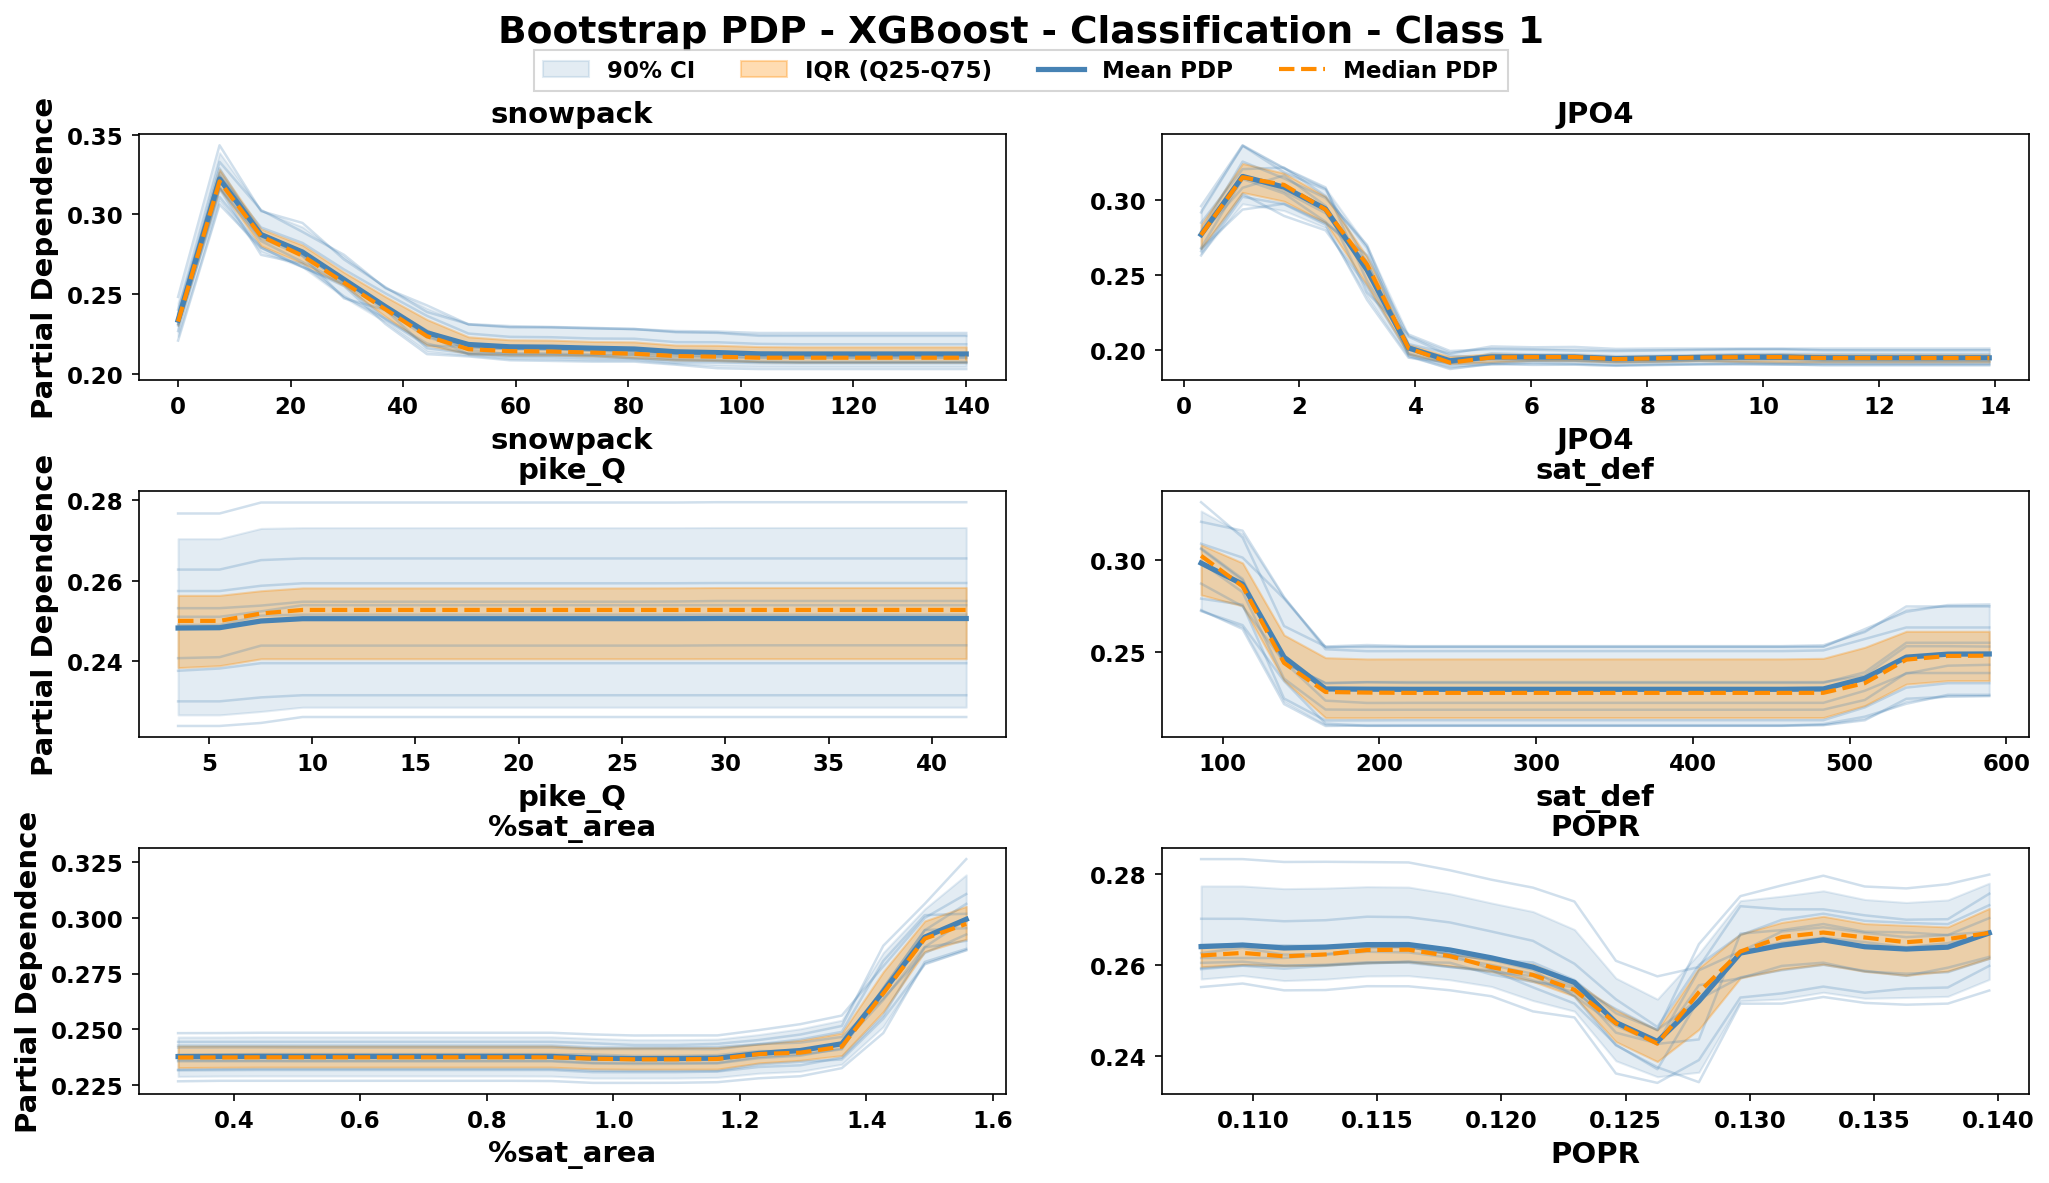

Bootstrap PDP total time: 3.59 seconds


/home/adil/miniconda3/envs/genv/lib/python3.10/site-packages/xgboost/core.py:2676: UserWarning: [20:50:11] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "verbose" } are not used.

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:


snowpack: bootstrap PDP finished in 0.58 seconds
JPO4: bootstrap PDP finished in 0.53 seconds
pike_Q: bootstrap PDP finished in 0.51 seconds
sat_def: bootstrap PDP finished in 0.57 seconds
%sat_area: bootstrap PDP finished in 0.51 seconds
POPR: bootstrap PDP finished in 0.50 seconds


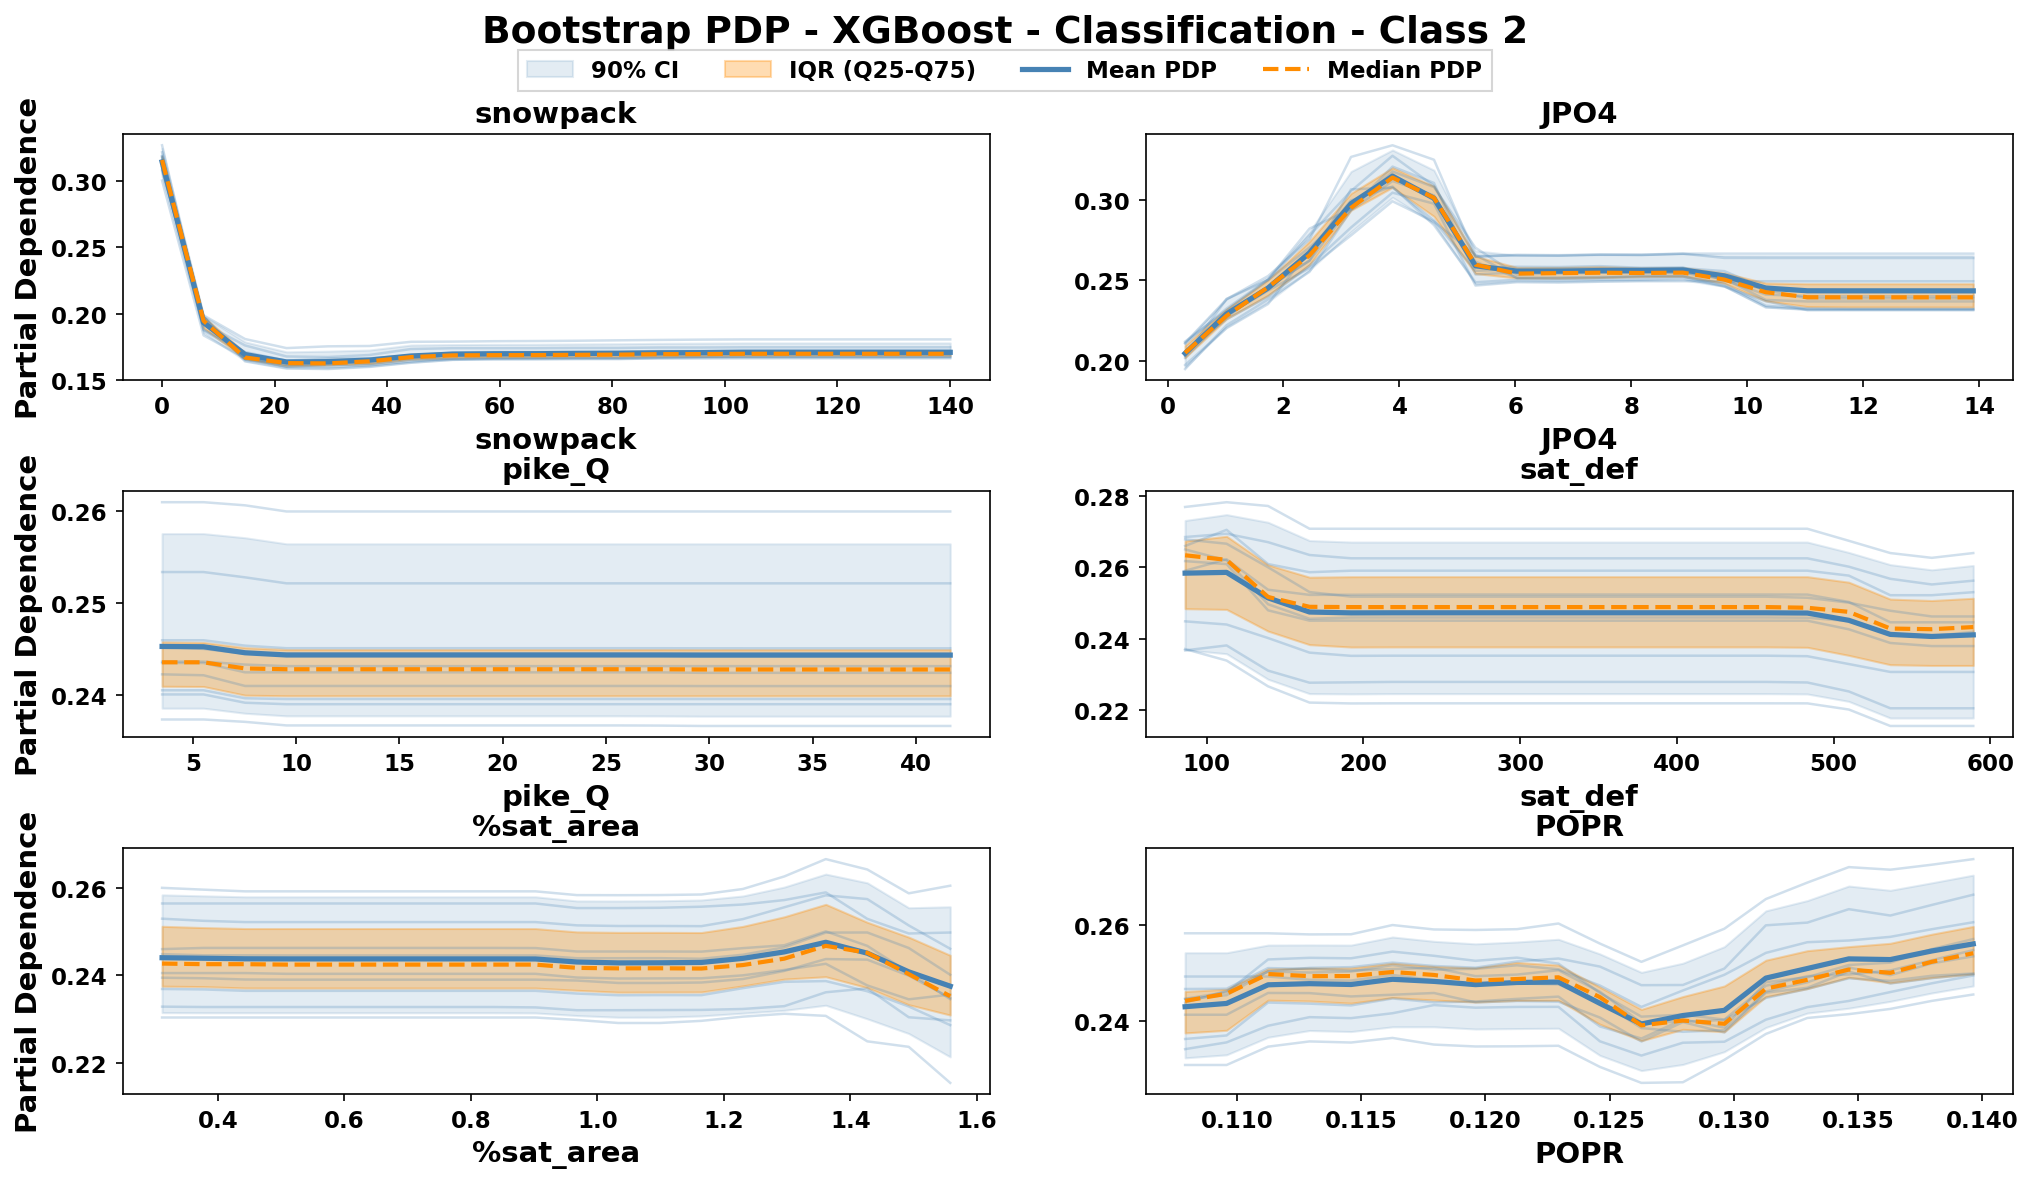

Bootstrap PDP total time: 3.65 seconds


/home/adil/miniconda3/envs/genv/lib/python3.10/site-packages/xgboost/core.py:2676: UserWarning: [20:50:15] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "verbose" } are not used.

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:


snowpack: bootstrap PDP finished in 0.50 seconds
JPO4: bootstrap PDP finished in 0.59 seconds
pike_Q: bootstrap PDP finished in 0.51 seconds
sat_def: bootstrap PDP finished in 0.51 seconds
%sat_area: bootstrap PDP finished in 0.57 seconds
POPR: bootstrap PDP finished in 0.51 seconds


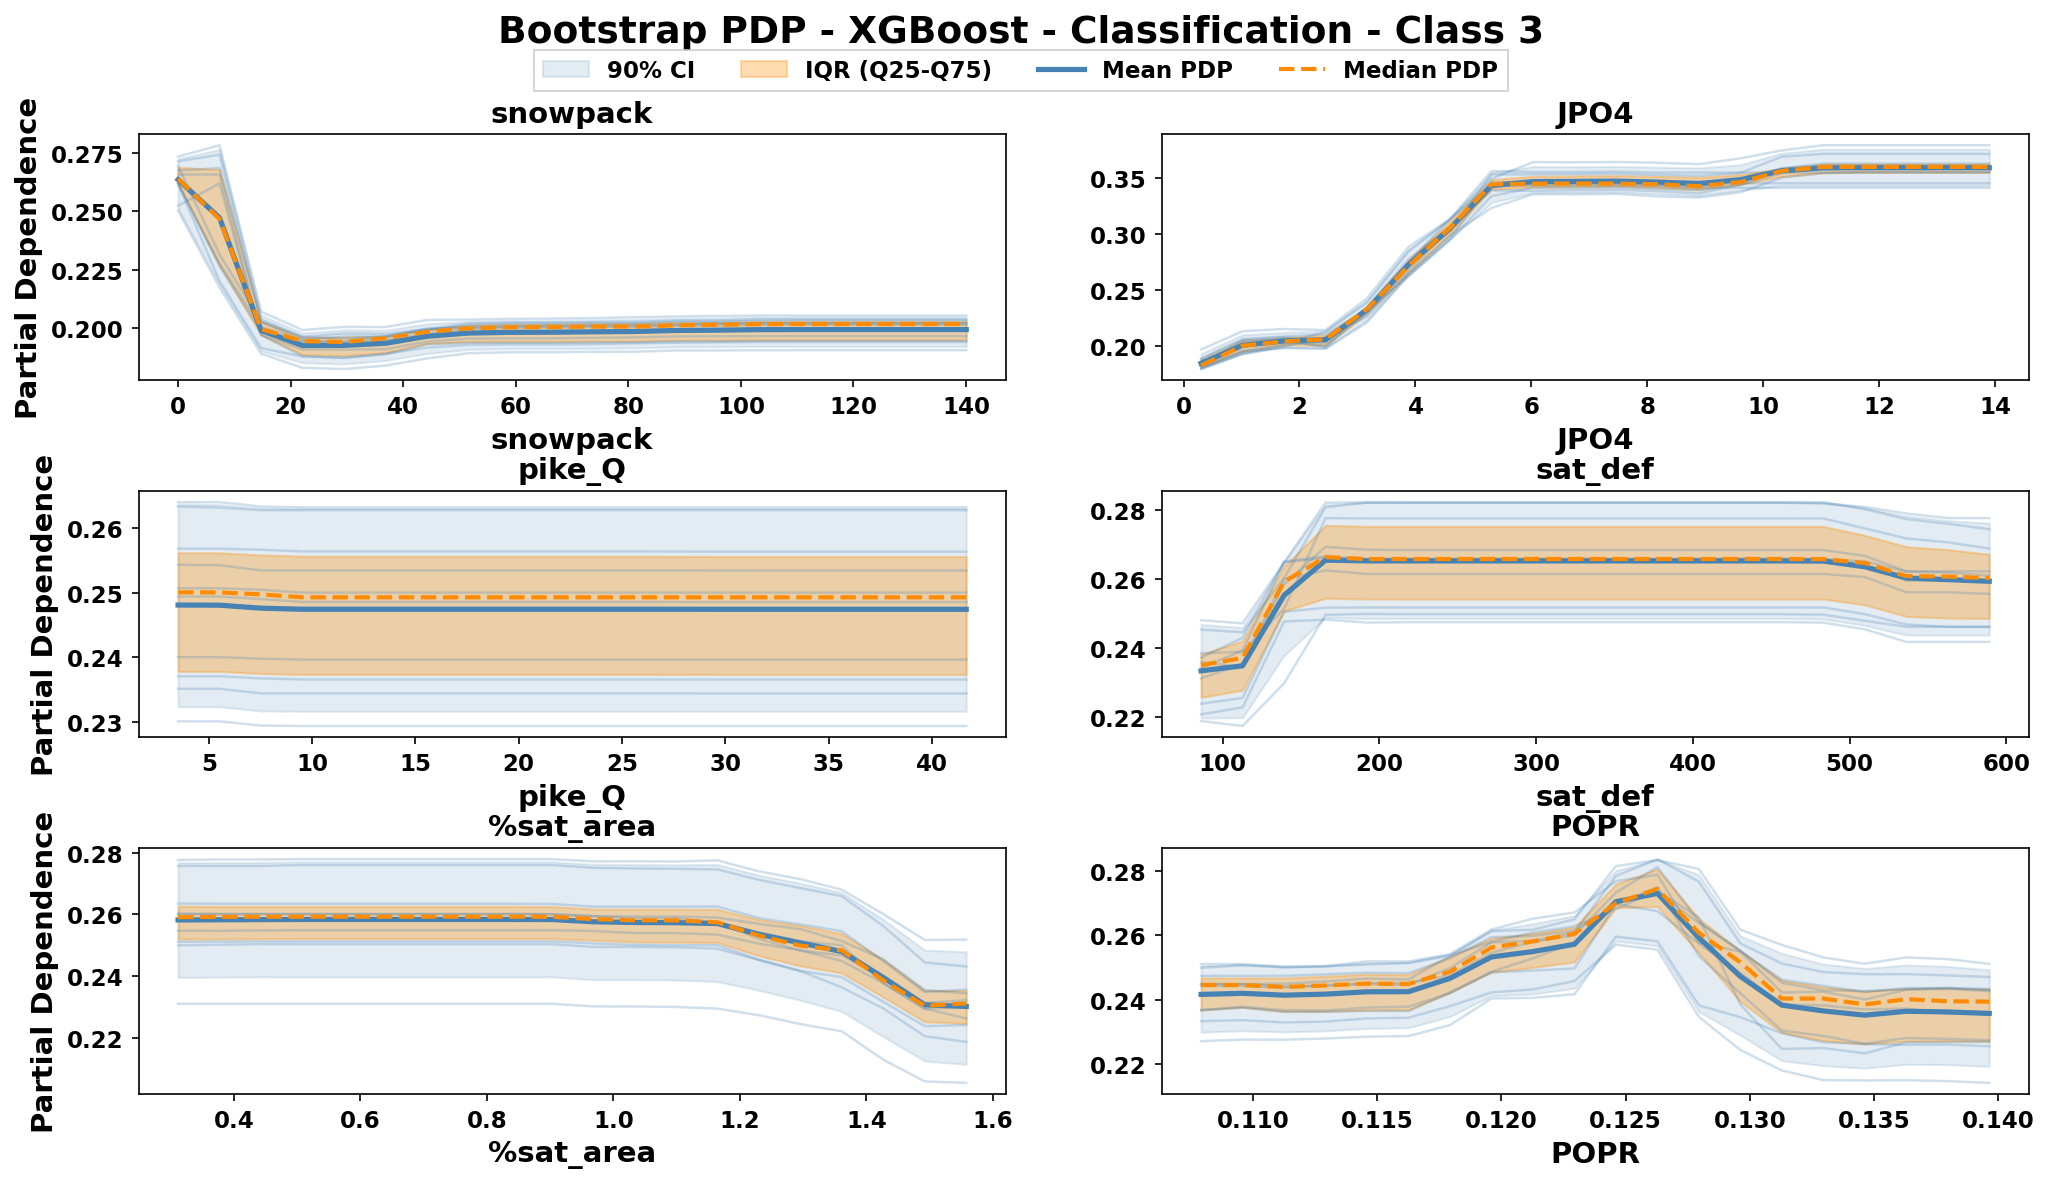

Bootstrap PDP total time: 3.66 seconds

Total XGBoost classification bootstrap PDP time: 14.60 seconds


In [31]:

# bootstrap PDPs
xgb_clf_bootstrap_times = {}

xgb_clf_bootstrap_start = time.time()

for class_id in range(4):
    xgb_clf_bootstrap_times[class_id] = plot_bootstrap_pdps(
        model=xgb_clf_loaded,
        X_train=X_class_train,
        features=xgb_clf_top6,
        title=f"Bootstrap PDP - XGBoost - Classification - Class {class_id}",
        is_classification=True,
        class_id=class_id,
        n_bootstrap=10,
        subsample_n=100,
        grid_resolution=20
        )

xgb_clf_bootstrap_total_time = time.time() - xgb_clf_bootstrap_start
print(f"\nTotal XGBoost classification bootstrap PDP time: {xgb_clf_bootstrap_total_time:.2f} seconds")


### **How to Interpret Simple/Bootstrap PDPs** 

`Reading PDP Plots:`
- **Mean PDP:** average partial-dependence curve across bootstrap resamples.
- **Median PDP:** middle PDP curve across bootstrap resamples, less sensitive to extreme bootstrap runs.
- **IQR (Q25-Q75):** middle 50% of bootstrap PDP curves, shows typical variability.
- **90% CI:** wider uncertainty band, shows how stable or unstable the PDP pattern is across resampled data.
Simple PDP vs Bootstrap PDP:
    - Simple PDP shows one fitted-model interpretation from one dataset sample.
    - Bootstrap PDP shows whether that pattern is stable under resampling.
    - If mean/median curves agree and bands are narrow, the relationship is more stable.

### **XGBoost Classification PDPs Interpretation**

- **JPO4 is the separating feature:**
    - Higher JPO4 reduces Class 1 probability, while increasing Class 2 and Class 3 probabilities.
- **Snowpack shows a class dependent pattern:**
    - Supports Class 0 and Class 1, but generally reduces Class 2 probability.
- **JPON behaves differently across classes:**
    - Increases Class 2 probability, and shows weaker and non linear effects for Classes 0 and 3.
- **sat_def contributes through threshold effects,** especially for Classes 1 to 3, where probability changes sharply after low to moderate values.
- **evap shows weaker but structured effects,** with positive association for higher classes and weaker influence for Class 0.
- **POPR is mostly non-linear and secondary,** with relatively small changes compared with JPO4, snowpack, and JPON.
- **Bootstrap PDPs confirm the major trends from the simple PDPs, especially for JPO4, snowpack, JPON, and sat_def.**

`These PDPs show emulator-learned predictive associations, not direct causal effects.`

#### **7.5 Regression PDPs**
##### **7.5.1 Random Forest Regression PDPs**

RF Regression Top 6: ['JPO4', 'POPR', 'sat_def', 'JPON', 'JPOP', 'PO4T2R']


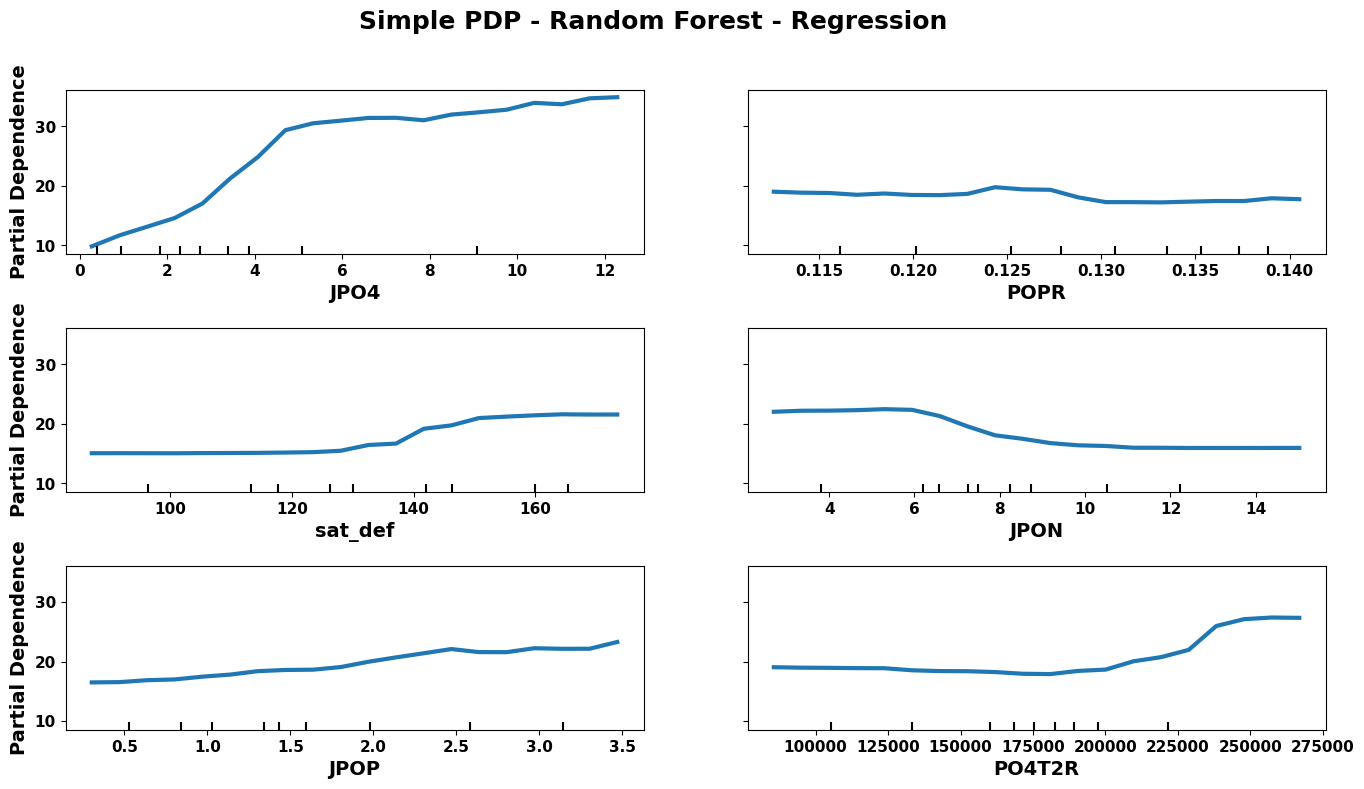

Simple PDP time: 0.41 seconds

Total RF regression simple PDP time: 0.41 seconds


In [32]:

rf_reg_top6 = get_top_features(rf_reg_imp_df, score_col="mean", top_k=6)
print("RF Regression Top 6:", rf_reg_top6)

rf_reg_loaded.set_params(verbose=0)

# simple PDP
rf_reg_simple_start = time.time()

rf_reg_simple_time = plot_simple_pdps(
    model=rf_reg_loaded,
    X_train=X_reg_train,
    features=rf_reg_top6,
    title="Simple PDP - Random Forest - Regression",
    is_classification=False,
    subsample_n=50,
    grid_resolution=20,
    n_jobs=4
    )

rf_reg_simple_total_time = time.time() - rf_reg_simple_start
print(f"\nTotal RF regression simple PDP time: {rf_reg_simple_total_time:.2f} seconds")


ERROR! Session/line number was not unique in database. History logging moved to new session 2
JPO4: bootstrap PDP finished in 0.10 seconds
POPR: bootstrap PDP finished in 0.16 seconds
sat_def: bootstrap PDP finished in 0.17 seconds
JPON: bootstrap PDP finished in 0.16 seconds
JPOP: bootstrap PDP finished in 0.17 seconds
PO4T2R: bootstrap PDP finished in 0.17 seconds


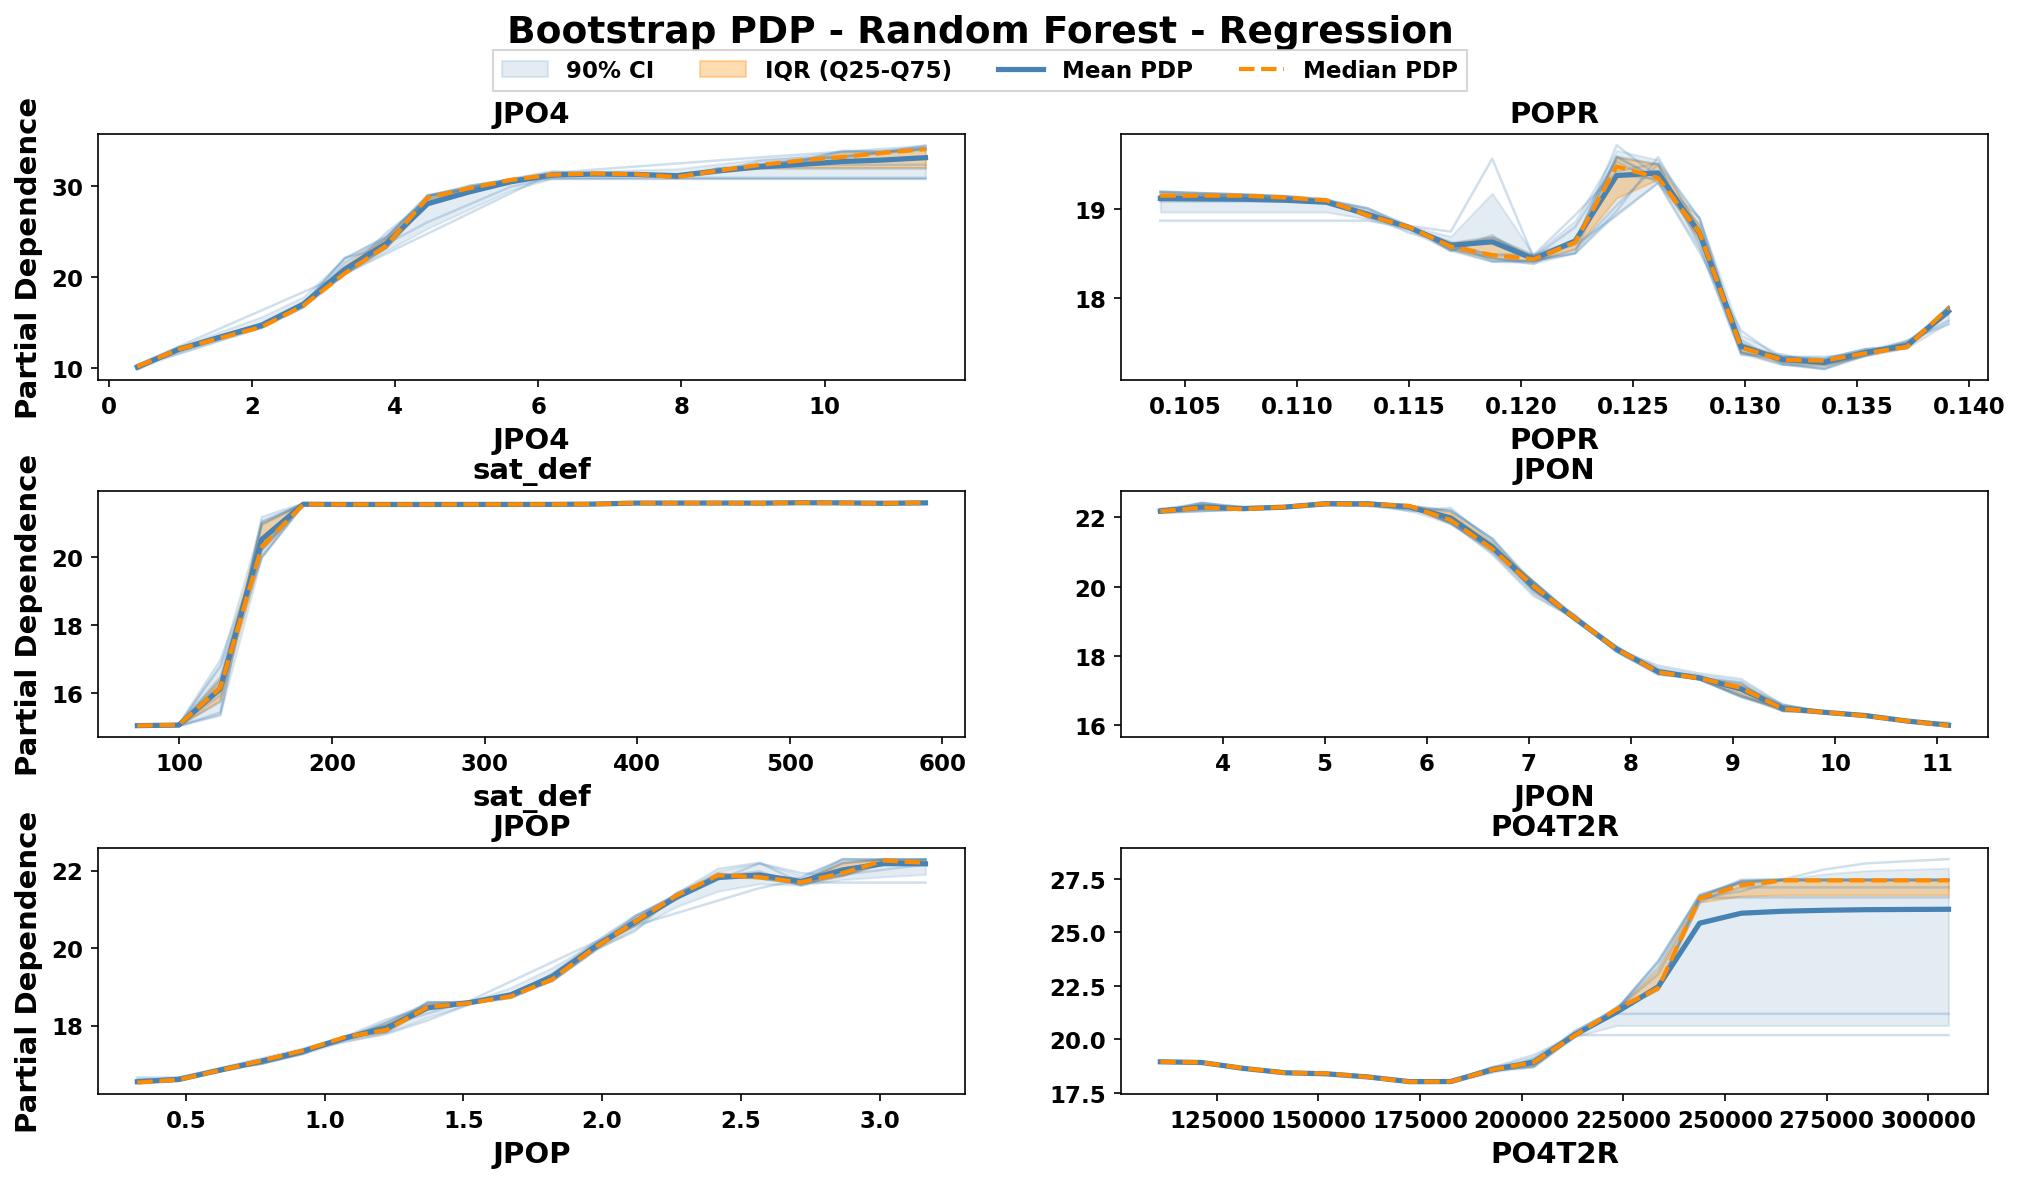

Bootstrap PDP total time: 1.37 seconds

Total RF regression bootstrap PDP time: 1.37 seconds


In [33]:

# bootstrap PDP
rf_reg_bootstrap_start = time.time()

rf_reg_bootstrap_time = plot_bootstrap_pdps(
    model=rf_reg_loaded,
    X_train=X_reg_train,
    features=rf_reg_top6,
    title="Bootstrap PDP - Random Forest - Regression",
    is_classification=False,
    n_bootstrap=10,
    subsample_n=50,
    grid_resolution=20
    )

rf_reg_bootstrap_total_time = time.time() - rf_reg_bootstrap_start
print(f"\nTotal RF regression bootstrap PDP time: {rf_reg_bootstrap_total_time:.2f} seconds")

### **Random Forest Regression PDPs Interpretation**

- **JPO4 shows the positive effect:** higher JPO4 is associated with a clear increase in the predicted continuous response.
- **sat_def shows a positive threshold like effect:** predictions rise sharply after a certain range and then plateau.
- **JPOP has a steady positive relationship**, suggesting that higher particulate phosphorus is associated with higher predicted response values.
- **JPON shows a negative relationship:** higher JPON is associated with lower predicted response values.
- **PO4T2R shows a non linear response:** predictions remain relatively stable at lower values, then increase sharply at higher values.
- **POPR has a weaker and kind of irregular pattern,** so its interpretation should be more cautious.
- **Bootstrap PDPs largely confirm the main simple-PDP trends,** especially for JPO4, sat_def, JPOP, and JPON.
- Narrow bands indicate stable effects for several variables, while wider bands around some ranges, especially PO4T2R and POPR, suggest uncertainty.
- `These patterns reflect predictive relationships learned by the Random Forest emulator, not direct causal effects.`



In [34]:

pdp_time_summary = pd.DataFrame([
    ["RF", "Regression", rf_reg_simple_total_time, rf_reg_bootstrap_total_time],
    ["XGBoost", "Classification", xgb_clf_simple_total_time, xgb_clf_bootstrap_total_time],
], columns=["Model", "Task", "Simple PDP Time (sec)", "Bootstrap PDP Time (sec)"])

pdp_time_summary


,Model,Task,Simple PDP Time (sec),Bootstrap PDP Time (sec)
0,RF,Regression,0.406765,1.373600
1,XGBoost,Classification,2.609032,14.596528


### **8. Transferability of the Workflow**

The workflow used in this notebook is **not limited to chlorophyll-a or waterquality modeling**.
The same emulator-analysis pipeline can be **reused for many simulation based environmental problems**, such as:

- Flood simulator emulation,
- Drought-risk surrogate modeling,
- Crop yield scenario exploration,
- Lake and reservoir water-quality analysis,
- Climate impact scenario screening,
- Policy and management intervention analysis.

**The reusable workflow is:**
- Start with simulator-generated input-output data,
- Train a fast emulator,
- Validate emulator fidelity,
- Inspect feature importance,
- Analyze PDPs for response behavior,
- Use bootstrap summaries to check interpretation stability,
- Interpret results carefully within the limits of the simulator.

`The main idea is that emulators can make expensive simulation workflows more interactive, interpretable, and scalable.`

### **9. Key Takeaways**
#### **9.1 Key Takeaways**
- Emulators can approximate simulator behavior at much lower computational cost.
- Regression and classification provide complementary views of the system:
  - regression captures continuous response magnitude,
  - classification captures ecological regime behavior.
- Feature importance identifies variables that are predictive inside the trained emulator.
- PDPs show how model predictions change as one feature varies.
- Bootstrap PDPs help distinguish stable response patterns from uncertain ones.
- Emulator interpretation can support teleconnection discovery by highlighting distant or indirect drivers associated with local water-quality outcomes.
- Strong predictive importance does **not** automatically imply real-world causality.
#### **9.2 Final Cautions**
- The emulator is trained on simulated outputs.
- It inherits assumptions, simplifications, and biases from the original simulator.
- Feature importance can be affected by correlated predictors.
- PDPs rely on partial-independence assumptions and may evaluate unrealistic feature combinations.
- Bootstrap PDPs improve stability assessment, but they do not create causal certainty.
